# NO CORRER EL CODIGO, SOLO ANALISIS

# Análisis Exploratorio de Egresos Hospitalarios en Chile (2019–2024)

**Fuente de datos:** Grupos Relacionados por el Diagnóstico (GRD) del sector público, publicados por FONASA.  
**Período:** 2019 – 2024 (~5.8 millones de egresos).  
**Objetivo:** Describir el perfil demográfico, clínico y operativo de las hospitalizaciones públicas en Chile, identificar patrones temporales (incluido el impacto de COVID-19) y evaluar la variabilidad hospitalaria en la práctica clínica.

---
**Notas técnicas del dataset:**
- Los archivos 2019–2021 están en UTF-8; 2022–2023 en UTF-16; 2024 en Latin-1.
- En 2024, la variable `CIP_ENCRIPTADO` se llama `ID_BENEFICIARIO`.
- La variable `EDAD` no existe directamente; se calcula como `FECHA_INGRESO − FECHA_NACIMIENTO`.
- El separador de campos es `|` (pipe).


## Pregunta de Investigación e Hipótesis

**Pregunta de investigación:**  
¿En qué medida el hospital donde se atiende un paciente determina sus días de estada y la intensidad de procedimientos, incluso cuando los pacientes presentan diagnóstico y severidad clínica comparables?

**Hipótesis:**  
Existe heterogeneidad estadísticamente significativa en resultados asistenciales (días de estada y cantidad de procedimientos) entre hospitales del sistema público chileno, incluso manteniendo constante la severidad y el diagnóstico del paciente mediante el código GRD.

### Variables del modelo analítico

| Rol | Variable | Columna en datos |
|-----|----------|------------------|
| **Independiente** | Hospital | `COD_HOSPITAL` |
| **Dependiente** | Días de estada | `dias_estada` (derivada) |
| **Dependiente** | Cantidad de procedimientos | `n_procedimientos` (derivada) |
| **Control** | Diagnóstico principal (CIE-10) | `DIAGNOSTICO1` |
| **Control** | Código GRD | `IR_29301_COD_GRD` |
| **Control** | Peso relativo GRD | `peso_grd` |
| **Control** | Severidad clínica | `severidad` |
| **Control** | Sexo | `SEXO` |
| **Control** | Edad | `edad` (derivada) |

### Estrategia de análisis
1. Cargar y consolidar los CSV 2019–2024 (6 archivos, ~5.8 M registros).
2. Limpiar datos: fechas, edad, días de estada, outliers (p99).
3. Enriquecer con CIE-10 para obtener descripciones legibles.
4. Análisis exploratorio: demografía, diagnósticos, estancia, complejidad, estacionalidad.
5. Análisis de variabilidad hospitalaria: GRD focal, intervalos de confianza, Kruskal-Wallis, post-hoc Dunn, y consistencia multi-GRD.

## 0. Configuración y Librerías

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 60)

# Estilo global
sns.set_theme(style="whitegrid", context="talk", palette="colorblind")
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (14, 6),
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "font.family": "sans-serif",
})

COLORES = sns.color_palette("colorblind", 10)
print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


In [2]:
# Path to the data folder provided by the user
BASE_PATH = "DATASET-PROBLEMA8/"
CODIGOS_PATH = "codigos_C00_D49.txt"

# Cargar códigos CIE permitidos para filtrar DIAGNOSTICO1
try:
    codigos_validos = {
        line.strip().upper()
        for line in Path(CODIGOS_PATH).read_text(encoding="utf-8").splitlines()
        if line.strip()
    }
    print(f"Códigos válidos cargados desde {CODIGOS_PATH}: {len(codigos_validos):,}")
except Exception as e:
    codigos_validos = set()
    print(f"ERROR al cargar {CODIGOS_PATH}: {e}")

# Columnas que necesitamos para el análisis
COLS_NEEDED = [
    "COD_HOSPITAL", "SEXO", "FECHA_NACIMIENTO", "CIP_ENCRIPTADO", "ID_BENEFICIARIO",
    "PROVINCIA", "COMUNA",
    "SERVICIO_SALUD", "TIPO_INGRESO", "ESPECIALIDAD_MEDICA",
    "TIPO_ACTIVIDAD", "FECHA_INGRESO", "FECHAALTA", "TIPOALTA",
    "DIAGNOSTICO1", "IR_29301_COD_GRD", "IR_29301_PESO",
    "IR_29301_SEVERIDAD", "IR_29301_MORTALIDAD",
] + [f"PROCEDIMIENTO{i}" for i in range(1, 4)]

# Eliminar duplicados manteniendo orden
COLS_NEEDED = list(dict.fromkeys(COLS_NEEDED))

def load_grd_csv(path, year_label):
    """Carga un CSV GRD detectando encoding y filtra por DIAGNOSTICO1 permitido."""
    src = Path(path)
    if not src.exists():
        print(f"  ERROR: Archivo no encontrado: {src.name}")
        return None

    raw = src.read_bytes()

    for enc in ["utf-8-sig", "utf-8", "utf-16", "utf-16-le", "latin-1", "cp1252"]:
        try:
            text = raw.decode(enc)
            break
        except (UnicodeDecodeError, UnicodeError):
            continue
    else:
        text = raw.decode("utf-8", errors="replace")
        enc = "utf-8(replace)"

    from io import StringIO
    df = pd.read_csv(
        StringIO(text), sep="|", engine="python",
        on_bad_lines="skip", dtype=str,
    )
    df.columns = df.columns.str.strip()

    if "ID_BENEFICIARIO" in df.columns and "CIP_ENCRIPTADO" not in df.columns:
        df.rename(columns={"ID_BENEFICIARIO": "CIP_ENCRIPTADO"}, inplace=True)

    filas_originales = len(df)
    if codigos_validos:
        if "DIAGNOSTICO1" not in df.columns:
            print(f"  {src.name:45s} enc={enc:12s}  ERROR: falta columna DIAGNOSTICO1")
            return None

        df["DIAGNOSTICO1"] = (
            df["DIAGNOSTICO1"]
            .astype(str)
            .str.strip()
            .str.upper()
        )
        df = df[df["DIAGNOSTICO1"].isin(codigos_validos)].copy()

    cols_available = [c for c in COLS_NEEDED if c in df.columns]
    df = df[cols_available].copy()
    df["anio_archivo"] = year_label

    filas_filtradas = len(df)
    pct = (filas_filtradas / filas_originales * 100) if filas_originales else 0
    print(
        f"  {src.name:45s} enc={enc:12s}  "
        f"filas={filas_filtradas:>10,}/{filas_originales:>10,} ({pct:5.1f}%)  cols={len(cols_available)}"
    )
    return df

FILES = [
    (f"{BASE_PATH}/GRD_PUBLICO_2019.csv", 2019),
    (f"{BASE_PATH}/GRD_PUBLICO_2020.csv", 2020),
    (f"{BASE_PATH}/GRD_PUBLICO_2021.csv", 2021),
    (f"{BASE_PATH}/GRD_PUBLICO_EXTERNO_2022.csv", 2022),
    (f"{BASE_PATH}/GRD_PUBLICO_2023.csv", 2023),
    (f"{BASE_PATH}/GRD_PUBLICO_2024.csv", 2024),
]

print("Cargando archivos GRD...\n")
dfs = []
for path, year in FILES:
    res = load_grd_csv(path, year)
    if res is not None:
        dfs.append(res)

if dfs:
    df = pd.concat(dfs, axis=0, ignore_index=True)
    del dfs
    print(f"\nTotal de registros cargados (filtrados por DIAGNOSTICO1): {len(df):,}")
    print(f"Columnas: {len(df.columns)}")
else:
    print("\nNo se cargó ningún archivo. Verifique la ruta de los datos y el archivo de códigos.")

Códigos válidos cargados desde codigos_C00_D49.txt: 894
Cargando archivos GRD...

  GRD_PUBLICO_2019.csv                          enc=utf-8-sig     filas=    81,871/ 1,151,475 (  7.1%)  cols=21
  GRD_PUBLICO_2020.csv                          enc=utf-8-sig     filas=    56,828/   781,912 (  7.3%)  cols=21
  GRD_PUBLICO_2021.csv                          enc=utf-8-sig     filas=    61,920/   816,909 (  7.6%)  cols=21
  GRD_PUBLICO_EXTERNO_2022.csv                  enc=utf-16        filas=    73,341/   932,839 (  7.9%)  cols=21
  GRD_PUBLICO_2023.csv                          enc=utf-16        filas=    83,569/ 1,039,587 (  8.0%)  cols=21
  GRD_PUBLICO_2024.csv                          enc=latin-1       filas=    89,214/ 1,085,813 (  8.2%)  cols=21

Total de registros cargados (filtrados por DIAGNOSTICO1): 446,743
Columnas: 22


In [3]:
display(df.head())

,COD_HOSPITAL,SEXO,FECHA_NACIMIENTO,CIP_ENCRIPTADO,PROVINCIA,COMUNA,SERVICIO_SALUD,TIPO_INGRESO,ESPECIALIDAD_MEDICA,TIPO_ACTIVIDAD,FECHA_INGRESO,FECHAALTA,TIPOALTA,DIAGNOSTICO1,IR_29301_COD_GRD,IR_29301_PESO,IR_29301_SEVERIDAD,IR_29301_MORTALIDAD,PROCEDIMIENTO1,PROCEDIMIENTO2,PROCEDIMIENTO3,anio_archivo
0,118100,HOMBRE,1938-03-04,93557,CONCEPCION,LOTA,CONCEPCIÓN,URGENCIA,NEUROCIRUGÍA,HOSPITALIZACIÓN,2019-02-07,2019-03-20,DOMICILIO,D43.0,011101,"1,8731",1,1,01.13,00.39,89.04,2019
1,118100,MUJER,1933-01-12,857926,CONCEPCION,CHIGUAYANTE,CONCEPCIÓN,URGENCIA,MEDICINA INTENSIVA,HOSPITALIZACIÓN,2019-03-02,2019-03-21,FALLECIDO,C23,061203,"3,5647",3,3,51.22,45.73,43.7,2019
2,118100,MUJER,1962-07-09,203938,CONCEPCION,CONCEPCIÓN,CONCEPCIÓN,PROGRAMADA,HEMATOLOGÍA,HOSPITALIZACIÓN,2019-03-07,2019-03-19,DOMICILIO,C85.1,174111,"0,8561",1,1,41.31,90.03,38.93,2019
3,118100,MUJER,1954-01-04,87895,CONCEPCION,CONCEPCIÓN,CONCEPCIÓN,PROGRAMADA,CIRUGÍA CABEZA CUELLO Y PLÁSTICA MAXILO FACIAL,HOSPITALIZACIÓN DIURNA,2019-03-28,2019-03-28,DOMICILIO,C44.3,082510,"0,8622",0,0,86.4,89.04,NaN,2019
4,118100,MUJER,1966-09-21,103150,CONCEPCION,CONCEPCIÓN,CONCEPCIÓN,PROGRAMADA,OBSTETRICIA Y GINECOLOGÍA,HOSPITALIZACIÓN DIURNA,2019-03-28,2019-03-28,DOMICILIO,D25.0,133110,"0,1717",0,0,88.79,66.8,96.49,2019


## 2. Limpieza y Preparación de Datos

Se realizan las siguientes transformaciones:
1. **Parseo de fechas** y cálculo de **edad** y **días de estada**.
2. **Filtro de coherencia temporal**: se eliminan registros cuyo año de `FECHA_INGRESO` no coincide con el año del archivo (`anio_archivo`).
3. **Conteo de diagnósticos y procedimientos** por episodio.
4. **Conversión del peso GRD** (coma → punto decimal).
5. **Eliminación de valores atípicos extremos** (percentil 99 de días de estada).
6. **Enriquecimiento con CIE-10** (nombres legibles de diagnósticos).


In [4]:
n_inicial = len(df)

# --- Fechas ---

for col_fecha in ["FECHA_INGRESO", "FECHAALTA", "FECHA_NACIMIENTO"]:
    s = df[col_fecha].astype(str).str.strip()

    # 1) Parseo ISO estricto (2023)
    iso_mask = s.str.match(r"^\d{4}-\d{2}-\d{2}$", na=False)
    dt = pd.Series(pd.NaT, index=df.index, dtype="datetime64[ns]")
    dt.loc[iso_mask] = pd.to_datetime(s.loc[iso_mask], format="%Y-%m-%d", errors="coerce")

    # 2) Parseo del resto como day-first
    dt.loc[~iso_mask] = pd.to_datetime(s.loc[~iso_mask], dayfirst=True, errors="coerce")

    df[col_fecha] = dt

# --- Año y mes de ingreso ---
df["anio"] = df["FECHA_INGRESO"].dt.year
df["mes"] = df["FECHA_INGRESO"].dt.month

# --- Filtro de coherencia temporal (año en fecha vs año del archivo) ---
n_anio_incoherente = 0
if "anio_archivo" in df.columns:
    df["anio_archivo"] = pd.to_numeric(df["anio_archivo"], errors="coerce")
    mask_anio_incoherente = (
        df["anio"].notna()
        & df["anio_archivo"].notna()
        & (df["anio"] != df["anio_archivo"])
    )
    n_anio_incoherente = int(mask_anio_incoherente.sum())

    if n_anio_incoherente > 0:
        resumen_incoherencias = (
            df.loc[mask_anio_incoherente, ["anio_archivo", "anio"]]
            .value_counts()
            .rename("n")
            .reset_index()
            .sort_values("n", ascending=False)
        )
        print("Registros con incoherencia de año (archivo vs FECHA_INGRESO):")
        display(resumen_incoherencias.head(10))

    df = df.loc[~mask_anio_incoherente].copy()

n_post_filtro_anio = len(df)

# --- Edad (en años) ---
df["edad"] = (df["FECHA_INGRESO"] - df["FECHA_NACIMIENTO"]).dt.days / 365.25
df.loc[df["edad"] < 0, "edad"] = np.nan
df.loc[df["edad"] > 120, "edad"] = np.nan

# --- Días de estada ---
df["dias_estada"] = (df["FECHAALTA"] - df["FECHA_INGRESO"]).dt.days
df.loc[df["dias_estada"] < 0, "dias_estada"] = np.nan

# --- Conteo de procedimientos y diagnósticos ---
proc_cols = [c for c in df.columns if c.startswith("PROCEDIMIENTO")]
diag_cols = [c for c in df.columns if c.startswith("DIAGNOSTICO")]
df["n_procedimientos"] = df[proc_cols].notna().sum(axis=1)
df["n_diagnosticos"] = df[diag_cols].notna().sum(axis=1)

# --- Peso GRD (coma decimal → float) ---
df["peso_grd"] = (
    df["IR_29301_PESO"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .pipe(pd.to_numeric, errors="coerce")
)

# --- Severidad y mortalidad como numérico ---
df["severidad"] = pd.to_numeric(df["IR_29301_SEVERIDAD"], errors="coerce")
df["mortalidad"] = pd.to_numeric(df["IR_29301_MORTALIDAD"], errors="coerce")

# --- Eliminar outliers extremos de días de estada (p99) ---
p99 = df["dias_estada"].quantile(0.99)
df_clean = df[df["dias_estada"].notna() & (df["dias_estada"] <= p99)].copy()

# --- Liberar columnas intermedias de memoria ---
# Se conservan PROCEDIMIENTO1..3 para análisis oncológico de diversidad procedimental.
cols_drop = diag_cols[1:]  # Mantener DIAGNOSTICO1
df_clean.drop(columns=[c for c in cols_drop if c in df_clean.columns], inplace=True, errors="ignore")

n_final = len(df_clean)
print(f"Registros iniciales:                  {n_inicial:>10,}")
print(f"Eliminados por incoherencia de año:   {n_anio_incoherente:>10,}")
print(f"Tras filtro de coherencia anual:       {n_post_filtro_anio:>10,}")
print(f"Registros tras limpieza:               {n_final:>10,}")
pct_elim_total = ((n_inicial - n_final) / n_inicial * 100) if n_inicial else 0
print(f"Eliminados totales:                    {n_inicial - n_final:>10,} ({pct_elim_total:.1f}%)")
print(f"Corte outlier p99 (días estada): {p99:.0f} días")
print(f"\nRango de edad: {df_clean['edad'].min():.0f} – {df_clean['edad'].max():.0f} años")
print(f"Rango de días de estada: {df_clean['dias_estada'].min():.0f} – {df_clean['dias_estada'].max():.0f}")

Registros con incoherencia de año (archivo vs FECHA_INGRESO):


,anio_archivo,anio,n
0,2024,2023.0,1244
1,2020,2019.0,1158
2,2019,2018.0,1118
3,2023,2022.0,1103
4,2022,2021.0,1034
5,2021,2020.0,920
6,2022,2020.0,4
7,2019,2015.0,1
8,2020,2015.0,1
9,2021,2019.0,1


Registros iniciales:                     446,743
Eliminados por incoherencia de año:        6,585
Tras filtro de coherencia anual:          440,158
Registros tras limpieza:                  435,820
Eliminados totales:                        10,923 (2.4%)
Corte outlier p99 (días estada): 53 días

Rango de edad: 0 – 118 años
Rango de días de estada: 0 – 53


In [5]:
# Verificación de coherencia temporal después de la limpieza
mask_mismatch_post = (
    df_clean["anio"].notna()
    & df_clean["anio_archivo"].notna()
    & (df_clean["anio"] != df_clean["anio_archivo"])
)
n_mismatch_post = int(mask_mismatch_post.sum())

print(f"Registros con año incoherente tras limpieza: {n_mismatch_post:,}")
if n_mismatch_post > 0:
    display(
        df_clean.loc[mask_mismatch_post, ["anio_archivo", "anio"]]
        .value_counts()
        .rename("n")
        .reset_index()
        .sort_values("n", ascending=False)
    )
else:
    print("OK: no quedan registros fuera del año del archivo.")

Registros con año incoherente tras limpieza: 0
OK: no quedan registros fuera del año del archivo.


In [6]:
# Cargar CIE-10 para enriquecer los diagnósticos usando el BASE_PATH
cie10_path = f"{BASE_PATH}/CIE-10.xlsx"
try:
    cie10 = pd.read_excel(cie10_path, dtype=str)
    cie10_map = cie10.set_index("Código")["Descripción"].to_dict()
    cie10_capitulo = cie10.set_index("Código")["Capítulo"].to_dict()

    # Agregar descripción del diagnóstico principal
    df_clean["diag_principal"] = df_clean["DIAGNOSTICO1"].astype(str).str.strip()
    df_clean["diag_descripcion"] = df_clean["diag_principal"].map(cie10_map)
    df_clean["diag_capitulo"] = df_clean["diag_principal"].map(cie10_capitulo)

    cobertura = df_clean["diag_descripcion"].notna().mean() * 100
    print(f"Cobertura CIE-10 para diagnóstico principal: {cobertura:.1f}%")
    display(df_clean[["diag_principal", "diag_descripcion", "diag_capitulo"]].dropna().head(5))
except Exception as e:
    print(f"Error al cargar CIE-10 en {cie10_path}: {e}")

Cobertura CIE-10 para diagnóstico principal: 100.0%


,diag_principal,diag_descripcion,diag_capitulo
0,D43.0,Tumor de comportamiento incierto o desconocido...,Cap.02 NEOPLASIAS (C00-D49)
1,C23,Tumor maligno de la vesícula biliar,Cap.02 NEOPLASIAS (C00-D49)
2,C85.1,"Linfoma de células B, sin otra especificación",Cap.02 NEOPLASIAS (C00-D49)
3,C44.3,Tumor maligno de la piel de otras partes y de ...,Cap.02 NEOPLASIAS (C00-D49)
4,D25.0,Leiomioma submucoso del útero,Cap.02 NEOPLASIAS (C00-D49)


In [7]:
# Resumen del dataset limpio
print("=== RESUMEN DEL DATASET LIMPIO ===\n")
print(f"Filas: {len(df_clean):,}")
print(f"Período: {df_clean['anio'].min():.0f} – {df_clean['anio'].max():.0f}")
print(f"Hospitales únicos: {df_clean['COD_HOSPITAL'].nunique():,}")
print(f"Servicios de salud: {df_clean['SERVICIO_SALUD'].nunique()}")
print()
print("Variables numéricas clave:")
display(df_clean[["edad", "dias_estada", "n_procedimientos", "n_diagnosticos", "peso_grd", "severidad"]].describe().round(2))


=== RESUMEN DEL DATASET LIMPIO ===

Filas: 435,820
Período: 2019 – 2024
Hospitales únicos: 72
Servicios de salud: 32

Variables numéricas clave:


,edad,dias_estada,n_procedimientos,n_diagnosticos,peso_grd,severidad
count,435819.00,435820.00,435820.00,435820.0,435816.00,435816.00
mean,56.15,6.12,2.73,1.0,1.21,1.51
std,19.68,8.34,0.64,0.0,1.09,0.98
min,0.00,0.00,0.00,1.0,0.00,0.00
25%,44.61,1.00,3.00,1.0,0.70,1.00
50%,59.33,3.00,3.00,1.0,0.98,1.00
75%,70.75,7.00,3.00,1.0,1.32,2.00
max,118.05,53.00,3.00,1.0,14.25,3.00


## Glosario de Términos

| Término | Definición |
|---------|------------|
| **GRD** | Grupos Relacionados por el Diagnóstico. Sistema de clasificación que agrupa egresos hospitalarios en categorías clínicamente coherentes y de consumo de recursos similar. |
| **IR-GRD** | Versión chilena del sistema GRD utilizada por FONASA, adaptada a la realidad epidemiológica y de costos del sistema público nacional. |
| **CIE-10** | Clasificación Internacional de Enfermedades, 10ª revisión. Nomenclatura estándar para diagnósticos médicos. |
| **CIE-9** | Clasificación Internacional de Enfermedades, 9ª revisión. Utilizada para codificar procedimientos médicos e intervenciones quirúrgicas. |
| **Peso Relativo GRD** | Valor numérico que representa la complejidad relativa y el consumo esperado de recursos de un grupo diagnóstico específico. Un peso mayor indica mayor complejidad y costo. |
| **Severidad** | Nivel de gravedad clínica del caso (1–4), precalculado en el sistema IR-GRD. Un nivel más alto indica mayor complejidad clínica. |
| **Mortalidad** | Riesgo de mortalidad asociado al caso (1–4), precalculado en el sistema IR-GRD. |
| **Días de Estada** | Duración total de la hospitalización, calculada como la diferencia entre la fecha de alta (`FECHAALTA`) y la fecha de ingreso (`FECHA_INGRESO`). |
| **FONASA** | Fondo Nacional de Salud. Organismo público de financiamiento de salud en Chile. Tramos A y B corresponden a la población de menores ingresos. |
| **SERVICIO_SALUD** | Red territorial de prestadores de salud pública en Chile. El país se divide en 29 Servicios de Salud regionales. |
| **Egreso hospitalario** | Todo evento de salida de un paciente de una cama hospitalaria, ya sea por alta médica, traslado, fallecimiento u otra causa. |
| **CIP Encriptado / ID_BENEFICIARIO** | Identificador encriptado del paciente (anonimizado). En archivos 2019–2023 se llama `CIP_ENCRIPTADO`; en 2024 se llama `ID_BENEFICIARIO`. |
| **Variabilidad hospitalaria** | Diferencias en resultados asistenciales (días de estada, procedimientos) entre hospitales para pacientes con características clínicas comparables, no explicadas por la condición del paciente.

## 3. Panorama General de los Egresos Hospitalarios

### 3.1 Volumen de egresos hospitalarios por año

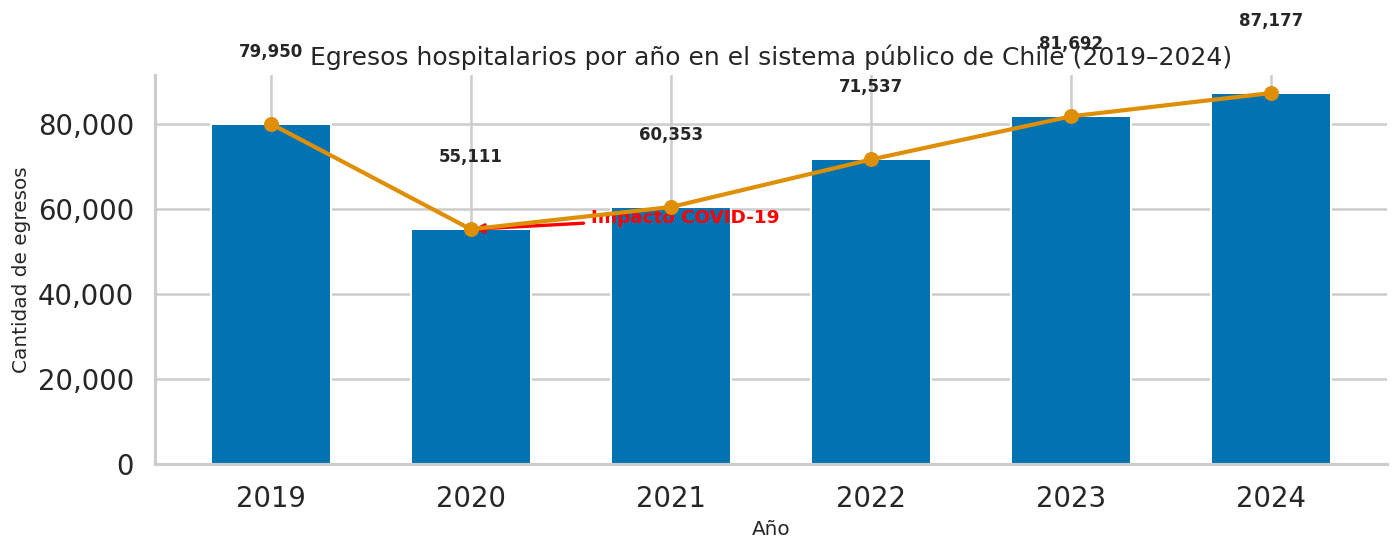

Caída 2020 vs 2019: -31.1%


In [8]:
vol = df_clean.groupby("anio").size().reset_index(name="egresos")

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(vol["anio"], vol["egresos"], color=COLORES[0], width=0.6, edgecolor="white", linewidth=1.2)
ax.plot(vol["anio"], vol["egresos"], "o-", color=COLORES[1], linewidth=2.5, markersize=8, zorder=5)

# Etiquetas sobre las barras
for bar, val in zip(bars, vol["egresos"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15000,
            f"{val:,.0f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

# Anotación COVID
ax.annotate("Impacto COVID-19", xy=(2020, vol[vol.anio==2020]["egresos"].values[0]),
            xytext=(2020.6, vol["egresos"].max() * 0.65),
            arrowprops=dict(arrowstyle="->", color="red", lw=2),
            fontsize=11, color="red", fontweight="bold")

ax.set_xlabel("Año")
ax.set_ylabel("Cantidad de egresos")
ax.set_title("Egresos hospitalarios por año en el sistema público de Chile (2019–2024)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xticks(vol["anio"])
sns.despine()
plt.tight_layout()
plt.show()

# Calcular caída COVID
pre_covid = vol[vol.anio == 2019]["egresos"].values[0]
covid_year = vol[vol.anio == 2020]["egresos"].values[0]
pct_drop = (covid_year - pre_covid) / pre_covid * 100
print(f"Caída 2020 vs 2019: {pct_drop:+.1f}%")


**Conclusión 3.1 — Impacto de COVID-19 y recuperación:**  
El año 2020 registró una caída significativa en los egresos hospitalarios respecto a 2019, directamente atribuible a la pandemia de COVID-19: se suspendieron cirugías programadas, se limitaron las consultas electivas y se reconvirtieron camas para pacientes críticos. A partir de 2021 se observa una recuperación gradual, con 2023 y 2024 superando los niveles pre-pandemia, lo que sugiere tanto una demanda acumulada (cirugías postergadas) como un crecimiento vegetativo de la actividad hospitalaria.


### 3.2 Distribución demográfica: Edad y Sexo

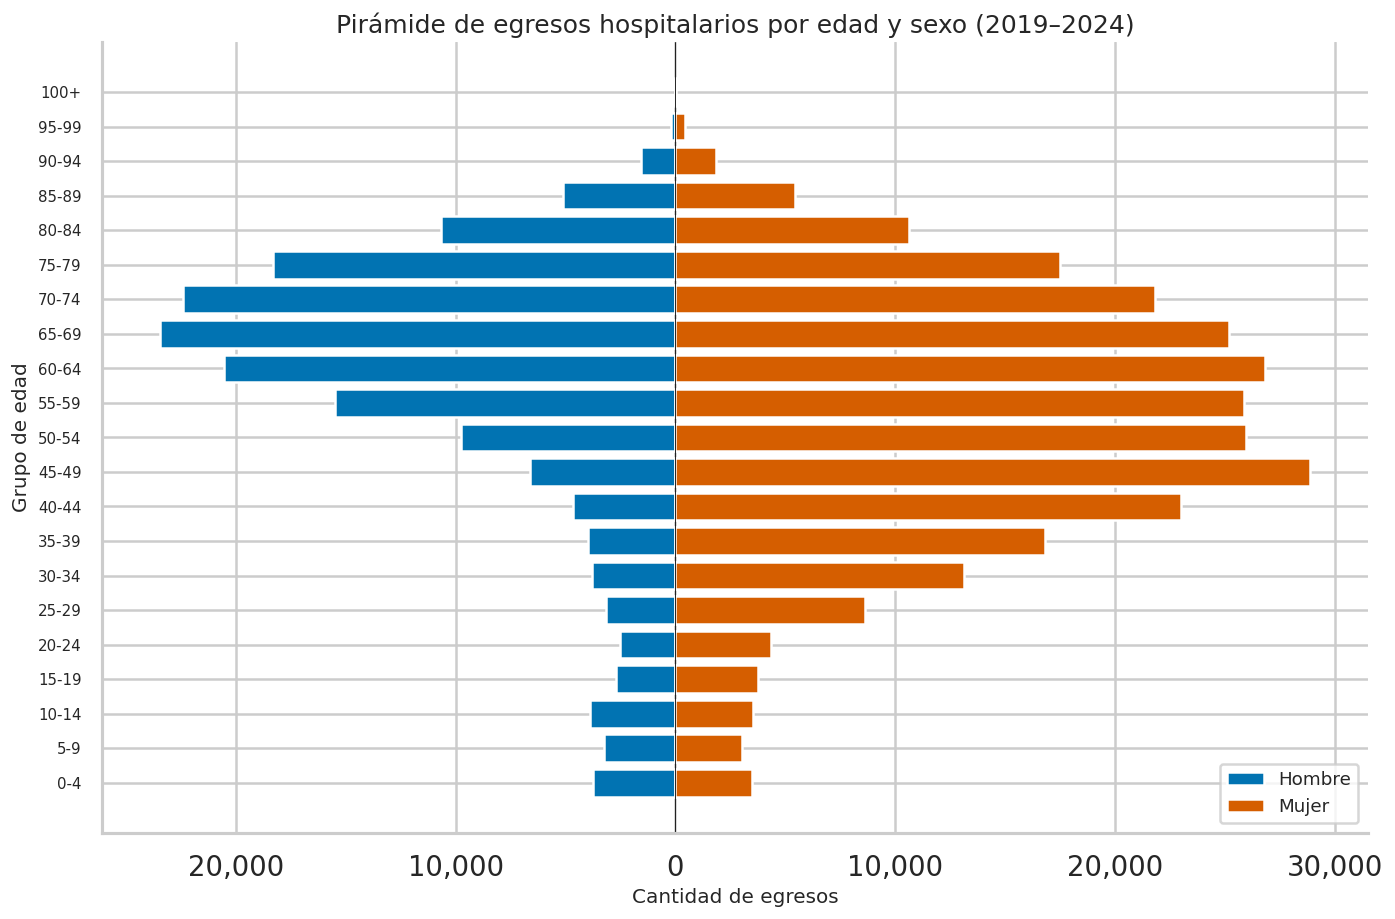

Distribución por sexo: {'MUJER': 269999, 'HOMBRE': 165774}
Edad promedio — Mujeres: 54.1 años, Hombres: 59.5 años


In [9]:
df_demo = df_clean.dropna(subset=["edad", "SEXO"]).copy()
df_demo = df_demo[df_demo["SEXO"].isin(["HOMBRE", "MUJER"])]
df_demo["grupo_edad"] = pd.cut(df_demo["edad"],
    bins=list(range(0, 101, 5)) + [120],
    labels=[f"{i}-{i+4}" for i in range(0, 100, 5)] + ["100+"],
    right=False
)

# Pirámide poblacional
pyr = df_demo.groupby(["grupo_edad", "SEXO"], observed=True).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 8))
y_pos = range(len(pyr))
labels = pyr.index.astype(str)

ax.barh(y_pos, -pyr["HOMBRE"], color=COLORES[0], label="Hombre", height=0.8, edgecolor="white")
ax.barh(y_pos, pyr["MUJER"], color=COLORES[3], label="Mujer", height=0.8, edgecolor="white")

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Cantidad de egresos")
ax.set_ylabel("Grupo de edad")
ax.set_title("Pirámide de egresos hospitalarios por edad y sexo (2019–2024)")
ax.legend(loc="lower right", fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{abs(x):,.0f}"))
ax.axvline(0, color="black", linewidth=0.5)
sns.despine()
plt.tight_layout()
plt.show()

print(f"Distribución por sexo: {df_demo['SEXO'].value_counts().to_dict()}")
print(f"Edad promedio — Mujeres: {df_demo[df_demo.SEXO=='MUJER']['edad'].mean():.1f} años, "
      f"Hombres: {df_demo[df_demo.SEXO=='HOMBRE']['edad'].mean():.1f} años")


**Conclusión 3.2 — Perfil demográfico:**  
La pirámide de egresos muestra un claro predominio femenino en las edades de 20 a 39 años, explicado por las hospitalizaciones obstétricas (embarazo, parto y puerperio). En adultos mayores (65+), la distribución se equilibra y refleja la carga de enfermedad crónica. El grupo pediátrico (0-4 años) también presenta un volumen relevante, asociado a patologías neonatales y respiratorias. Esta distribución confirma que los hospitales públicos chilenos atienden principalmente población en edad reproductiva y adultos mayores con multimorbilidad.


## 4. Perfil Clínico de las Hospitalizaciones

### 4.1 Diagnósticos principales más frecuentes

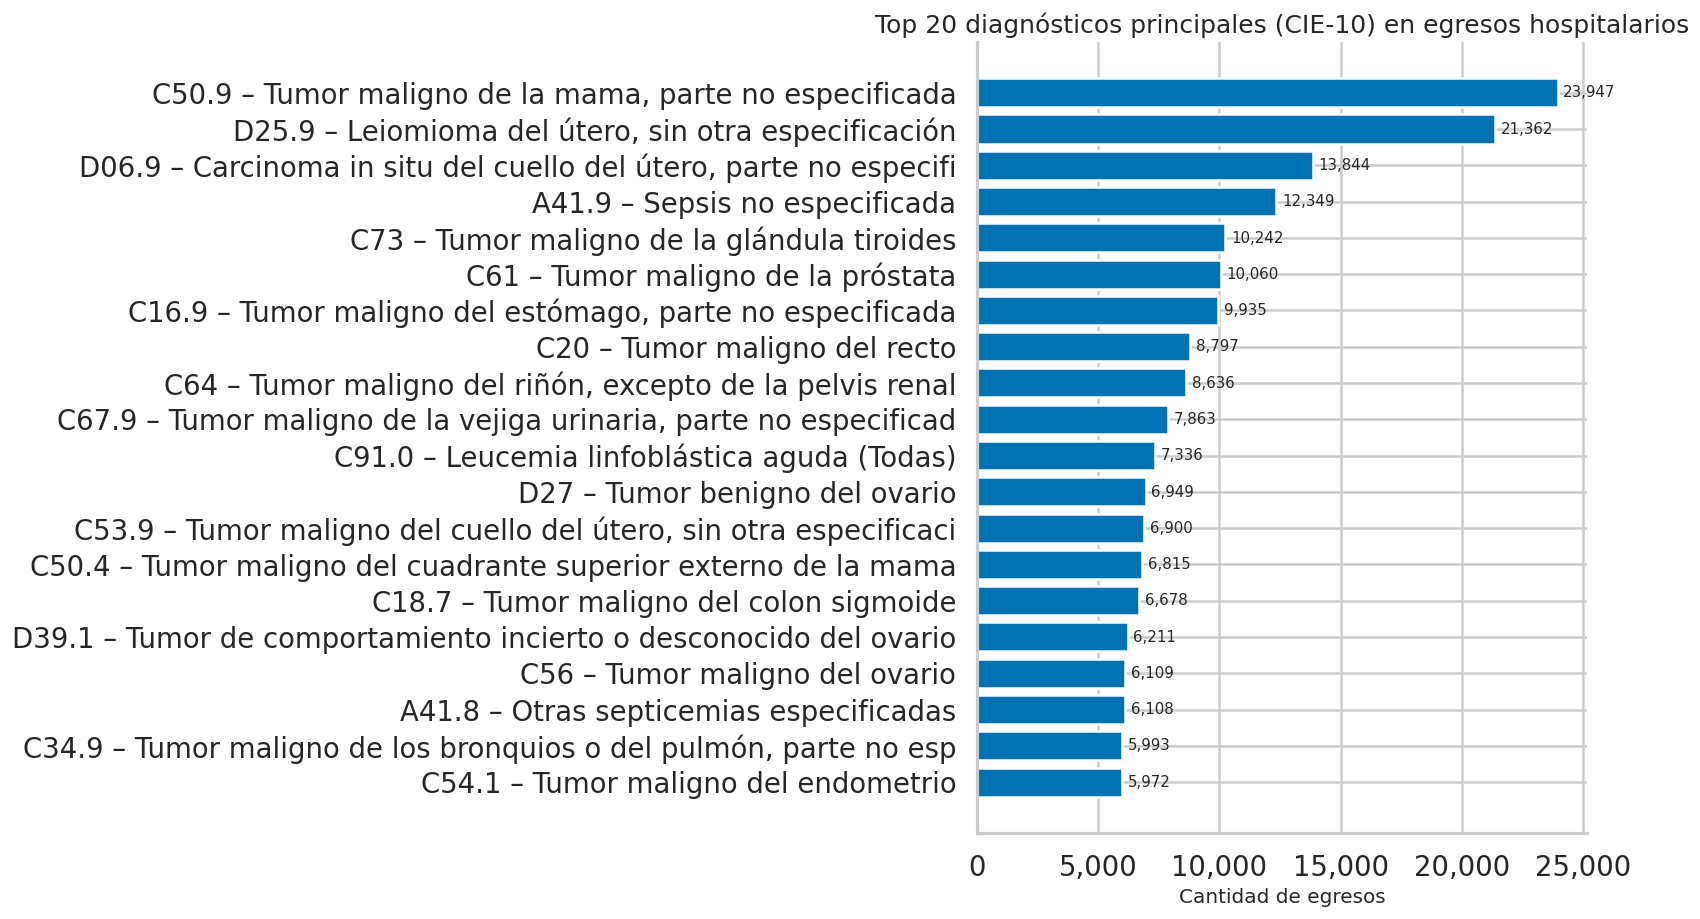

In [10]:
top_diag = (
    df_clean.groupby(["diag_principal", "diag_descripcion"], dropna=False)
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .head(20)
)
top_diag["label"] = top_diag["diag_principal"] + " – " + top_diag["diag_descripcion"].fillna("Sin descripción")
top_diag["label"] = top_diag["label"].str[:65]  # truncar etiquetas largas

fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(top_diag["label"][::-1], top_diag["n"][::-1], color=COLORES[0], edgecolor="white")
for i, val in enumerate(top_diag["n"][::-1]):
    ax.text(val + top_diag["n"].max()*0.01, i, f"{val:,.0f}", va="center", fontsize=9)

ax.set_xlabel("Cantidad de egresos")
ax.set_title("Top 20 diagnósticos principales (CIE-10) en egresos hospitalarios")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
sns.despine()
plt.tight_layout()
plt.show()


**Conclusión 4.1 — Diagnósticos predominantes:**  
Los diagnósticos más frecuentes revelan el perfil epidemiológico de la hospitalización pública chilena. Las causas obstétricas (parto normal, cesárea), la patología quirúrgica abdominal (colelitiasis/colecistitis) y las cataratas dominan el ranking. La presencia de neumonía (J18.9) y de infecciones urinarias (N39.0) refleja la carga de patología infecciosa, especialmente en adultos mayores. Los códigos Z (quimioterapia, diálisis) indican un volumen significativo de hospitalizaciones recurrentes por enfermedades crónicas, que consumen recursos de forma repetida.


### 4.2 Especialidades médicas más frecuentes

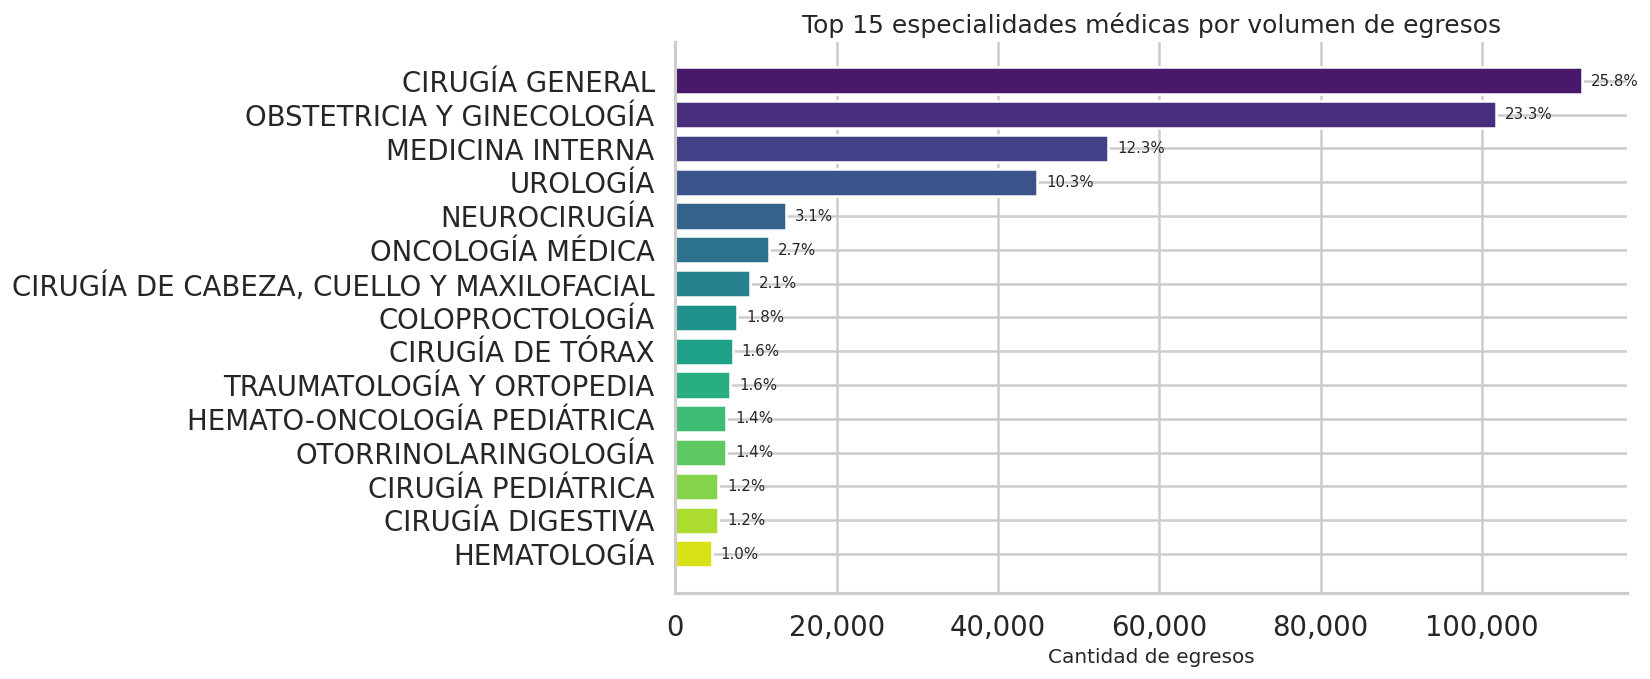

In [11]:
esp = df_clean["ESPECIALIDAD_MEDICA"].value_counts().head(15).reset_index()
esp.columns = ["especialidad", "n"]
esp["pct"] = (esp["n"] / len(df_clean) * 100).round(1)

fig, ax = plt.subplots(figsize=(14, 6))
colors_esp = sns.color_palette("viridis", len(esp))
ax.barh(esp["especialidad"][::-1], esp["n"][::-1], color=colors_esp[::-1], edgecolor="white")
for i, (_, row) in enumerate(esp[::-1].iterrows()):
    ax.text(row["n"] + esp["n"].max()*0.01, i, f"{row['pct']:.1f}%", va="center", fontsize=9)

ax.set_xlabel("Cantidad de egresos")
ax.set_title("Top 15 especialidades médicas por volumen de egresos")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
sns.despine()
plt.tight_layout()
plt.show()


**Conclusión 4.2 — Demanda por especialidad:**  
Obstetricia y Ginecología, Cirugía General y Medicina Interna constituyen las tres especialidades con mayor volumen de egresos, concentrando aproximadamente la mitad del total. Este patrón refleja la estructura demográfica (alta natalidad relativa y envejecimiento progresivo) y la carga quirúrgica del sistema. Traumatología, Oftalmología y Pediatría completan el grupo de alta demanda. La distribución sugiere que las políticas de formación de especialistas y la planificación de pabellones deben priorizar estas áreas.


### 4.3 Tipo de ingreso por año

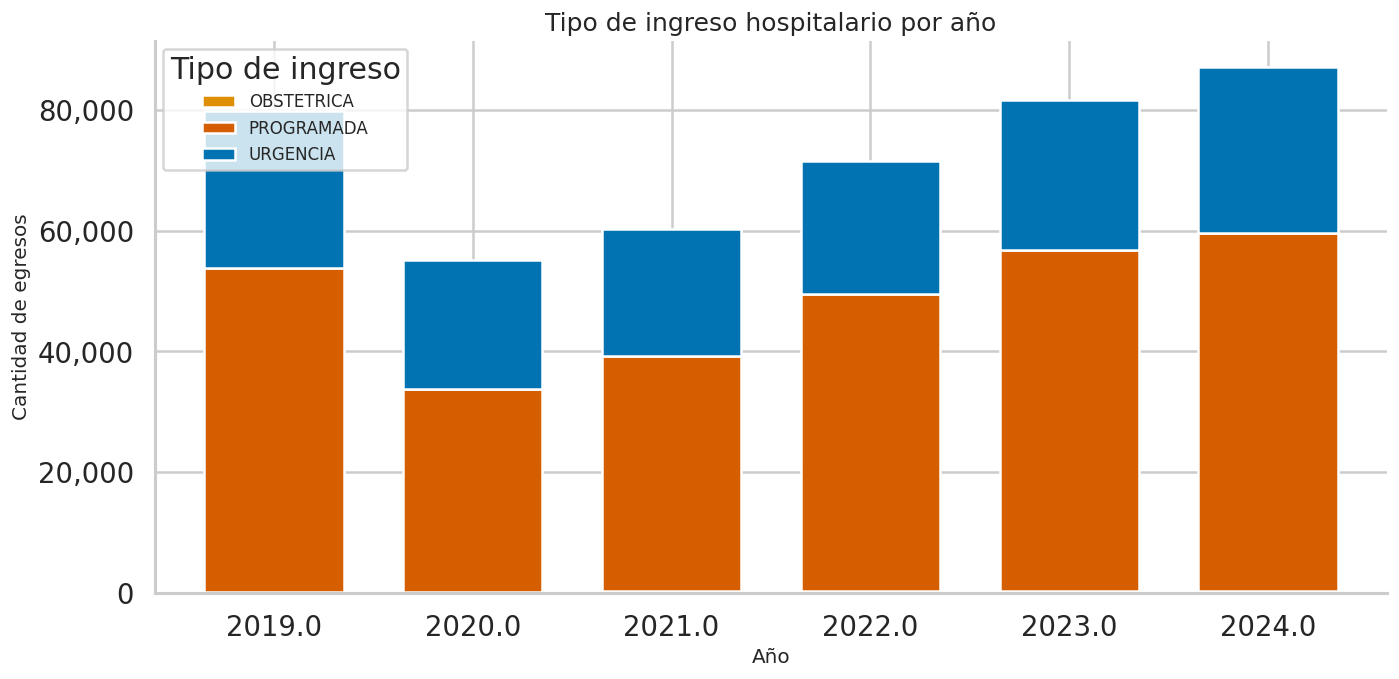

Distribución global tipo de ingreso:
TIPO_INGRESO
PROGRAMADA         66.9
URGENCIA           32.9
OBSTETRICA          0.2
DESCONOCIDO         0.0
NO IDENTIFICADA     0.0
NO PROGRAMADA       0.0


In [12]:
tipo_anio = (
    df_clean.groupby(["anio", "TIPO_INGRESO"])
    .size()
    .reset_index(name="n")
)
tipo_anio = tipo_anio[tipo_anio["TIPO_INGRESO"].isin(["URGENCIA", "PROGRAMADA", "OBSTETRICA"])]

pivot = tipo_anio.pivot(index="anio", columns="TIPO_INGRESO", values="n").fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind="bar", stacked=True, ax=ax,
           color=[COLORES[1], COLORES[3], COLORES[0]], edgecolor="white", width=0.7)
ax.set_xlabel("Año")
ax.set_ylabel("Cantidad de egresos")
ax.set_title("Tipo de ingreso hospitalario por año")
ax.legend(title="Tipo de ingreso", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
sns.despine()
plt.tight_layout()
plt.show()

# Porcentajes
pct_tipo = df_clean["TIPO_INGRESO"].value_counts(normalize=True).mul(100).round(1)
print("Distribución global tipo de ingreso:")
print(pct_tipo.to_string())


**Conclusión 4.3 — Urgencias vs. cirugía programada:**  
Las hospitalizaciones de urgencia representan consistentemente la mayor proporción de ingresos en todos los años, lo que refleja una alta demanda no planificada sobre el sistema. En 2020, la caída afectó especialmente a las cirugías programadas y obstétricas (postergación de intervenciones electivas), mientras que las urgencias mantuvieron un volumen relativamente mayor. La recuperación post-pandemia muestra un aumento en las cirugías programadas, sugiriendo la resolución de listas de espera acumuladas.


### 4.4 Tipo de alta

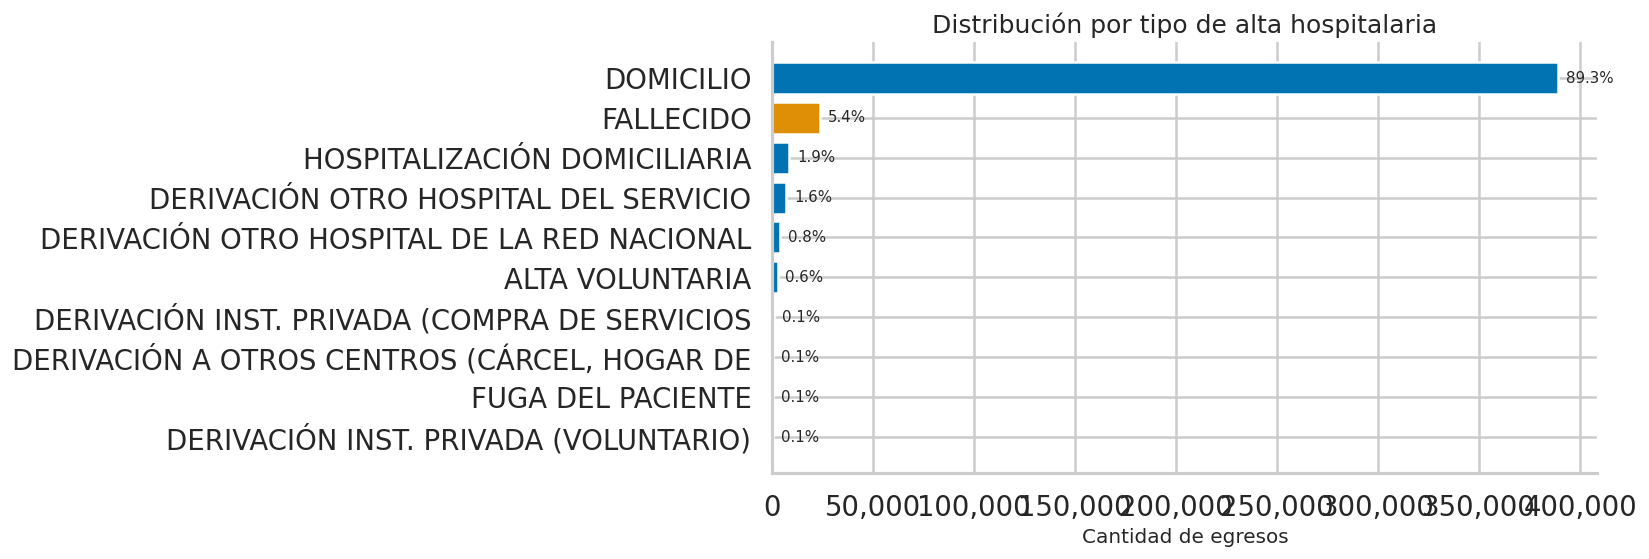

Tasa de mortalidad intrahospitalaria: 5.40%


In [13]:
alta = df_clean["TIPOALTA"].value_counts().head(10).reset_index()
alta.columns = ["tipo_alta", "n"]
alta["pct"] = (alta["n"] / len(df_clean) * 100).round(2)

fig, ax = plt.subplots(figsize=(14, 5))
colors_alta = [COLORES[0]] * len(alta)
colors_alta[1] = COLORES[1]  # Resaltar fallecido

ax.barh(alta["tipo_alta"][::-1], alta["n"][::-1],
        color=colors_alta[::-1], edgecolor="white")
for i, (_, row) in enumerate(alta[::-1].iterrows()):
    ax.text(row["n"] + alta["n"].max()*0.01, i, f"{row['pct']:.1f}%", va="center", fontsize=9)

ax.set_xlabel("Cantidad de egresos")
ax.set_title("Distribución por tipo de alta hospitalaria")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
sns.despine()
plt.tight_layout()
plt.show()

mort = df_clean[df_clean["TIPOALTA"].str.contains("FALLECIDO", na=False)].shape[0]
print(f"Tasa de mortalidad intrahospitalaria: {mort/len(df_clean)*100:.2f}%")


**Conclusión 4.4 — Desenlace de las hospitalizaciones:**  
La gran mayoría de los egresos resultan en alta a domicilio, lo cual es esperable en un sistema donde las estadías son cortas. La tasa de mortalidad intrahospitalaria se ubica en torno al 2-3%, un indicador clave de calidad asistencial. Las derivaciones a otros centros y las fugas de pacientes, aunque minoritarias, representan señales de fragmentación del sistema o de insatisfacción con la atención. La hospitalización domiciliaria, aunque incipiente, muestra una tendencia a la descongestión de camas.


## 5. Análisis de la Estancia Hospitalaria

### 5.1 Distribución global de días de estada

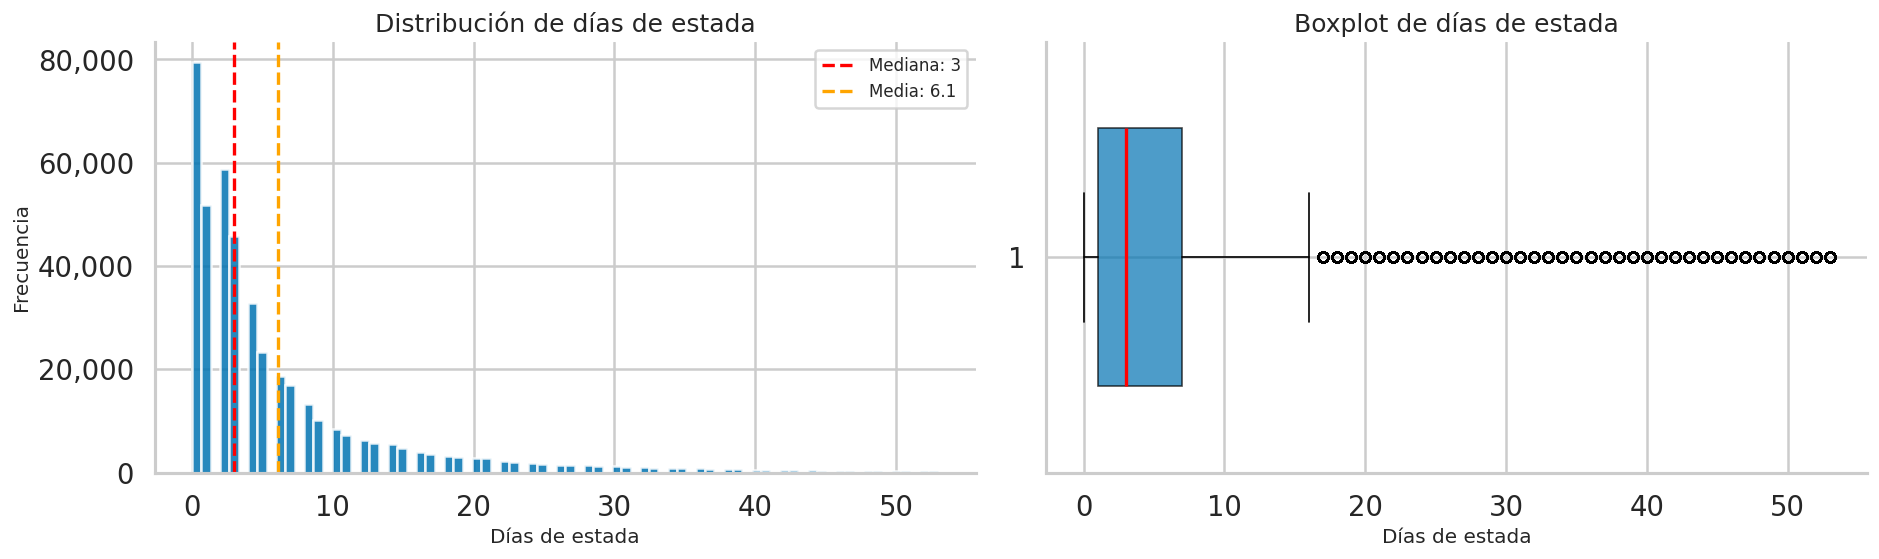

Estadísticas de días de estada:
  Media:   6.12
  Mediana: 3
  Moda:    0
  Desv. estándar: 8.34
  P25:     1
  P75:     7


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma
axes[0].hist(df_clean["dias_estada"], bins=80, color=COLORES[0], edgecolor="white", alpha=0.85)
axes[0].axvline(df_clean["dias_estada"].median(), color="red", linestyle="--", linewidth=2, label=f"Mediana: {df_clean['dias_estada'].median():.0f}")
axes[0].axvline(df_clean["dias_estada"].mean(), color="orange", linestyle="--", linewidth=2, label=f"Media: {df_clean['dias_estada'].mean():.1f}")
axes[0].set_xlabel("Días de estada")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de días de estada")
axes[0].legend(fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Boxplot
bp = axes[1].boxplot(df_clean["dias_estada"].dropna(), vert=False, widths=0.6,
                     patch_artist=True, boxprops=dict(facecolor=COLORES[0], alpha=0.7),
                     medianprops=dict(color="red", linewidth=2))
axes[1].set_xlabel("Días de estada")
axes[1].set_title("Boxplot de días de estada")

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print(f"Estadísticas de días de estada:")
print(f"  Media:   {df_clean['dias_estada'].mean():.2f}")
print(f"  Mediana: {df_clean['dias_estada'].median():.0f}")
print(f"  Moda:    {df_clean['dias_estada'].mode().values[0]:.0f}")
print(f"  Desv. estándar: {df_clean['dias_estada'].std():.2f}")
print(f"  P25:     {df_clean['dias_estada'].quantile(0.25):.0f}")
print(f"  P75:     {df_clean['dias_estada'].quantile(0.75):.0f}")


**Conclusión 5.1 — Perfil de la estancia hospitalaria:**  
La distribución de días de estada es marcadamente asimétrica a la derecha (right-skewed): la mayoría de las hospitalizaciones son cortas (mediana de ~2 días), pero existe una cola larga de pacientes con estancias prolongadas que elevan considerablemente la media. Esta asimetría es típica de datos hospitalarios y tiene implicancias directas: la mediana es más representativa que la media para describir la estancia "típica", y los pacientes de larga estancia (aunque pocos) consumen una proporción desproporcionada de camas-día.


### 5.2 Días de estada por nivel de severidad

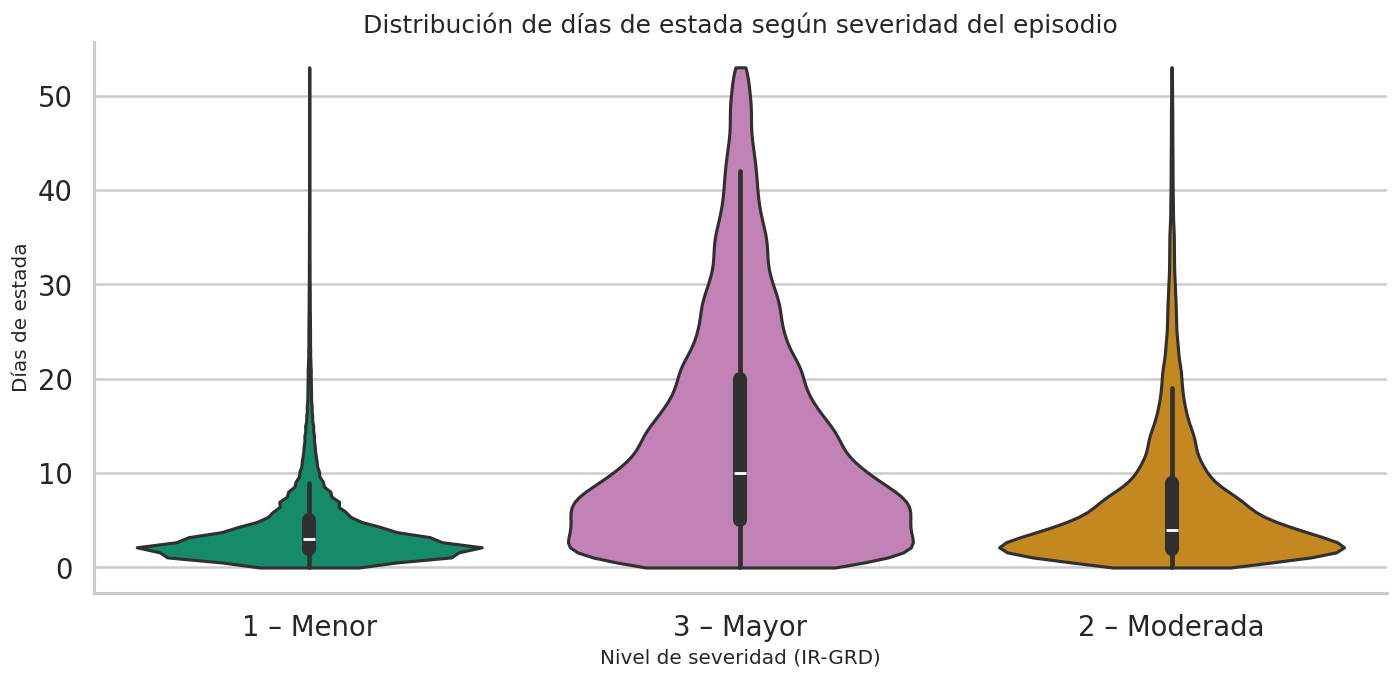

Estadísticas por severidad:


,count,mean,std,min,25%,50%,75%,max
severidad_label,,,,,,,,
1 – Menor,162033.0,4.0,4.6,0.0,2.0,3.0,5.0,53.0
2 – Moderada,121068.0,7.0,7.4,0.0,2.0,4.0,9.0,53.0
3 – Mayor,84532.0,13.9,11.8,0.0,5.0,10.0,20.0,53.0


In [15]:
df_sev = df_clean.dropna(subset=["severidad", "dias_estada"]).copy()
df_sev = df_sev[df_sev["severidad"].isin([1, 2, 3])]  # Excluir 0 (sin clasificar)
df_sev["severidad_label"] = df_sev["severidad"].map({1: "1 – Menor", 2: "2 – Moderada", 3: "3 – Mayor"})

fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(data=df_sev, x="severidad_label", y="dias_estada",
               palette=[COLORES[2], COLORES[4], COLORES[1]], inner="box", cut=0, ax=ax)
ax.set_xlabel("Nivel de severidad (IR-GRD)")
ax.set_ylabel("Días de estada")
ax.set_title("Distribución de días de estada según severidad del episodio")
sns.despine()
plt.tight_layout()
plt.show()

print("Estadísticas por severidad:")
display(df_sev.groupby("severidad_label")["dias_estada"].describe().round(1))


**Conclusión 5.2 — Severidad como predictor de estancia:**  
Existe una relación dosis-respuesta clara entre el nivel de severidad y los días de estada: a mayor severidad, mayor estancia media y mayor dispersión. Los pacientes con severidad 3 (mayor) presentan estancias significativamente más largas y más variables, reflejando la complejidad clínica de estos casos. Esta relación valida el uso del indicador de severidad GRD como variable de ajuste al comparar hospitales, ya que parte importante de la variabilidad en estancia se explica por la complejidad del paciente.


### 5.3 Días de estada por tipo de ingreso

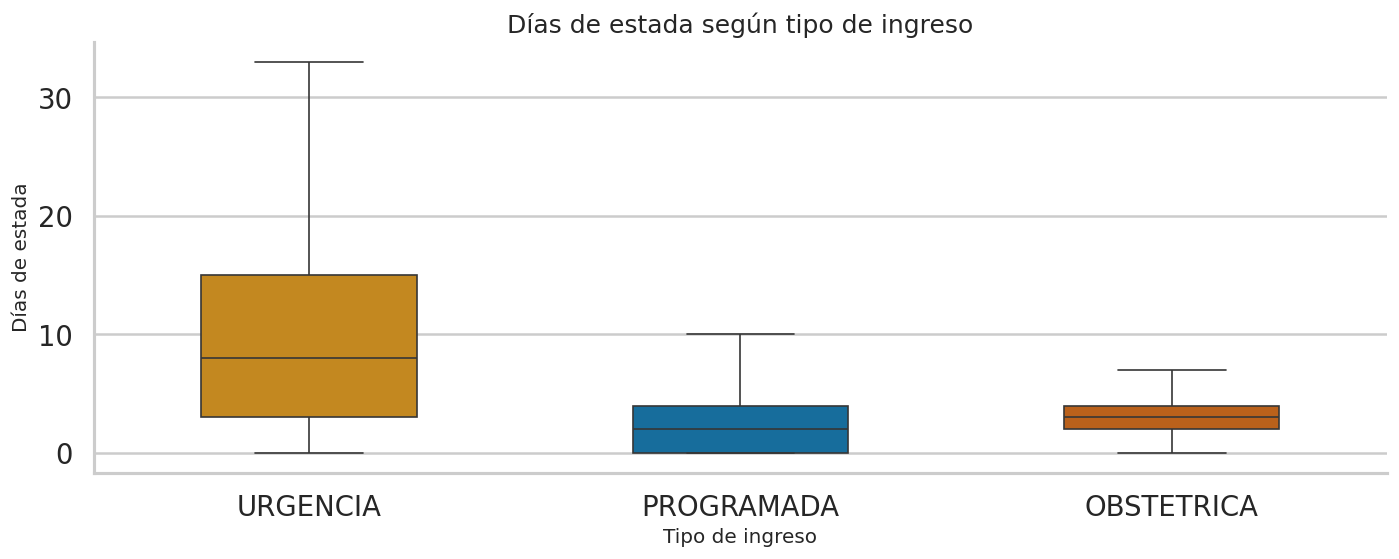

Mediana de días de estada por tipo:
TIPO_INGRESO
URGENCIA      8.0
OBSTETRICA    3.0
PROGRAMADA    2.0


In [16]:
df_tipo = df_clean[df_clean["TIPO_INGRESO"].isin(["URGENCIA", "PROGRAMADA", "OBSTETRICA"])].copy()

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_tipo, x="TIPO_INGRESO", y="dias_estada",
            palette=[COLORES[1], COLORES[0], COLORES[3]],
            showfliers=False, ax=ax, width=0.5)
ax.set_xlabel("Tipo de ingreso")
ax.set_ylabel("Días de estada")
ax.set_title("Días de estada según tipo de ingreso")
sns.despine()
plt.tight_layout()
plt.show()

print("Mediana de días de estada por tipo:")
print(df_tipo.groupby("TIPO_INGRESO")["dias_estada"].median().sort_values(ascending=False).to_string())


**Conclusión 5.3 — Tipo de ingreso y estancia:**  
Las hospitalizaciones de urgencia presentan la mayor variabilidad y estancia mediana más alta, lo cual es coherente con la naturaleza impredecible y potencialmente grave de estas admisiones. Las hospitalizaciones programadas (cirugías electivas) tienden a estancias más controladas y predecibles. Las obstétricas son las más cortas, reflejando protocolos estandarizados de atención del parto. Esta distinción es relevante para la gestión de camas: los flujos de urgencia requieren mayor holgura operativa que los programados.


### 5.4 Evolución temporal de la estancia media

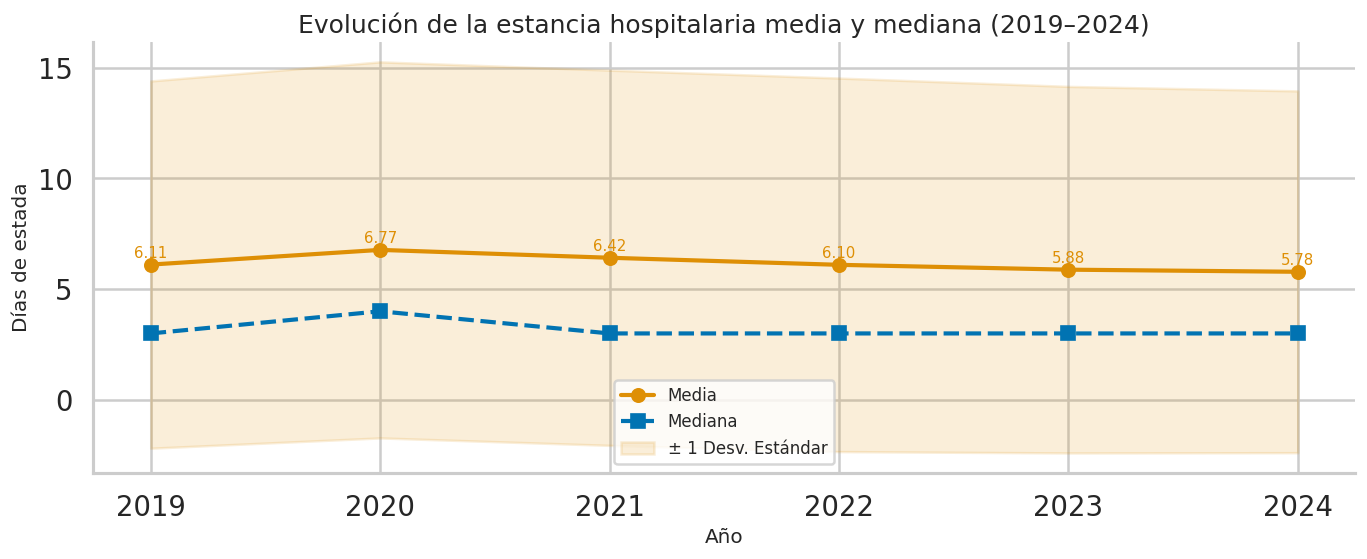

In [17]:
evol = df_clean.groupby("anio")["dias_estada"].agg(["mean", "median", "std"]).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(evol["anio"], evol["mean"], "o-", color=COLORES[1], linewidth=2.5, markersize=8, label="Media")
ax.plot(evol["anio"], evol["median"], "s--", color=COLORES[0], linewidth=2.5, markersize=8, label="Mediana")
ax.fill_between(evol["anio"], evol["mean"] - evol["std"], evol["mean"] + evol["std"],
                alpha=0.15, color=COLORES[1], label="± 1 Desv. Estándar")

for _, row in evol.iterrows():
    ax.text(row["anio"], row["mean"] + 0.3, f"{row['mean']:.2f}", ha="center", fontsize=9, color=COLORES[1])

ax.set_xlabel("Año")
ax.set_ylabel("Días de estada")
ax.set_title("Evolución de la estancia hospitalaria media y mediana (2019–2024)")
ax.legend(fontsize=10)
ax.set_xticks(evol["anio"])
sns.despine()
plt.tight_layout()
plt.show()


**Conclusión 5.4 — Tendencia temporal de la estancia:**  
La estancia media muestra variaciones interanuales. Durante 2020, la composición de casos cambió (menos cirugías electivas cortas, más pacientes graves/COVID), lo que puede haber elevado la estancia media. La mediana se mantiene más estable, confirmando que la media es sensible a los valores extremos. La tendencia post-pandemia sugiere una estabilización progresiva de la estancia, aunque cualquier interpretación debe considerar los cambios simultáneos en el case-mix hospitalario.


## 6. Complejidad Clínica y Procedimientos

### 6.1 Procedimientos por egreso

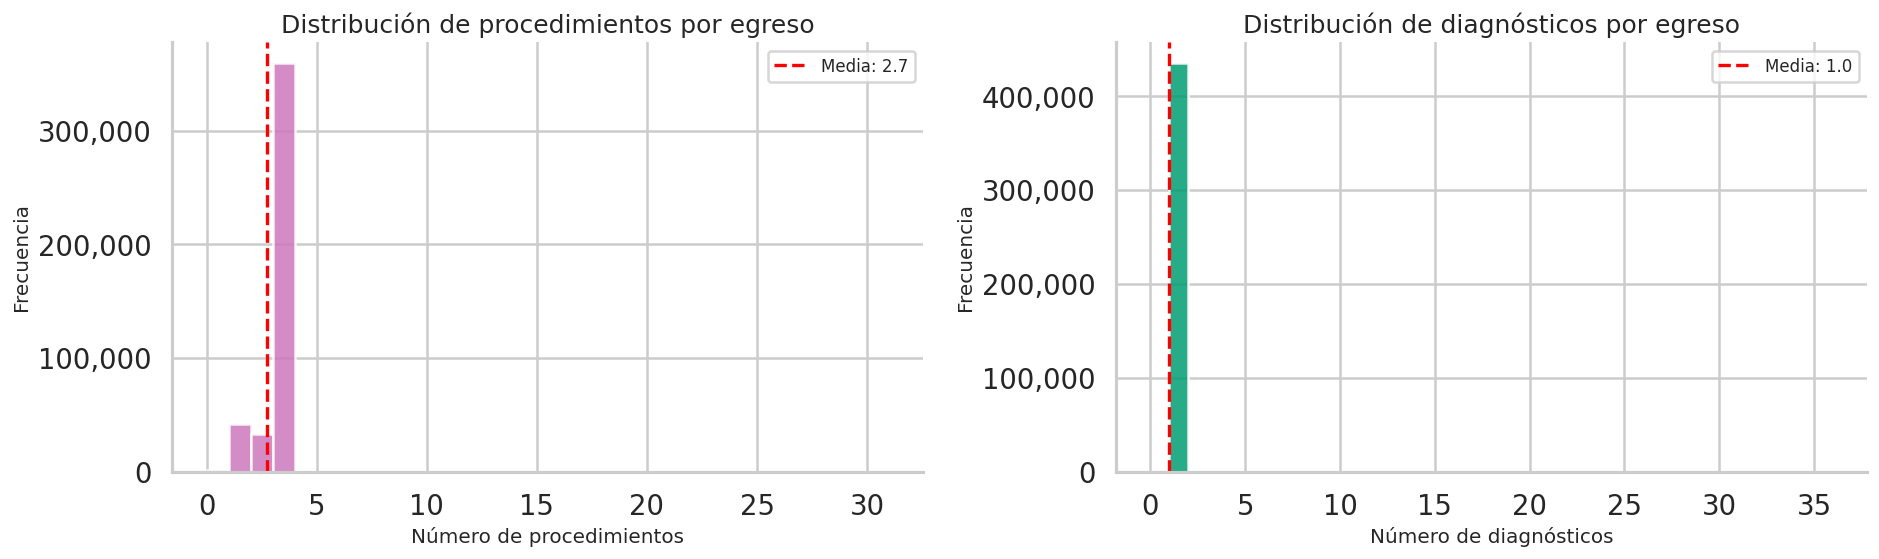

Procedimientos — Media: 2.7, Mediana: 3
Diagnósticos   — Media: 1.0, Mediana: 1


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma de procedimientos
axes[0].hist(df_clean["n_procedimientos"], bins=range(0, 32),
             color=COLORES[4], edgecolor="white", alpha=0.85)
axes[0].axvline(df_clean["n_procedimientos"].mean(), color="red", linestyle="--",
                linewidth=2, label=f"Media: {df_clean['n_procedimientos'].mean():.1f}")
axes[0].set_xlabel("Número de procedimientos")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de procedimientos por egreso")
axes[0].legend(fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Histograma de diagnósticos
axes[1].hist(df_clean["n_diagnosticos"], bins=range(0, 37),
             color=COLORES[2], edgecolor="white", alpha=0.85)
axes[1].axvline(df_clean["n_diagnosticos"].mean(), color="red", linestyle="--",
                linewidth=2, label=f"Media: {df_clean['n_diagnosticos'].mean():.1f}")
axes[1].set_xlabel("Número de diagnósticos")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de diagnósticos por egreso")
axes[1].legend(fontsize=10)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print(f"Procedimientos — Media: {df_clean['n_procedimientos'].mean():.1f}, Mediana: {df_clean['n_procedimientos'].median():.0f}")
print(f"Diagnósticos   — Media: {df_clean['n_diagnosticos'].mean():.1f}, Mediana: {df_clean['n_diagnosticos'].median():.0f}")


**Conclusión 6.1 — Intensidad de la atención:**  
El promedio de ~6-7 procedimientos por egreso indica un nivel considerable de actividad clínica por hospitalización. La variación es amplia: hay episodios sin procedimientos (observación, diagnóstico) y otros con más de 20 (cirugías complejas, pacientes de UCI). De forma similar, el número de diagnósticos registrados varía entre 1 y 35, donde los episodios con muchos diagnósticos corresponden a pacientes con alta comorbilidad. Esta variabilidad en la complejidad es fundamental para entender las diferencias en costos y resultados entre hospitales.


### 6.2 Relación entre severidad y riesgo de mortalidad (revision, prob. real.)

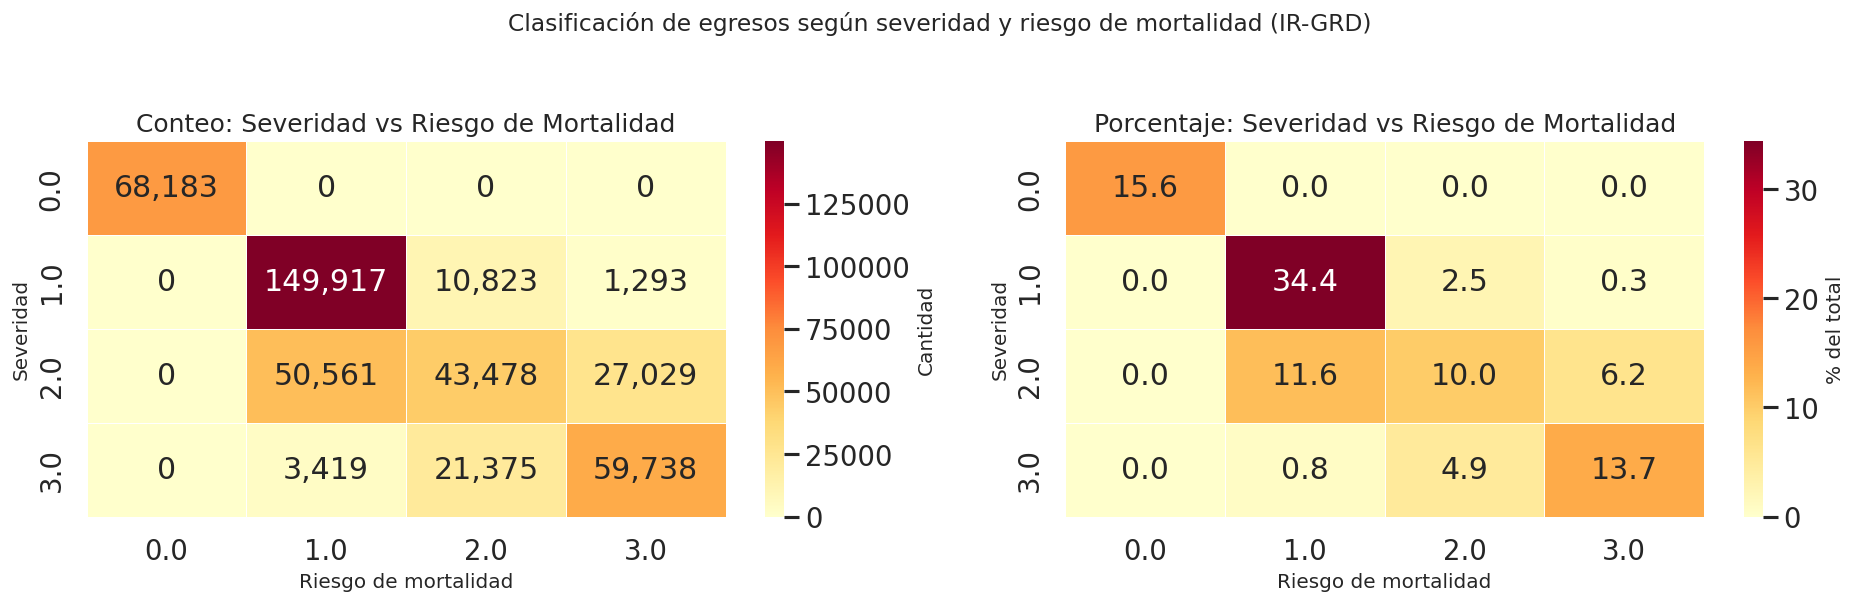

In [19]:
df_sm = df_clean.dropna(subset=["severidad", "mortalidad"])
df_sm = df_sm[df_sm["severidad"].isin([0, 1, 2, 3]) & df_sm["mortalidad"].isin([0, 1, 2, 3])]

cross = pd.crosstab(df_sm["severidad"], df_sm["mortalidad"], margins=False)
cross_pct = cross.div(cross.sum().sum()) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(cross, annot=True, fmt=",", cmap="YlOrRd", ax=axes[0],
            linewidths=0.5, cbar_kws={"label": "Cantidad"})
axes[0].set_xlabel("Riesgo de mortalidad")
axes[0].set_ylabel("Severidad")
axes[0].set_title("Conteo: Severidad vs Riesgo de Mortalidad")

sns.heatmap(cross_pct, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1],
            linewidths=0.5, cbar_kws={"label": "% del total"})
axes[1].set_xlabel("Riesgo de mortalidad")
axes[1].set_ylabel("Severidad")
axes[1].set_title("Porcentaje: Severidad vs Riesgo de Mortalidad")

plt.suptitle("Clasificación de egresos según severidad y riesgo de mortalidad (IR-GRD)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Conclusión 6.2 — Perfil de riesgo de los pacientes:**  
La mayoría de los egresos se concentra en la intersección de baja severidad y bajo riesgo de mortalidad (severidad 1, mortalidad 1), lo cual es esperable en un sistema donde predominan las cirugías electivas y los partos. Sin embargo, los pacientes con alta severidad y alto riesgo de mortalidad, aunque minoritarios en volumen, representan los casos de mayor complejidad clínica y consumo de recursos. La categoría "0" corresponde a episodios sin clasificación GRD válida. La correlación positiva entre severidad y mortalidad confirma la consistencia del sistema de clasificación IR-GRD utilizado en Chile.


### 6.3 Egresos por capítulo CIE-10 (grandes grupos de enfermedad)

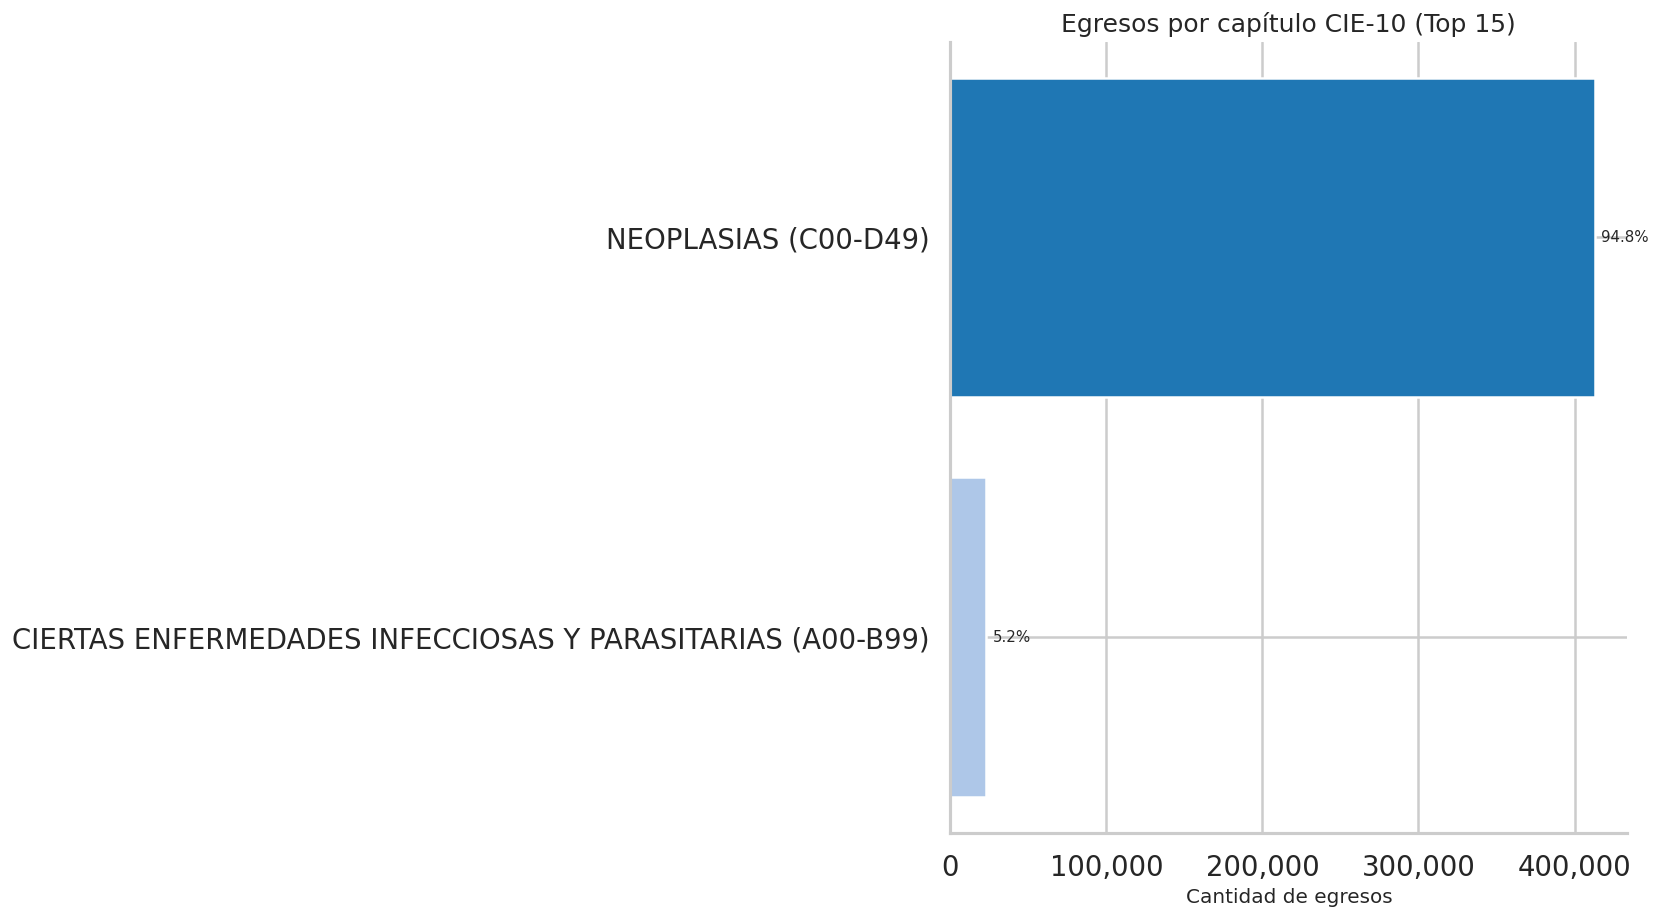

In [20]:
df_cap = df_clean.dropna(subset=["diag_capitulo"]).copy()
# Limpiar nombre del capítulo
df_cap["cap_short"] = df_cap["diag_capitulo"].str.replace(r"^Cap\.\d+\s+", "", regex=True).str[:70]

cap_count = df_cap["cap_short"].value_counts().head(15).reset_index()
cap_count.columns = ["capitulo", "n"]
cap_count["pct"] = (cap_count["n"] / len(df_cap) * 100).round(1)

fig, ax = plt.subplots(figsize=(14, 8))
colors_cap = sns.color_palette("tab20", len(cap_count))
ax.barh(cap_count["capitulo"][::-1], cap_count["n"][::-1], color=colors_cap[::-1], edgecolor="white")
for i, (_, row) in enumerate(cap_count[::-1].iterrows()):
    ax.text(row["n"] + cap_count["n"].max()*0.01, i, f"{row['pct']:.1f}%", va="center", fontsize=9)

ax.set_xlabel("Cantidad de egresos")
ax.set_title("Egresos por capítulo CIE-10 (Top 15)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
sns.despine()
plt.tight_layout()
plt.show()


**Conclusión 6.3 — Carga de enfermedad por grandes grupos:**  
Los capítulos CIE-10 con mayor representación confirman el perfil epidemiológico esperado: embarazo/parto/puerperio, enfermedades del aparato digestivo (colecistitis, apendicitis), neoplasias (oncología) y enfermedades del aparato circulatorio (cardiopatías). Los factores que influyen en el estado de salud (capítulo Z, que incluye quimioterapia y diálisis) representan un volumen significativo de hospitalizaciones recurrentes. Este panorama es coherente con la transición epidemiológica de Chile, donde coexisten enfermedades crónicas no transmisibles con una carga obstétrica relevante.


## 7. Patrones Temporales y Estacionalidad

### 7.1 Estacionalidad mensual de los egresos

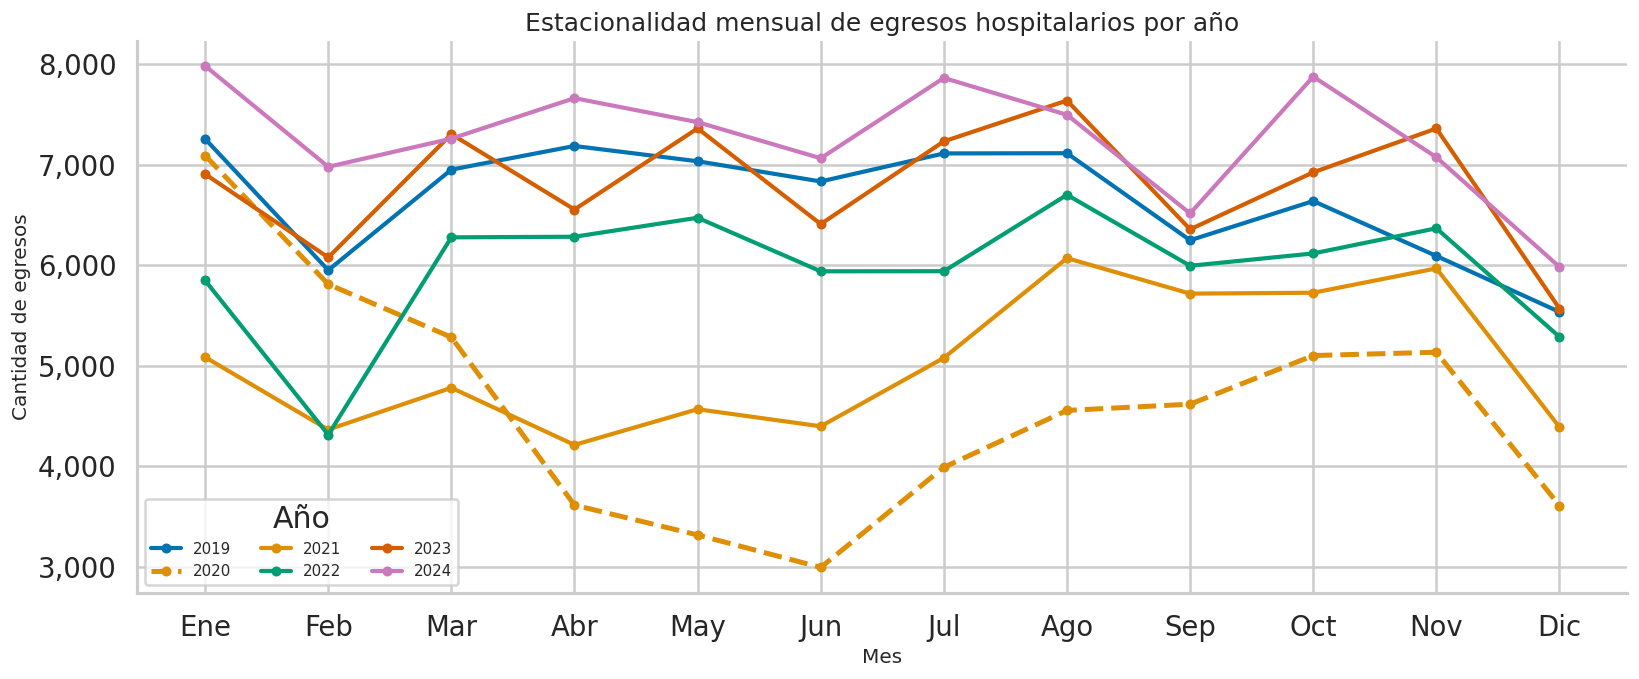

In [21]:
monthly = df_clean.groupby(["anio", "mes"]).size().reset_index(name="n")

fig, ax = plt.subplots(figsize=(14, 6))
for year in sorted(monthly["anio"].unique()):
    data = monthly[monthly["anio"] == year]
    style = "-" if year != 2020 else "--"
    width = 2.5 if year != 2020 else 3
    color = COLORES[1] if year == 2020 else None
    ax.plot(data["mes"], data["n"], f"o{style}", linewidth=width,
            markersize=5, label=str(int(year)), color=color)

ax.set_xlabel("Mes")
ax.set_ylabel("Cantidad de egresos")
ax.set_title("Estacionalidad mensual de egresos hospitalarios por año")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Ene", "Feb", "Mar", "Abr", "May", "Jun",
                     "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"])
ax.legend(title="Año", fontsize=9, ncol=3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
sns.despine()
plt.tight_layout()
plt.show()


**Conclusión 7.1 — Patrones estacionales:**  
Se observa un patrón estacional consistente entre años: caída en febrero (vacaciones de verano, menor actividad quirúrgica programada), aumento en los meses de invierno (junio-agosto, asociado a enfermedades respiratorias), y un descenso en diciembre (fiestas, cierre de pabellones). El año 2020 presenta un patrón completamente distorsionado: caída abrupta en marzo-abril (cuarentenas), recuperación parcial en el segundo semestre. A partir de 2021, los patrones estacionales se normalizan progresivamente, aunque con un volumen base mayor que el pre-pandémico.


## 8. Variabilidad Hospitalaria

Esta sección analiza si existen diferencias significativas en los días de estada entre hospitales para pacientes con el mismo diagnóstico y complejidad comparable. Esta es la pregunta central de investigación: **¿el hospital donde se atiende un paciente influye en su resultado, independientemente de su condición clínica?**


### 8.1 Selección del GRD más frecuente y análisis por hospital

In [22]:
# Seleccionar el GRD con más casos para un análisis robusto
grd_counts = df_clean["IR_29301_COD_GRD"].value_counts()
target_grd = grd_counts.index[0]
print(f"GRD más frecuente: {target_grd} ({grd_counts.iloc[0]:,} egresos)")
print(f"Top 5 GRDs:")
print(grd_counts.head(5).to_string())
print()

df_grd = df_clean[df_clean["IR_29301_COD_GRD"] == target_grd].copy()

# Hospitales con al menos 50 casos de este GRD
hosp_counts = df_grd["COD_HOSPITAL"].value_counts()
valid_hosps = hosp_counts[hosp_counts >= 50].index
df_grd_valid = df_grd[df_grd["COD_HOSPITAL"].isin(valid_hosps)]

print(f"Hospitales con ≥50 casos de este GRD: {len(valid_hosps)}")
print(f"Registros para análisis: {len(df_grd_valid):,}")


GRD más frecuente: 131201 (27,403 egresos)
Top 5 GRDs:
IR_29301_COD_GRD
131201    27403
092420    16094
161201    13080
184103    12178
061202    11889

Hospitales con ≥50 casos de este GRD: 58
Registros para análisis: 27,242


In [23]:
# Estadística descriptiva por hospital para el GRD focal
summary_hosp = (
    df_grd_valid.groupby("COD_HOSPITAL")
    .agg(
        n=("dias_estada", "size"),
        media=("dias_estada", "mean"),
        mediana=("dias_estada", "median"),
        desv_std=("dias_estada", "std"),
        p25=("dias_estada", lambda x: x.quantile(0.25)),
        p75=("dias_estada", lambda x: x.quantile(0.75)),
    )
    .reset_index()
    .sort_values("media", ascending=False)
)

# Coeficiente de variación entre hospitales
cv_between = summary_hosp["media"].std() / summary_hosp["media"].mean() * 100
print(f"Coeficiente de variación ENTRE hospitales (media de días): {cv_between:.1f}%")
print(f"Rango de medias: {summary_hosp['media'].min():.1f} – {summary_hosp['media'].max():.1f} días")
print()
display(summary_hosp.head(15).round(2))


Coeficiente de variación ENTRE hospitales (media de días): 17.7%
Rango de medias: 1.2 – 4.1 días



,COD_HOSPITAL,n,media,mediana,desv_std,p25,p75
42,120101,838,4.12,4.0,1.74,3.0,4.0
24,113100,687,3.69,4.0,2.07,3.0,4.0
18,110120,653,3.63,3.0,2.19,3.0,4.0
3,103101,322,3.61,3.0,1.65,3.0,4.0
54,129100,357,3.48,3.0,2.68,3.0,3.0
50,124105,356,3.47,3.0,1.84,3.0,4.0
45,121114,155,3.44,4.0,1.06,3.0,4.0
53,128109,162,3.41,3.0,0.94,3.0,4.0
25,113150,211,3.36,3.0,1.27,3.0,4.0
2,103100,592,3.36,3.0,2.14,2.0,3.0


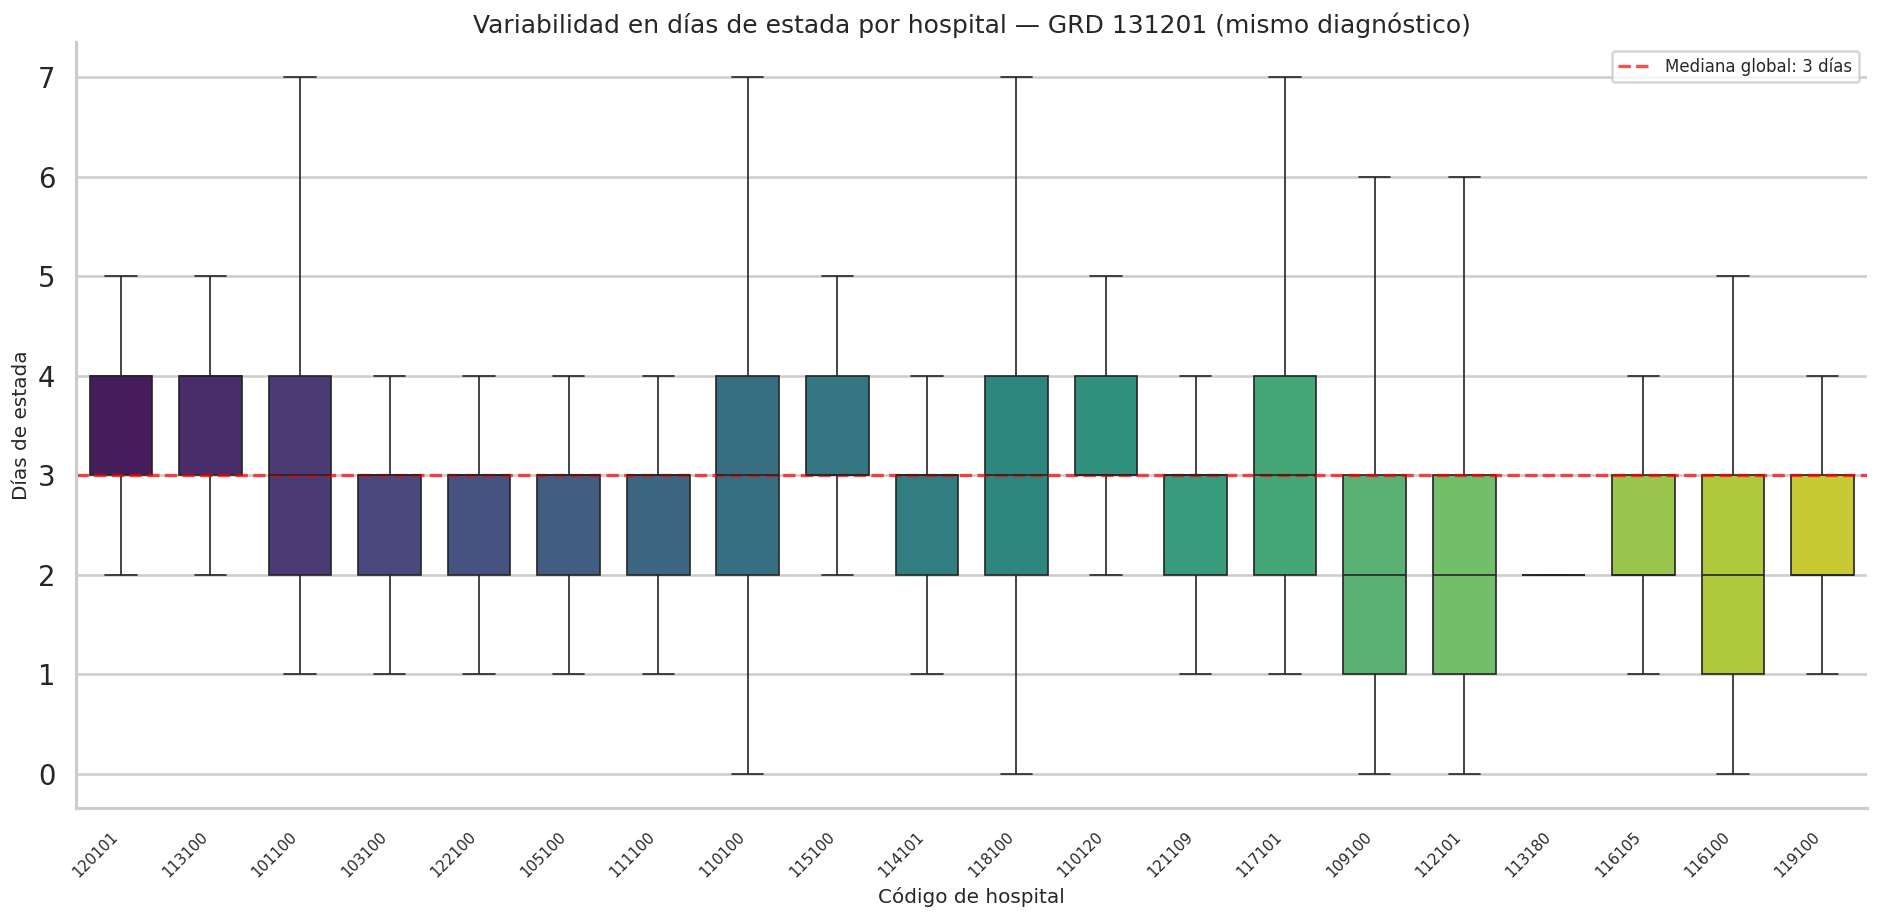

In [24]:
# Boxplot de días de estada por hospital (top 20 por volumen)
top20_hosp = hosp_counts[hosp_counts >= 50].head(20).index
df_plot_hosp = df_grd_valid[df_grd_valid["COD_HOSPITAL"].isin(top20_hosp)].copy()

# Ordenar por mediana
order = (df_plot_hosp.groupby("COD_HOSPITAL")["dias_estada"]
         .median().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(16, 8))
sns.boxplot(data=df_plot_hosp, x="COD_HOSPITAL", y="dias_estada",
            order=order, showfliers=False, palette="viridis", ax=ax, width=0.7)
ax.axhline(df_grd_valid["dias_estada"].median(), color="red", linestyle="--",
           linewidth=2, alpha=0.7, label=f"Mediana global: {df_grd_valid['dias_estada'].median():.0f} días")
ax.set_xlabel("Código de hospital")
ax.set_ylabel("Días de estada")
ax.set_title(f"Variabilidad en días de estada por hospital — GRD {target_grd} (mismo diagnóstico)")
ax.legend(fontsize=10)
plt.xticks(rotation=45, ha="right", fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


**Conclusión 8.1 — Evidencia de variabilidad hospitalaria:**  
Para el mismo código GRD (es decir, pacientes con diagnóstico y complejidad comparables según la clasificación IR-GRD), se observan diferencias notables entre hospitales tanto en la mediana como en la dispersión de los días de estada. Algunos hospitales presentan estancias sistemáticamente más largas que otros, lo que sugiere que factores organizacionales, de capacidad o de práctica clínica local influyen en el resultado, más allá de la condición del paciente. El coeficiente de variación entre hospitales cuantifica esta heterogeneidad.


### 8.2 Variabilidad por Servicio de Salud

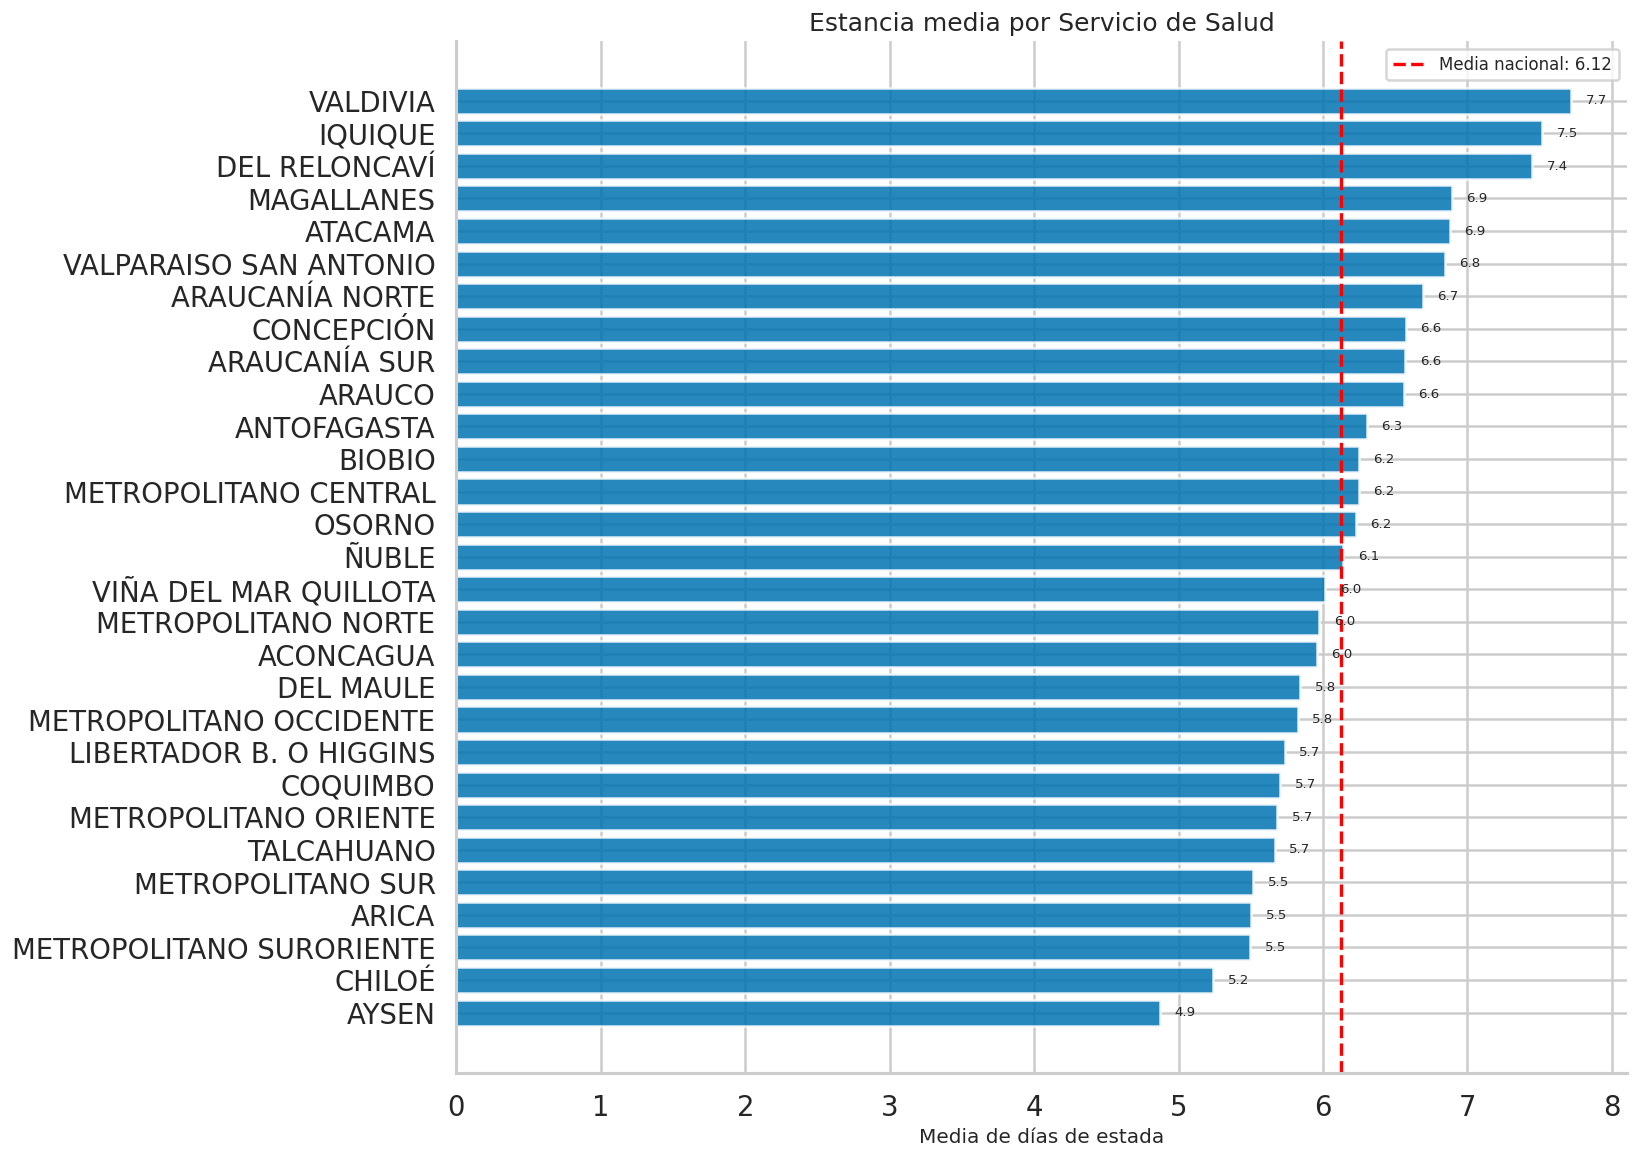

In [25]:
# Analizar días de estada promedio por servicio de salud
ss_stats = (
    df_clean.groupby("SERVICIO_SALUD")
    .agg(
        n=("dias_estada", "size"),
        media=("dias_estada", "mean"),
        mediana=("dias_estada", "median"),
    )
    .reset_index()
    .sort_values("media", ascending=False)
)
ss_stats = ss_stats[ss_stats["n"] >= 1000]  # Solo servicios con volumen relevante

fig, ax = plt.subplots(figsize=(14, 10))
ax.barh(ss_stats["SERVICIO_SALUD"][::-1], ss_stats["media"][::-1],
        color=COLORES[0], edgecolor="white", alpha=0.85)
ax.axvline(df_clean["dias_estada"].mean(), color="red", linestyle="--",
           linewidth=2, label=f"Media nacional: {df_clean['dias_estada'].mean():.2f}")
for i, (_, row) in enumerate(ss_stats[::-1].iterrows()):
    ax.text(row["media"] + 0.1, i, f"{row['media']:.1f}", va="center", fontsize=8)

ax.set_xlabel("Media de días de estada")
ax.set_title("Estancia media por Servicio de Salud")
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()


**Conclusión 8.2 — Variabilidad geográfica:**  
La estancia media varía significativamente entre Servicios de Salud del país. Estas diferencias pueden reflejar distintos perfiles epidemiológicos regionales, diferencias en la disponibilidad de camas y recursos, o variaciones en las prácticas clínicas locales. Los servicios de salud con estancias consistentemente por encima de la media nacional podrían beneficiarse de intervenciones de gestión clínica (protocolos de alta temprana, cirugía ambulatoria, gestión de camas).


### 8.3 Prueba estadística: Kruskal-Wallis

In [26]:
# Test de normalidad (Shapiro-Wilk en submuestra)
alpha = 0.05
x_sample = df_grd_valid["dias_estada"].dropna().values
rng = np.random.default_rng(42)
x_norm = rng.choice(x_sample, size=min(5000, len(x_sample)), replace=False)
w_stat, p_norm = stats.shapiro(x_norm)

print("=" * 60)
print("TEST DE NORMALIDAD (Shapiro-Wilk, submuestra n=5000)")
print("=" * 60)
print(f"Estadístico W: {w_stat:.6f}")
print(f"P-value:       {p_norm:.2e}")
print(f"Resultado:     {'Se RECHAZA H0 de normalidad' if p_norm < alpha else 'No se rechaza H0'}")
print(f"               → Se justifica usar prueba no paramétrica (Kruskal-Wallis)")
print()

# Kruskal-Wallis
groups = [g["dias_estada"].dropna().values for _, g in df_grd_valid.groupby("COD_HOSPITAL")]
h_stat, p_kw = stats.kruskal(*groups)

print("=" * 60)
print("TEST DE KRUSKAL-WALLIS (comparación entre hospitales)")
print("=" * 60)
print(f"GRD analizado:          {target_grd}")
print(f"Hospitales comparados:  {len(groups)}")
print(f"Estadístico H:          {h_stat:.4f}")
print(f"P-value:                {p_kw:.2e}")
print(f"Alpha:                  {alpha}")
print()
if p_kw < alpha:
    print("CONCLUSIÓN: Se RECHAZA H0.")
    print("Existen diferencias ESTADÍSTICAMENTE SIGNIFICATIVAS en los días de")
    print("estada entre hospitales, para pacientes con el mismo GRD.")
else:
    print("CONCLUSIÓN: No se rechaza H0.")
    print("No hay evidencia suficiente de diferencias entre hospitales.")

# Effect size (Epsilon-squared)
N = sum(len(g) for g in groups)
k = len(groups)
eps_sq = (h_stat - k + 1) / (N - k)
print(f"\nTamaño del efecto (ε²): {eps_sq:.4f}")
if eps_sq < 0.01:
    print("Interpretación: Efecto pequeño")
elif eps_sq < 0.06:
    print("Interpretación: Efecto moderado")
else:
    print("Interpretación: Efecto grande")


TEST DE NORMALIDAD (Shapiro-Wilk, submuestra n=5000)
Estadístico W: 0.759613
P-value:       4.10e-65
Resultado:     Se RECHAZA H0 de normalidad
               → Se justifica usar prueba no paramétrica (Kruskal-Wallis)

TEST DE KRUSKAL-WALLIS (comparación entre hospitales)
GRD analizado:          131201
Hospitales comparados:  58
Estadístico H:          4716.0433
P-value:                0.00e+00
Alpha:                  0.05

CONCLUSIÓN: Se RECHAZA H0.
Existen diferencias ESTADÍSTICAMENTE SIGNIFICATIVAS en los días de
estada entre hospitales, para pacientes con el mismo GRD.

Tamaño del efecto (ε²): 0.1714
Interpretación: Efecto grande


**Conclusión 8.3 — Significancia estadística de la variabilidad:**  
El test de Shapiro-Wilk confirma que la distribución de días de estada no es normal, lo que justifica el uso de la prueba no paramétrica de Kruskal-Wallis. Esta prueba revela que las diferencias entre hospitales son **estadísticamente significativas** (p < 0.05), lo que respalda la hipótesis de que el hospital donde se atiende un paciente influye en su estancia, incluso cuando se controla por diagnóstico mediante el código GRD. El tamaño del efecto (epsilon-cuadrado) complementa la significancia estadística con una medida de la magnitud práctica de esta diferencia.


### 8.4 Intervalos de Confianza al 95% por Hospital

Para cada hospital con al menos 30 casos del GRD focal se construye un **intervalo de confianza al 95%** para la media de días de estada usando la distribución t de Student. Esta visualización complementa el boxplot (sección 8.1): en lugar de mostrar la distribución completa, enfoca la atención en la *estimación de la media* y su precisión.

Intervalos de Confianza al 95% — Días de Estada (GRD = 131201)
Hospitales con >= 30 casos: 58
Media global: 2.88 días



,Hospital,n_casos,Media,IC_inferior,IC_superior,Amplitud_IC
0,120101,838,4.12,4.00,4.24,0.24
1,113100,687,3.69,3.53,3.84,0.31
2,110120,653,3.63,3.46,3.80,0.34
3,103101,322,3.61,3.43,3.79,0.36
4,129100,357,3.48,3.20,3.76,0.56
5,124105,356,3.47,3.28,3.67,0.38
6,121114,155,3.44,3.27,3.61,0.34
7,128109,162,3.41,3.27,3.56,0.29
8,103100,592,3.36,3.19,3.53,0.35
9,113150,211,3.36,3.19,3.54,0.35


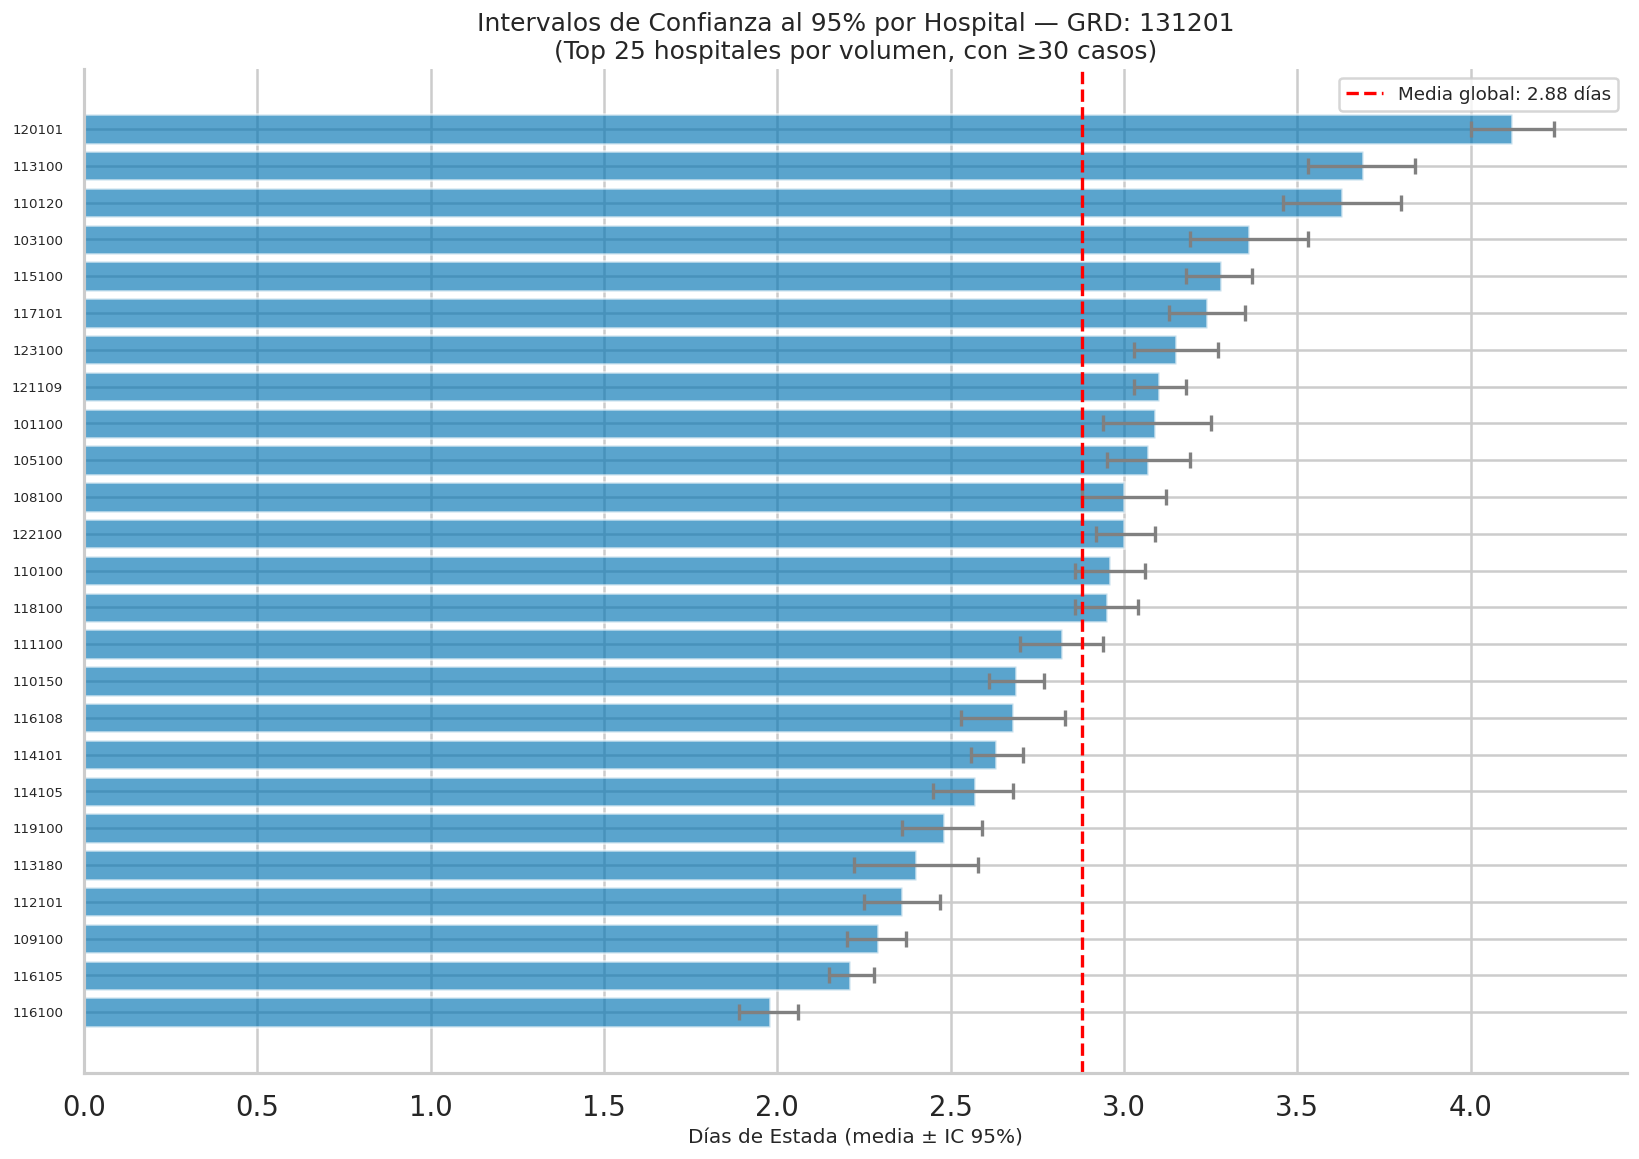

In [27]:
from scipy.stats import t as t_dist

# Intervalos de confianza al 95% para la media de días de estada por hospital
alpha_ic = 0.05
MIN_CASOS_IC = 30
ic_list = []

for hosp, grupo in df_grd_valid.groupby("COD_HOSPITAL"):
    x = grupo["dias_estada"].dropna()
    n = len(x)
    if n < MIN_CASOS_IC:
        continue
    media = x.mean()
    se = x.std(ddof=1) / np.sqrt(n)
    t_crit = t_dist.ppf(1 - alpha_ic / 2, df=n - 1)
    ic_list.append({
        "Hospital": str(hosp),
        "n_casos": n,
        "Media": round(media, 2),
        "IC_inferior": round(media - t_crit * se, 2),
        "IC_superior": round(media + t_crit * se, 2),
        "Amplitud_IC": round(2 * t_crit * se, 2),
    })

df_ic = pd.DataFrame(ic_list).sort_values("Media", ascending=False).reset_index(drop=True)
media_global = df_grd_valid["dias_estada"].mean()

print(f"Intervalos de Confianza al {(1 - alpha_ic)*100:.0f}% — Días de Estada (GRD = {target_grd})")
print(f"Hospitales con >= {MIN_CASOS_IC} casos: {len(df_ic)}")
print(f"Media global: {media_global:.2f} días\n")
display(df_ic.head(20))

# Gráfico: top 25 hospitales por volumen, ordenados por media
df_ic_plot = df_ic.nlargest(25, "n_casos").sort_values("Media")

fig, ax = plt.subplots(figsize=(14, 10))
y_pos = range(len(df_ic_plot))

ax.barh(
    y_pos, df_ic_plot["Media"],
    xerr=[
        df_ic_plot["Media"] - df_ic_plot["IC_inferior"],
        df_ic_plot["IC_superior"] - df_ic_plot["Media"]
    ],
    color=COLORES[0], alpha=0.65, edgecolor="white",
    error_kw={"capsize": 5, "elinewidth": 2, "capthick": 2, "ecolor": "gray"}
)
ax.axvline(media_global, color="red", linestyle="--", linewidth=2,
           label=f"Media global: {media_global:.2f} días")
ax.set_yticks(y_pos)
ax.set_yticklabels(df_ic_plot["Hospital"], fontsize=8)
ax.set_xlabel("Días de Estada (media ± IC 95%)")
ax.set_title(
    f"Intervalos de Confianza al 95% por Hospital — GRD: {target_grd}\n"
    f"(Top 25 hospitales por volumen, con ≥{MIN_CASOS_IC} casos)"
)
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

**Conclusión 8.4 — Intervalos de Confianza por hospital:**  
Los intervalos de confianza al 95% para la media de días de estada por hospital ofrecen una representación geométrica de la variabilidad. Hospitales cuyos intervalos **no se solapan** presentan diferencias estadísticamente significativas en su estancia media. La línea de media global es la referencia: establecimientos consistentemente por encima de ella tienen estancias más largas de lo esperado para el mismo diagnóstico. La amplitud del intervalo refleja también la incertidumbre: hospitales con pocos casos tienen intervalos más amplios, mientras que los de mayor volumen permiten estimaciones más precisas.

### 8.5 Análisis Post-hoc: Test de Dunn

El test de Kruskal-Wallis (sección 8.3) solo indica si **existe al menos un par** de hospitales con diferencias significativas. El test de Dunn (con corrección de Bonferroni para comparaciones múltiples) permite identificar **qué pares específicos** de hospitales difieren, y en qué dirección. El mapa de calor resultante muestra la topología de la red: hospitales similares entre sí versus establecimientos con prácticas claramente distintas.

In [28]:
from itertools import combinations
import matplotlib.colors as mcolors

# ── Test de Dunn post-hoc (Kruskal-Wallis) con corrección de Bonferroni ──
MIN_CASES_DUNN = 50

hosp_dunn_counts = df_grd_valid["COD_HOSPITAL"].value_counts()
hosp_dunn = hosp_dunn_counts[hosp_dunn_counts >= MIN_CASES_DUNN].index.tolist()
df_dunn_data = df_grd_valid[df_grd_valid["COD_HOSPITAL"].isin(hosp_dunn)].copy()

groups_dunn = {
    str(hosp): grupo["dias_estada"].dropna().values
    for hosp, grupo in df_dunn_data.groupby("COD_HOSPITAL")
}


def dunn_bonferroni(groups_dict):
    """Test de Dunn con corrección de Bonferroni para comparaciones múltiples."""
    all_data = np.concatenate(list(groups_dict.values()))
    ranks = stats.rankdata(all_data)
    N = len(all_data)

    sizes, rank_sums = {}, {}
    start = 0
    for k, v in groups_dict.items():
        end = start + len(v)
        sizes[k] = len(v)
        rank_sums[k] = ranks[start:end].sum()
        start = end

    pairs = list(combinations(groups_dict.keys(), 2))
    n_comp = len(pairs)
    rows = []

    for g1, g2 in pairs:
        n1, n2 = sizes[g1], sizes[g2]
        mr1 = rank_sums[g1] / n1
        mr2 = rank_sums[g2] / n2
        se = np.sqrt((N * (N + 1) / 12) * (1 / n1 + 1 / n2))
        z = abs(mr1 - mr2) / se
        p_raw = 2 * (1 - stats.norm.cdf(z))
        p_adj = min(p_raw * n_comp, 1.0)
        rows.append({"Hospital_A": g1, "Hospital_B": g2,
                     "Z": round(z, 4), "p_valor": round(p_raw, 6),
                     "p_ajustado_Bonferroni": round(p_adj, 6)})

    return pd.DataFrame(rows).sort_values("p_ajustado_Bonferroni")


alpha = 0.05
df_dunn_res = dunn_bonferroni(groups_dunn)
sig_pairs = df_dunn_res[df_dunn_res["p_ajustado_Bonferroni"] < alpha]

print(f"Test de Dunn post-hoc — GRD: {target_grd}")
print(f"Hospitales comparados: {len(hosp_dunn)}")
print(f"Pares totales: {len(df_dunn_res)}")
print(f"Pares con diferencia significativa (p_Bonf < {alpha}): {len(sig_pairs)}")
print(f"\nTop 20 pares más significativos:")
display(df_dunn_res.head(20))

# Heatmap de significancia (top 15 hospitales por volumen)
top15_dunn = [str(h) for h in hosp_dunn[:15]]
sig_matrix = pd.DataFrame(np.ones((15, 15)), index=top15_dunn, columns=top15_dunn)

for _, row in df_dunn_res.iterrows():
    if row["Hospital_A"] in top15_dunn and row["Hospital_B"] in top15_dunn:
        sig_matrix.loc[row["Hospital_A"], row["Hospital_B"]] = row["p_ajustado_Bonferroni"]
        sig_matrix.loc[row["Hospital_B"], row["Hospital_A"]] = row["p_ajustado_Bonferroni"]

sig_binary = (sig_matrix < alpha).astype(float)
np.fill_diagonal(sig_binary.values, np.nan)

fig, ax = plt.subplots(figsize=(12, 10))
cmap_sig = mcolors.ListedColormap(["#d4edda", "#f8d7da"])
sns.heatmap(sig_binary, annot=False, cmap=cmap_sig, ax=ax,
            linewidths=0.5,
            cbar_kws={"label": "1 = diferencia significativa (p_Bonf < 0.05)"})
ax.set_title(
    f"Pares de hospitales con diferencia significativa — Dunn (Bonferroni)\n"
    f"GRD: {target_grd} | Verde = similar, Rojo = diferente"
)
ax.set_xlabel("Hospital")
ax.set_ylabel("Hospital")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

Test de Dunn post-hoc — GRD: 131201
Hospitales comparados: 58
Pares totales: 1653
Pares con diferencia significativa (p_Bonf < 0.05): 933

Top 20 pares más significativos:


,Hospital_A,Hospital_B,Z,p_valor,p_ajustado_Bonferroni
895,110120,119100,16.1533,0.0,0.0
1130,113150,115107,7.4566,0.0,0.0
1132,113150,116100,14.9223,0.0,0.0
877,110120,112101,21.6824,0.0,0.0
848,110100,116100,15.5342,0.0,0.0
888,110120,116105,21.3478,0.0,0.0
889,110120,116108,13.7980,0.0,0.0
890,110120,116110,10.5695,0.0,0.0
892,110120,117102,15.2661,0.0,0.0
893,110120,118100,9.0491,0.0,0.0


ValueError: underlying array is read-only

**Conclusión 8.5 — Análisis post-hoc Dunn:**  
El test de Dunn con corrección de Bonferroni identifica qué **pares específicos** de hospitales presentan diferencias estadísticamente significativas en días de estada. A diferencia de Kruskal-Wallis (que solo indica si *algún* par difiere), Dunn permite priorizar establecimientos para intervenciones de mejora. El mapa de calor de significancia visualiza la topología de las diferencias: clusters de hospitales similares vs. establecimientos sistemáticamente distintos al resto. Este análisis es el paso esencial entre detectar variabilidad (sección 8.3) y actuar sobre ella.

### 8.6 Consistencia de la Variabilidad en Múltiples GRDs

En lugar de analizar solo el GRD más frecuente, esta sección extiende el análisis a los **5 GRDs con mayor volumen** de casos. Para cada hospital se calcula el *ratio* entre su media de días de estada y la media nacional del GRD. Un ratio > 1 indica que ese hospital tiene estancias más largas que el promedio; un ratio < 1 indica mayor eficiencia. La consistencia de estos ratios a través de múltiples GRDs es evidencia de patrones institucionales.

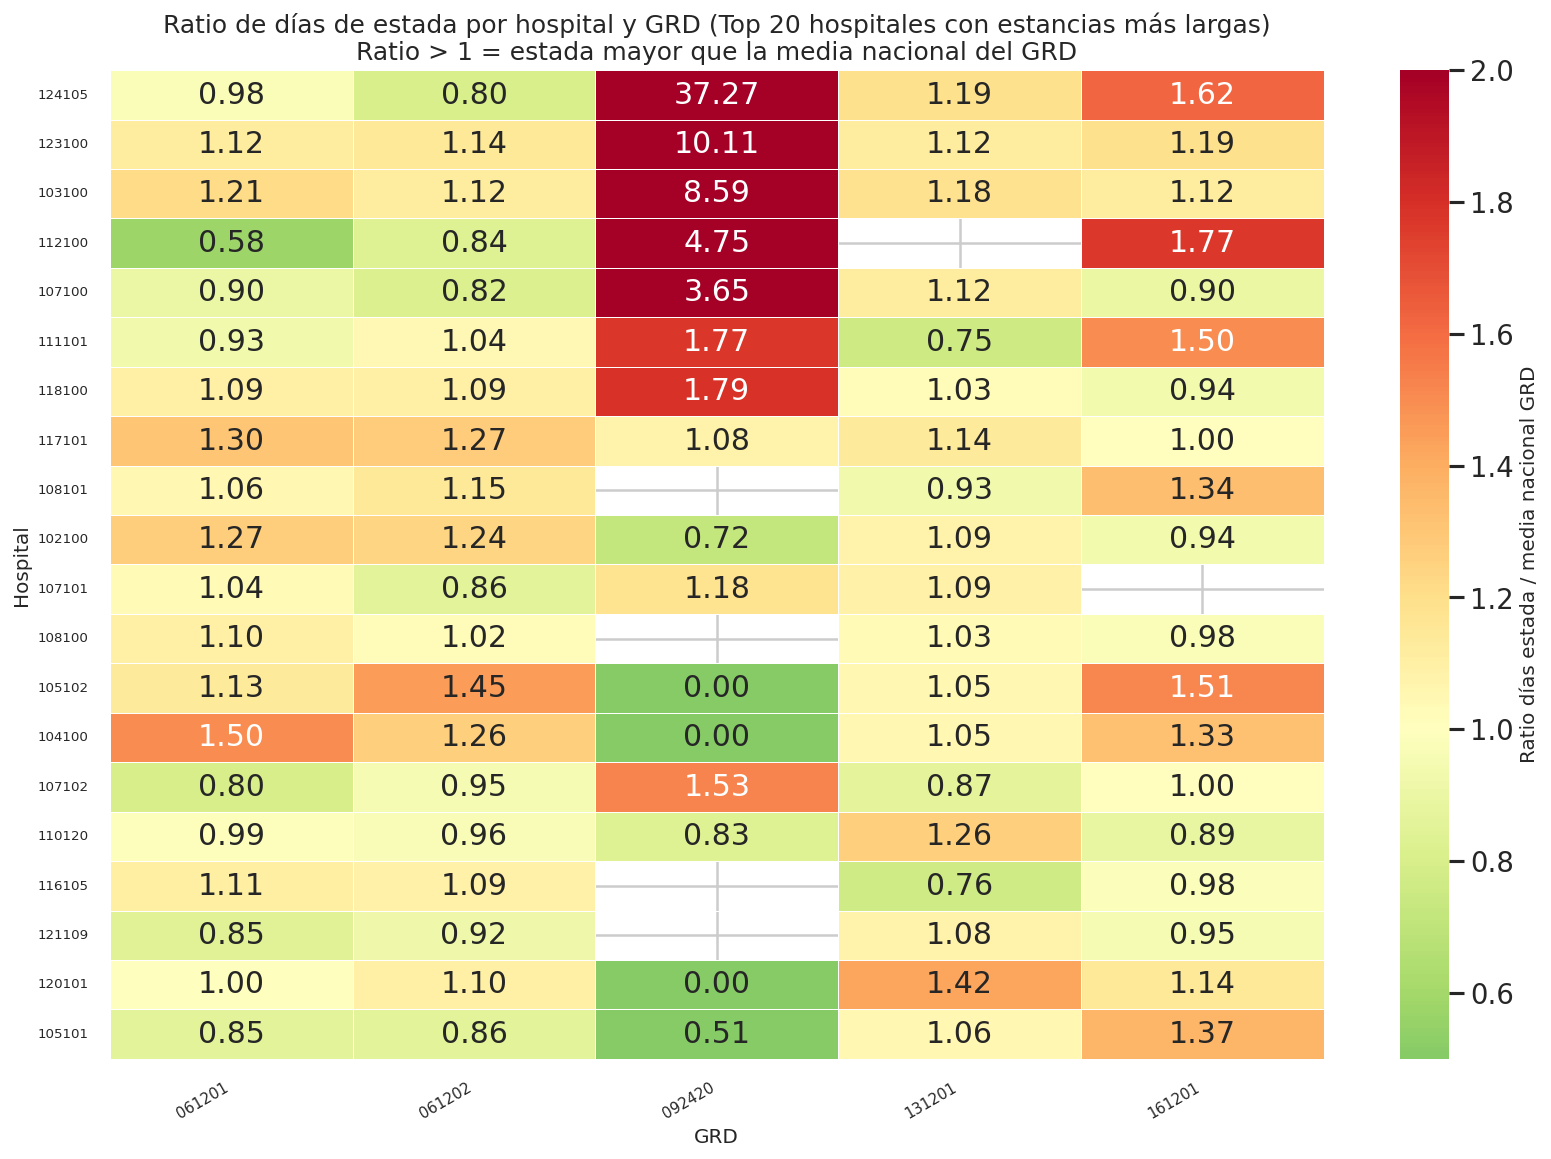

Hospitales con datos en >= 4 de los 5 GRDs: 40

Top 5 hospitales con mayor ratio promedio (estancias más largas):


GRD,061201,061202,092420,131201,161201,media_ratio
COD_HOSPITAL,,,,,,
124105,0.98,0.80,37.27,1.19,1.62,8.37
123100,1.12,1.14,10.11,1.12,1.19,2.94
103100,1.21,1.12,8.59,1.18,1.12,2.64
112100,0.58,0.84,4.75,NaN,1.77,1.98
107100,0.90,0.82,3.65,1.12,0.90,1.48



Top 5 hospitales con menor ratio promedio (estancias más eficientes):


GRD,061201,061202,092420,131201,161201,media_ratio
COD_HOSPITAL,,,,,,
126100,0.85,1.03,0.0,0.86,1.00,0.75
114103,0.95,0.75,0.0,1.00,0.83,0.70
116108,0.94,0.82,0.0,0.93,0.67,0.67
112101,0.90,0.92,0.0,0.83,0.41,0.61
133150,0.81,0.68,0.0,0.87,NaN,0.59


In [ ]:
# Variabilidad hospitalaria consistente a través de los 5 GRDs más frecuentes
top5_grds = df_clean["IR_29301_COD_GRD"].value_counts().head(5).index.tolist()

results_multi = []
for grd in top5_grds:
    df_g = df_clean[df_clean["IR_29301_COD_GRD"] == grd].copy()
    media_grd = df_g["dias_estada"].mean()
    if media_grd == 0:
        continue

    hosp_stats = (
        df_g.groupby("COD_HOSPITAL")
        .agg(n=("dias_estada", "size"), media=("dias_estada", "mean"))
        .reset_index()
    )
    hosp_stats = hosp_stats[hosp_stats["n"] >= 30]
    hosp_stats["ratio"] = hosp_stats["media"] / media_grd
    hosp_stats["GRD"] = str(grd)
    results_multi.append(hosp_stats)

df_multi = pd.concat(results_multi, ignore_index=True)

# Hospitales presentes en al menos 4 de los 5 GRDs
hosp_coverage = df_multi.groupby("COD_HOSPITAL")["GRD"].nunique()
hosp_consistent = hosp_coverage[hosp_coverage >= 4].index

df_pivot = df_multi[df_multi["COD_HOSPITAL"].isin(hosp_consistent)].pivot_table(
    index="COD_HOSPITAL", columns="GRD", values="ratio"
)
df_pivot["media_ratio"] = df_pivot.mean(axis=1)
df_pivot = df_pivot.sort_values("media_ratio", ascending=False)

# Plot: top 20 hospitales con mayor variación
top20_multi = df_pivot.head(20).drop(columns="media_ratio")

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    top20_multi,
    annot=True, fmt=".2f",
    cmap="RdYlGn_r",
    center=1.0, vmin=0.5, vmax=2.0,
    linewidths=0.4,
    cbar_kws={"label": "Ratio días estada / media nacional GRD"},
    ax=ax
)
ax.set_title(
    "Ratio de días de estada por hospital y GRD (Top 20 hospitales con estancias más largas)\n"
    "Ratio > 1 = estada mayor que la media nacional del GRD"
)
ax.set_xlabel("GRD")
ax.set_ylabel("Hospital")
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

print(f"Hospitales con datos en >= 4 de los 5 GRDs: {len(hosp_consistent)}")
print(f"\nTop 5 hospitales con mayor ratio promedio (estancias más largas):")
display(df_pivot.head(5).round(2))
print(f"\nTop 5 hospitales con menor ratio promedio (estancias más eficientes):")
display(df_pivot.tail(5).round(2))

**Conclusión 8.6 — Consistencia multi-GRD de la variabilidad:**  
Extender el análisis a los 5 GRDs más frecuentes permite evaluar si la variabilidad hospitalaria es un fenómeno robusto o específico de un diagnóstico. Un hospital con ratios sistemáticamente superiores a 1 en múltiples GRDs evidencia un patrón organizacional de estancias prolongadas, no explicable por el perfil clínico de un diagnóstico en particular. Por el contrario, hospitales con ratios cercanos a 1 de forma consistente sugieren una gestión más eficiente y estandarizada. Esta consistencia multi-GRD refuerza la hipótesis de que las diferencias observadas responden a factores institucionales, culturales o de recursos propios de cada establecimiento.

### 4.2. Estimacion estadistica

Esta seccion implementa, usando como base metodologica el notebook de estimacion estadistica:

- Seleccion de parametros de interes: promedios y proporciones.
- Calculo de estimadores puntuales con intervalos de confianza al 95%.
- Comparaciones entre grupos (ej.: servicio de salud, tipo de ingreso, sexo y otras agrupaciones disponibles).
- Tabla resumen de resultados con pruebas estadisticas y magnitud de diferencias.

> Nota: la comparacion "publico vs privado" depende de que exista una columna explicita de dependencia/tipo de establecimiento en los datos cargados.

Estimadores puntuales globales con IC95%


,Parametro,Tipo,Estimador_puntual,IC95_inferior,IC95_superior,Unidad,n_utilizado
0,Dias de estada,Promedio,6.124,6.099,6.149,dias,435820
1,Edad,Promedio,56.147,56.088,56.205,anios,435819
2,Peso GRD,Promedio,1.213,1.210,1.217,indice,435816
3,Mujeres,Proporcion,61.959,61.814,62.103,%,435774
4,Mortalidad intrahospitalaria,Proporcion,5.399,5.333,5.467,%,435820
5,Ingreso por urgencia,Proporcion,32.856,32.716,32.995,%,435820


Tabla resumen de comparaciones entre grupos


,Variable_grupo,Columna,Categorias_comparadas,n_total,Test_medias,p_valor_medias,Test_proporciones,p_valor_proporciones,Rango_media_dias,Rango_prop_muerte_pp,Categorias_fuera_media_global,Categorias_fuera_prop_global
0,Servicio de salud,SERVICIO_SALUD,29,435698,Kruskal-Wallis,0.0,Chi-cuadrado,0.0,2.8485,5.3146,24,24
1,Tipo de ingreso,TIPO_INGRESO,3,435790,Kruskal-Wallis,0.0,Chi-cuadrado,0.0,7.1360,14.6586,3,3
2,Sexo,SEXO,2,435774,Mann-Whitney U,0.0,Chi-cuadrado,0.0,2.8254,3.1594,2,2



Detalle del grupo con mayor evidencia de diferencias en medias: SERVICIO_SALUD


,SERVICIO_SALUD,n,media_dias_estada,IC95_media_inf,IC95_media_sup,prop_muerte,IC95_prop_inf,IC95_prop_sup,n_prop
0,VALDIVIA,15708,7.7210,7.5711,7.8709,4.1189,3.8192,4.4411,15708
1,IQUIQUE,6282,7.5172,7.2839,7.7504,8.0548,7.4071,8.7536,6282
2,DEL RELONCAVÍ,10919,7.4481,7.2870,7.6093,6.4750,6.0285,6.9520,10919
3,MAGALLANES,5334,6.8905,6.6634,7.1176,7.9678,7.2709,8.7251,5334
4,ATACAMA,7114,6.8790,6.6777,7.0803,5.8898,5.3661,6.4611,7114
5,VALPARAISO SAN ANTONIO,16918,6.8441,6.7123,6.9758,6.2655,5.9102,6.6407,16918
6,ARAUCANÍA NORTE,6532,6.6920,6.4934,6.8906,5.4654,4.9399,6.0433,6532
7,CONCEPCIÓN,21249,6.5719,6.4565,6.6872,6.4427,6.1204,6.7807,21249
8,ARAUCANÍA SUR,19761,6.5705,6.4518,6.6892,4.6303,4.3461,4.9322,19761
9,ARAUCO,4549,6.5603,6.3081,6.8126,4.2867,3.7356,4.9149,4549


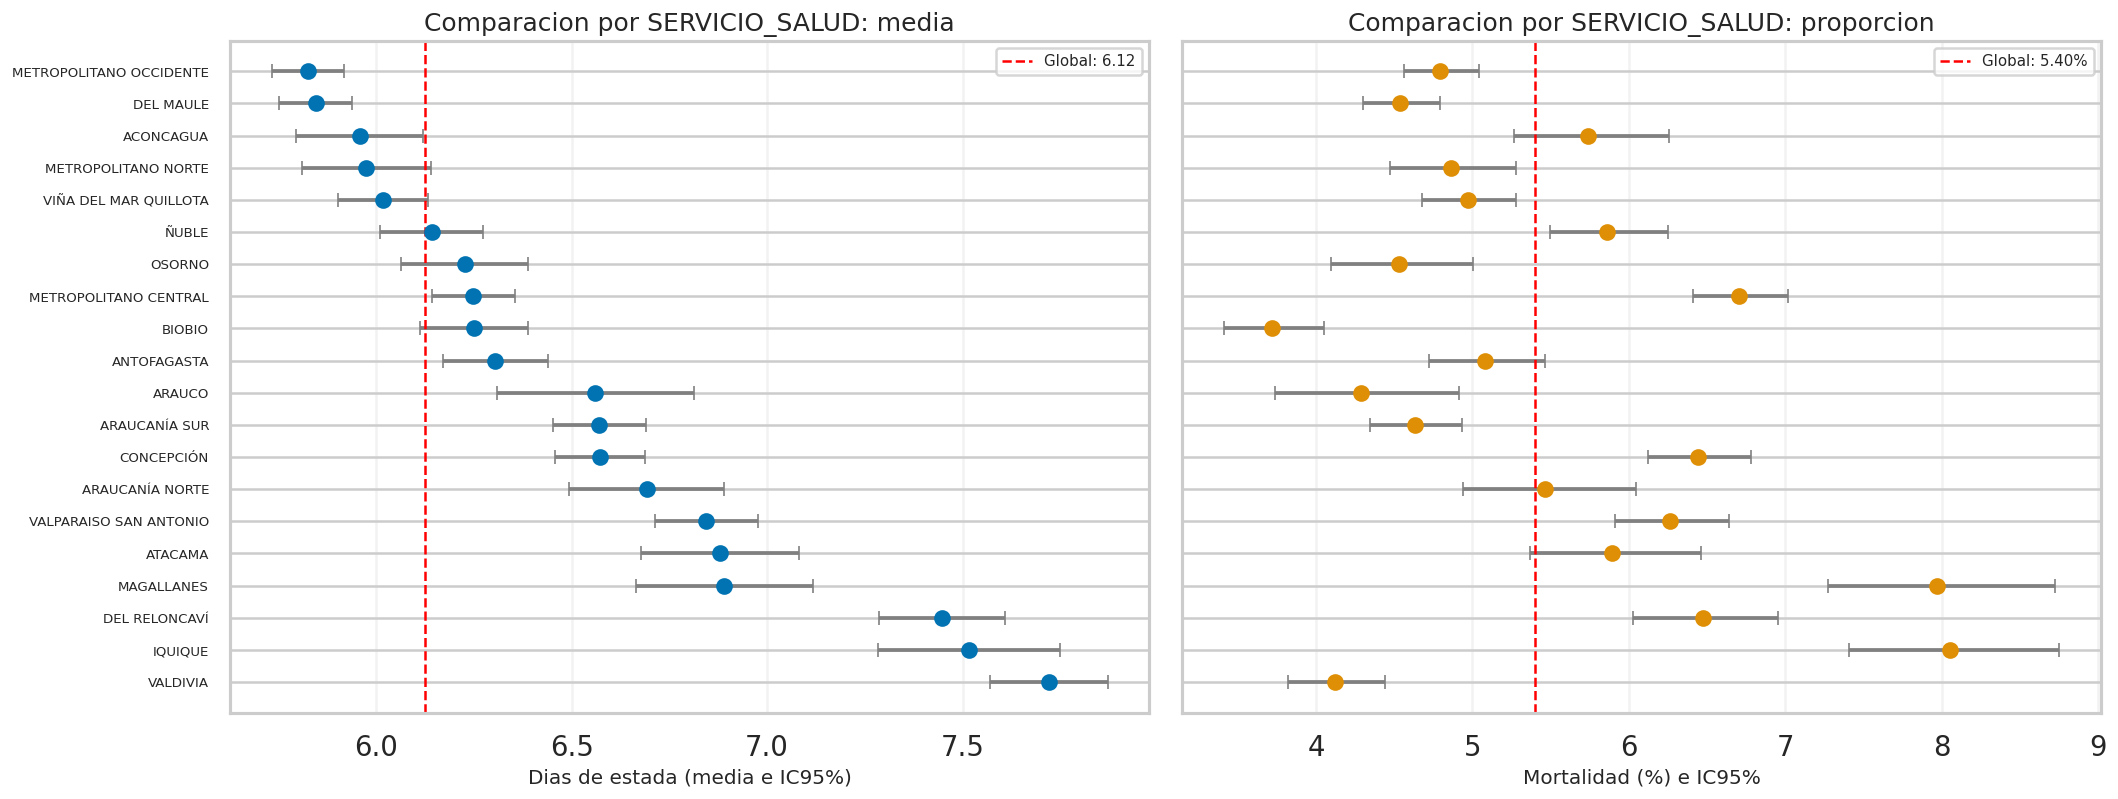

In [33]:
# ===============================
# 4.2 Estimacion estadistica
# ===============================

# Base para estimacion
if "df_clean" not in globals():
    raise NameError("No existe 'df_clean' en memoria. Ejecuta las celdas de carga y limpieza primero.")

df_est = df_clean.copy()
df_est["dias_estada"] = pd.to_numeric(df_est.get("dias_estada"), errors="coerce")
df_est = df_est[df_est["dias_estada"].notna()].copy()

if "edad" in df_est.columns:
    df_est["edad"] = pd.to_numeric(df_est["edad"], errors="coerce")

if "IR_29301_PESO" in df_est.columns:
    df_est["peso_grd"] = pd.to_numeric(
        df_est["IR_29301_PESO"].astype(str).str.replace(",", ".", regex=False),
        errors="coerce",
    )

if "TIPOALTA" in df_est.columns:
    df_est["muerte_intra"] = (
        df_est["TIPOALTA"].astype(str).str.upper().str.contains("FALLEC", na=False).astype(int)
    )
else:
    df_est["muerte_intra"] = np.nan

if "SEXO" in df_est.columns:
    sx = df_est["SEXO"].astype(str).str.strip().str.upper()
    female_mask = sx.isin(["F", "FEMENINO", "MUJER", "2"])
    male_mask = sx.isin(["M", "MASCULINO", "HOMBRE", "1"])
    df_est["es_mujer"] = np.where(female_mask, 1, np.where(male_mask, 0, np.nan))
else:
    df_est["es_mujer"] = np.nan

if "TIPO_INGRESO" in df_est.columns:
    df_est["ingreso_urgencia"] = (
        df_est["TIPO_INGRESO"].astype(str).str.upper().str.contains("URG", na=False).astype(int)
    )
else:
    df_est["ingreso_urgencia"] = np.nan


# --- Funciones auxiliares para IC ---
def calcular_ic_media(serie, confianza=0.95):
    s = pd.to_numeric(serie, errors="coerce").dropna()
    n = len(s)
    if n < 2:
        return np.nan, np.nan, np.nan, n

    media = float(s.mean())
    desv_est = float(s.std(ddof=1))
    error_estandar = desv_est / np.sqrt(n)
    valor_critico = stats.t.ppf((1 + confianza) / 2, n - 1)
    margen_error = valor_critico * error_estandar
    return media, media - margen_error, media + margen_error, n


def calcular_ic_proporcion_wilson(serie_binaria, confianza=0.95):
    s = pd.to_numeric(serie_binaria, errors="coerce").dropna()
    s = s[s.isin([0, 1])]
    n = len(s)
    if n == 0:
        return np.nan, np.nan, np.nan, n

    x = int(s.sum())
    p = x / n
    alpha = 1 - confianza
    z = stats.norm.ppf(1 - alpha / 2)

    denom = 1 + (z**2) / n
    center = (p + (z**2) / (2 * n)) / denom
    half = (z / denom) * np.sqrt((p * (1 - p) / n) + (z**2 / (4 * n**2)))

    return p, center - half, center + half, n


# --- Estimadores puntuales + IC95% ---
parametros = [
    ("Dias de estada", "Promedio", "dias_estada", "dias"),
    ("Edad", "Promedio", "edad", "anios"),
    ("Peso GRD", "Promedio", "peso_grd", "indice"),
    ("Mujeres", "Proporcion", "es_mujer", "%"),
    ("Mortalidad intrahospitalaria", "Proporcion", "muerte_intra", "%"),
    ("Ingreso por urgencia", "Proporcion", "ingreso_urgencia", "%"),
]

rows_parametros = []
for nombre, tipo, col, unidad in parametros:
    if col not in df_est.columns:
        continue

    if tipo == "Promedio":
        est, ic_inf, ic_sup, n = calcular_ic_media(df_est[col], confianza=0.95)
    else:
        est, ic_inf, ic_sup, n = calcular_ic_proporcion_wilson(df_est[col], confianza=0.95)
        est = est * 100 if pd.notna(est) else np.nan
        ic_inf = ic_inf * 100 if pd.notna(ic_inf) else np.nan
        ic_sup = ic_sup * 100 if pd.notna(ic_sup) else np.nan

    rows_parametros.append(
        {
            "Parametro": nombre,
            "Tipo": tipo,
            "Estimador_puntual": est,
            "IC95_inferior": ic_inf,
            "IC95_superior": ic_sup,
            "Unidad": unidad,
            "n_utilizado": int(n),
        }
    )

estimadores_puntuales = pd.DataFrame(rows_parametros)
print("Estimadores puntuales globales con IC95%")
display(estimadores_puntuales.round(3))


# --- Comparaciones entre grupos ---
MIN_N_GRUPO = 100
candidatos_grupo = [
    ("TIPO_ESTABLECIMIENTO", "Tipo de establecimiento"),
    ("DEPENDENCIA", "Dependencia administrativa"),
    ("REGION", "Region"),
    ("SERVICIO_SALUD", "Servicio de salud"),
    ("TIPO_INGRESO", "Tipo de ingreso"),
    ("SEXO", "Sexo"),
]

# Referencias globales para evaluacion de grupos fuera de norma
media_global, _, _, _ = calcular_ic_media(df_est["dias_estada"], confianza=0.95)
prop_global, _, _, _ = calcular_ic_proporcion_wilson(df_est["muerte_intra"], confianza=0.95)

comparaciones = []
tablas_detalle = {}

for col, etiqueta in candidatos_grupo:
    if col not in df_est.columns:
        continue

    sub = df_est[[col, "dias_estada", "muerte_intra"]].copy()
    sub[col] = sub[col].astype(str).str.strip()
    sub = sub[(sub[col] != "") & (sub[col].str.upper() != "NAN")]

    conteos = sub[col].value_counts()
    categorias_validas = conteos[conteos >= MIN_N_GRUPO].index
    sub = sub[sub[col].isin(categorias_validas)]

    if sub[col].nunique() < 2:
        continue

    # Test para medias
    grupos_media = [g["dias_estada"].dropna().values for _, g in sub.groupby(col)]
    if len(grupos_media) == 2:
        _, p_media = stats.mannwhitneyu(grupos_media[0], grupos_media[1], alternative="two-sided")
        test_media = "Mann-Whitney U"
    else:
        _, p_media = stats.kruskal(*grupos_media)
        test_media = "Kruskal-Wallis"

    # Test para proporciones
    p_prop = np.nan
    test_prop = "No aplica"
    tabla_chi = pd.crosstab(sub[col], sub["muerte_intra"])
    if tabla_chi.shape[0] >= 2 and tabla_chi.shape[1] >= 2 and tabla_chi.to_numpy().sum() > 0:
        _, p_prop, _, _ = stats.chi2_contingency(tabla_chi)
        test_prop = "Chi-cuadrado"

    # Detalle por categoria con IC95%
    detalle_rows = []
    for categoria, g in sub.groupby(col):
        media_cat, icm_inf, icm_sup, n_media = calcular_ic_media(g["dias_estada"], confianza=0.95)
        prop_cat, icp_inf, icp_sup, n_prop = calcular_ic_proporcion_wilson(g["muerte_intra"], confianza=0.95)

        detalle_rows.append(
            {
                col: categoria,
                "n": int(len(g)),
                "media_dias_estada": media_cat,
                "IC95_media_inf": icm_inf,
                "IC95_media_sup": icm_sup,
                "prop_muerte": prop_cat,
                "IC95_prop_inf": icp_inf,
                "IC95_prop_sup": icp_sup,
                "n_prop": int(n_prop),
            }
        )

    detalle = pd.DataFrame(detalle_rows).sort_values("media_dias_estada", ascending=False).reset_index(drop=True)

    # Conteo de categorias cuyos IC no contienen la referencia global
    media_fuera_global = int(
        ((detalle["IC95_media_inf"] > media_global) | (detalle["IC95_media_sup"] < media_global)).sum()
    )
    prop_fuera_global = int(
        ((detalle["IC95_prop_inf"] > prop_global) | (detalle["IC95_prop_sup"] < prop_global)).sum()
    )

    comparaciones.append(
        {
            "Variable_grupo": etiqueta,
            "Columna": col,
            "Categorias_comparadas": int(detalle.shape[0]),
            "n_total": int(detalle["n"].sum()),
            "Test_medias": test_media,
            "p_valor_medias": float(p_media),
            "Test_proporciones": test_prop,
            "p_valor_proporciones": float(p_prop) if pd.notna(p_prop) else np.nan,
            "Rango_media_dias": float(detalle["media_dias_estada"].max() - detalle["media_dias_estada"].min()),
            "Rango_prop_muerte_pp": float((detalle["prop_muerte"].max() - detalle["prop_muerte"].min()) * 100),
            "Categorias_fuera_media_global": media_fuera_global,
            "Categorias_fuera_prop_global": prop_fuera_global,
        }
    )

    # Formato para mostrar detalle en porcentaje
    detalle_show = detalle.copy()
    for c in ["prop_muerte", "IC95_prop_inf", "IC95_prop_sup"]:
        detalle_show[c] = detalle_show[c] * 100
    tablas_detalle[col] = detalle_show

resumen_comparaciones = pd.DataFrame(comparaciones)

if resumen_comparaciones.empty:
    print("No hay variables de agrupacion con al menos dos categorias y n suficiente para comparar.")
else:
    resumen_comparaciones = resumen_comparaciones.sort_values("p_valor_medias")
    print("Tabla resumen de comparaciones entre grupos")
    display(resumen_comparaciones.round(4))

    col_principal = resumen_comparaciones.iloc[0]["Columna"]
    print(f"\nDetalle del grupo con mayor evidencia de diferencias en medias: {col_principal}")
    display(tablas_detalle[col_principal].round(4))

    # Visualizacion comparativa de IC95% para el grupo principal
    df_plot = tablas_detalle[col_principal].copy()
    if df_plot.shape[0] > 20:
        df_plot = df_plot.head(20).copy()

    y_pos = np.arange(len(df_plot))
    labels = df_plot[col_principal].astype(str).tolist()

    fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(df_plot) * 0.35)), sharey=True)

    media_err = np.vstack([
        (df_plot["media_dias_estada"] - df_plot["IC95_media_inf"]).to_numpy(),
        (df_plot["IC95_media_sup"] - df_plot["media_dias_estada"]).to_numpy(),
    ])
    axes[0].errorbar(
        df_plot["media_dias_estada"],
        y_pos,
        xerr=media_err,
        fmt="o",
        capsize=4,
        color=COLORES[0],
        ecolor="gray",
    )
    axes[0].axvline(media_global, linestyle="--", color="red", linewidth=1.5, label=f"Global: {media_global:.2f}")
    axes[0].set_xlabel("Dias de estada (media e IC95%)")
    axes[0].set_title(f"Comparacion por {col_principal}: media")
    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels(labels, fontsize=8)
    axes[0].grid(axis="x", alpha=0.25)
    axes[0].legend(fontsize=9)

    prop_global_pct = prop_global * 100
    prop_err = np.vstack([
        (df_plot["prop_muerte"] - df_plot["IC95_prop_inf"]).to_numpy(),
        (df_plot["IC95_prop_sup"] - df_plot["prop_muerte"]).to_numpy(),
    ])
    axes[1].errorbar(
        df_plot["prop_muerte"],
        y_pos,
        xerr=prop_err,
        fmt="o",
        capsize=4,
        color=COLORES[1],
        ecolor="gray",
    )
    axes[1].axvline(prop_global_pct, linestyle="--", color="red", linewidth=1.5, label=f"Global: {prop_global_pct:.2f}%")
    axes[1].set_xlabel("Mortalidad (%) e IC95%")
    axes[1].set_title(f"Comparacion por {col_principal}: proporcion")
    axes[1].grid(axis="x", alpha=0.25)
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.show()

## 9. Conclusiones Generales

### Hallazgos principales

1. **Impacto pandémico y recuperación:** La pandemia de COVID-19 causó una reducción drástica en los egresos hospitalarios durante 2020. La recuperación fue progresiva y para 2023-2024 el sistema ya superó los niveles pre-pandemia, sugiriendo tanto resolución de demanda acumulada como crecimiento orgánico.

2. **Perfil demográfico:** El sistema público hospitalario chileno atiende predominantemente a mujeres en edad reproductiva (carga obstétrica) y adultos mayores de ambos sexos (carga crónica). La población beneficiaria es mayoritariamente FONASA A y B (tramos de mayor vulnerabilidad socioeconómica). La presencia de pueblos originarios, aunque minoritaria, es relevante para políticas de salud intercultural.

3. **Perfil clínico:** Las causas de hospitalización más frecuentes son obstétricas, quirúrgicas abdominales (colecistitis), oftalmológicas (cataratas) y oncológicas. La coexistencia de patología aguda y crónica refleja la transición epidemiológica del país.

4. **Estancia hospitalaria:** La distribución de días de estada es altamente asimétrica, con una mediana corta (~2 días) pero una cola larga de estancias prolongadas. La severidad del episodio es el principal determinante clínico de la duración de la estancia.

5. **Variabilidad hospitalaria comprobada (GRD focal):** Se demostró estadísticamente (Kruskal-Wallis, p < 0.05) que existen diferencias significativas en los días de estada entre hospitales para pacientes con el mismo GRD. Los intervalos de confianza al 95% visualizan esta heterogeneidad: varios hospitales tienen medias que no se solapan con la media global.

6. **Pares de hospitales significativamente distintos (Dunn):** El análisis post-hoc de Dunn con corrección de Bonferroni identifica los pares específicos de hospitales con diferencias estadísticamente significativas, revelando la topología de la variabilidad: no todos los hospitales difieren entre sí, pero existen establecimientos con prácticas sistemáticamente distintas al resto de la red.

7. **Variabilidad consistente en múltiples GRDs:** Los ratios de estada por hospital se mantienen relativamente estables a través de los 5 GRDs más frecuentes, lo que indica que la variabilidad es un fenómeno institucional, no diagnóstico-específico. Hospitales con ratios consistentemente altos o bajos exhiben patrones organizacionales y de práctica clínica propios.

8. **Estacionalidad predecible:** Los egresos siguen un patrón estacional consistente (pico invernal, valle estival), lo que permite una planificación anticipada de recursos.

---

### Limitaciones

- Los datos GRD clasifican por diagnóstico y severidad, pero no capturan todas las variables relevantes (comorbilidades detalladas, estado funcional, preferencias del paciente).
- La calidad del registro varía entre establecimientos, lo que puede introducir sesgos de clasificación.
- El análisis es descriptivo e inferencial básico; no establece causalidad entre hospital y resultado.
- No se dispone de variables de resultado clínico final como reingresos, complicaciones postoperatorias o satisfacción del paciente.
- Los GRDs con pocos casos por hospital producen intervalos de confianza amplios, limitando la precisión de las comparaciones.

---

### Líneas futuras de investigación

- **Modelos multinivel (mixed-effects):** Aislar el efecto hospital ajustando simultáneamente por severidad, edad, sexo y peso GRD. El coeficiente del nivel hospital cuantifica la variabilidad "inexplicada" por el paciente.
- **Análisis de eficiencia:** Comparar el peso GRD producido versus los recursos consumidos (camas-día) para identificar establecimientos con alta o baja eficiencia técnica.
- **Estudio longitudinal pandémico:** Evaluar el impacto del COVID-19 en las listas de espera quirúrgicas y la composición del case-mix por año.
- **Análisis por especialidad:** Identificar áreas clínicas con mayor variabilidad injustificada (ej.: cirugía, traumatología, medicina interna).
- **Incorporación de datos de resultados:** Reingresos a 30 días, mortalidad ajustada por riesgo, complicaciones para una evaluación más completa de la calidad asistencial.
- **Pertinencia cultural:** Analizar diferencias en estancia y procedimientos según etnia del paciente, controlando por severidad y diagnóstico.

## 10. Análisis Oncológico Específico (4 tipos de cáncer)

Este bloque extiende el análisis principal con foco en cáncer de mama, colorrectal, cuello uterino y pulmón.
Las celdas asumen que `df_clean` ya fue construido en la etapa de limpieza.

### A. Filtrado por tipos de cáncer seleccionados

In [ ]:
# Códigos CIE-10 de los 4 tipos de cáncer del estudio
CANCER_MAP = {
    "C50": "Mama",
    "C18": "Colorrectal",
    "C19": "Colorrectal",
    "C20": "Colorrectal",
    "C53": "Cuello uterino",
    "C34": "Pulmón",
}

df_clean["diag_3"] = df_clean["DIAGNOSTICO1"].astype(str).str[:3].str.upper()
df_clean["tipo_cancer"] = df_clean["diag_3"].map(CANCER_MAP)

df_onco = df_clean[df_clean["tipo_cancer"].notna()].copy()

# Variable de mortalidad intrahospitalaria
df_onco["muerte_intra"] = (
    df_onco["TIPOALTA"].astype(str).str.upper().str.contains("FALLEC", na=False).astype(int)
)

# Identificador de paciente robusto (si no existe, usa un fallback por fila)
if "CIP_ENCRIPTADO" in df_onco.columns:
    id_col = "CIP_ENCRIPTADO"
elif "ID_BENEFICIARIO" in df_onco.columns:
    id_col = "ID_BENEFICIARIO"
else:
    id_col = "ID_FILA_TEMP"
    df_onco[id_col] = df_onco.index.astype(str)
    print("Advertencia: no se encontró identificador de paciente; se usa un identificador temporal por fila.")

print(f"Identificador de paciente usado: '{id_col}'")
print(f"Total egresos oncológicos seleccionados: {len(df_onco):,}")
print(f"Pacientes únicos en estos egresos:       {df_onco[id_col].nunique():,}")
print()
print("Distribución por tipo de cáncer (egresos):")
print(df_onco["tipo_cancer"].value_counts().to_string())
print()
print("Distribución por tipo de cáncer (pacientes únicos):")
print(df_onco.groupby("tipo_cancer")[id_col].nunique().sort_values(ascending=False).to_string())

Advertencia: no se encontró identificador de paciente; se usa un identificador temporal por fila.
Identificador de paciente usado: 'ID_FILA_TEMP'
Total egresos oncológicos seleccionados: 71,255
Pacientes únicos en estos egresos:       71,255

Distribución por tipo de cáncer (egresos):
tipo_cancer
Mama              31070
Colorrectal       25549
Pulmón             7771
Cuello uterino     6865

Distribución por tipo de cáncer (pacientes únicos):
tipo_cancer
Mama              31070
Colorrectal       25549
Pulmón             7771
Cuello uterino     6865


### B1. Pacientes únicos por tipo de cáncer, sexo y grupo etario

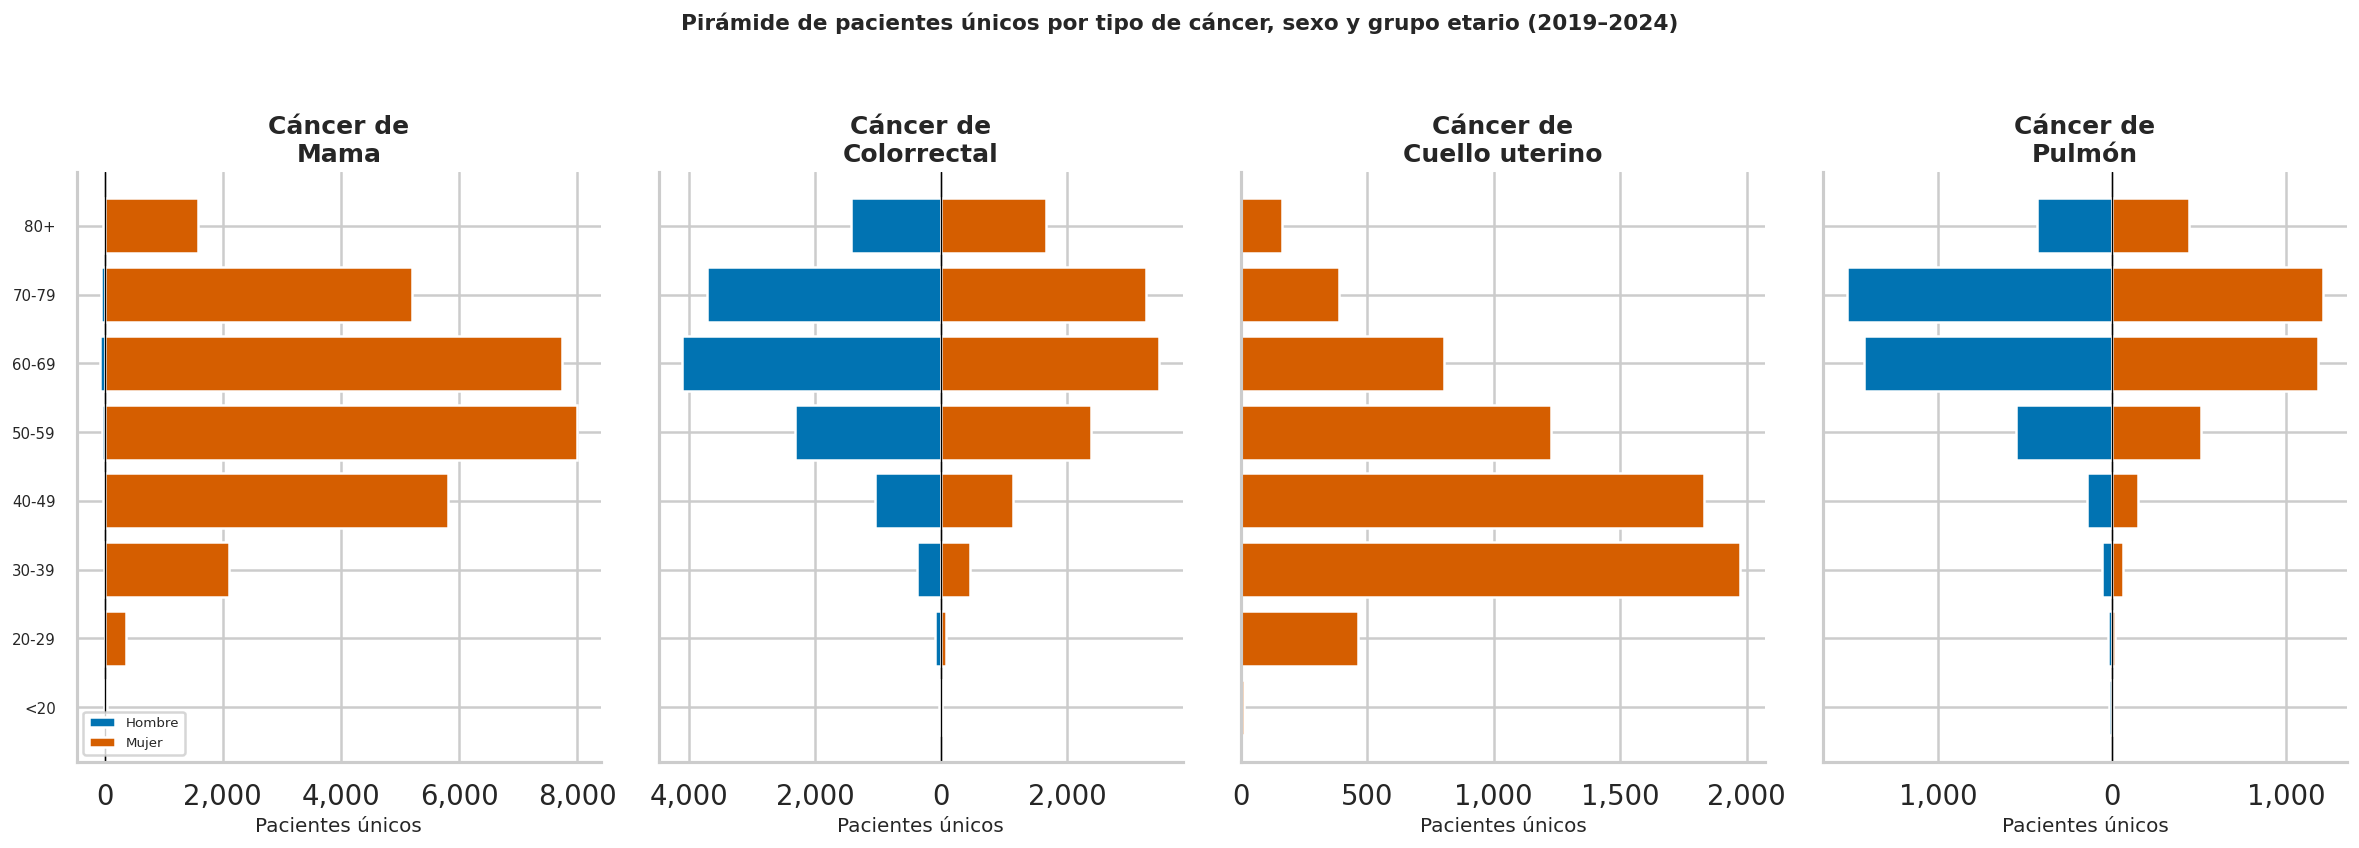

In [ ]:
# Usamos nunique sobre el identificador, agrupado por tipo_cancer + grupo_edad + SEXO
# para representar personas, no ingresos.

df_onco["grupo_edad"] = pd.cut(
    df_onco["edad"],
    bins=[0, 20, 30, 40, 50, 60, 70, 80, 120],
    labels=["<20", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"],
    right=False,
)

tipos = ["Mama", "Colorrectal", "Cuello uterino", "Pulmón"]
fig, axes = plt.subplots(1, 4, figsize=(20, 7), sharey=True)

for ax, tipo in zip(axes, tipos):
    sub = df_onco[df_onco["tipo_cancer"] == tipo].copy()
    sub = sub[sub["SEXO"].isin(["HOMBRE", "MUJER"])]

    pyr = (
        sub.groupby(["grupo_edad", "SEXO"], observed=True)[id_col]
        .nunique()
        .unstack(fill_value=0)
    )
    y_pos = range(len(pyr))

    if "HOMBRE" in pyr.columns:
        ax.barh(list(y_pos), [-v for v in pyr["HOMBRE"]], color=COLORES[0], label="Hombre", height=0.8, edgecolor="white")
    if "MUJER" in pyr.columns:
        ax.barh(list(y_pos), list(pyr["MUJER"]), color=COLORES[3], label="Mujer", height=0.8, edgecolor="white")

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(pyr.index.astype(str), fontsize=9)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Cáncer de\n{tipo}", fontweight="bold")
    ax.set_xlabel("Pacientes únicos")
    if ax == axes[0]:
        ax.legend(fontsize=8, loc="lower left")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{abs(int(x)):,}"))

fig.suptitle(
    "Pirámide de pacientes únicos por tipo de cáncer, sexo y grupo etario (2019–2024)",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
sns.despine()
plt.tight_layout()
plt.show()

### B2. Diversidad de procedimientos por tipo de cáncer

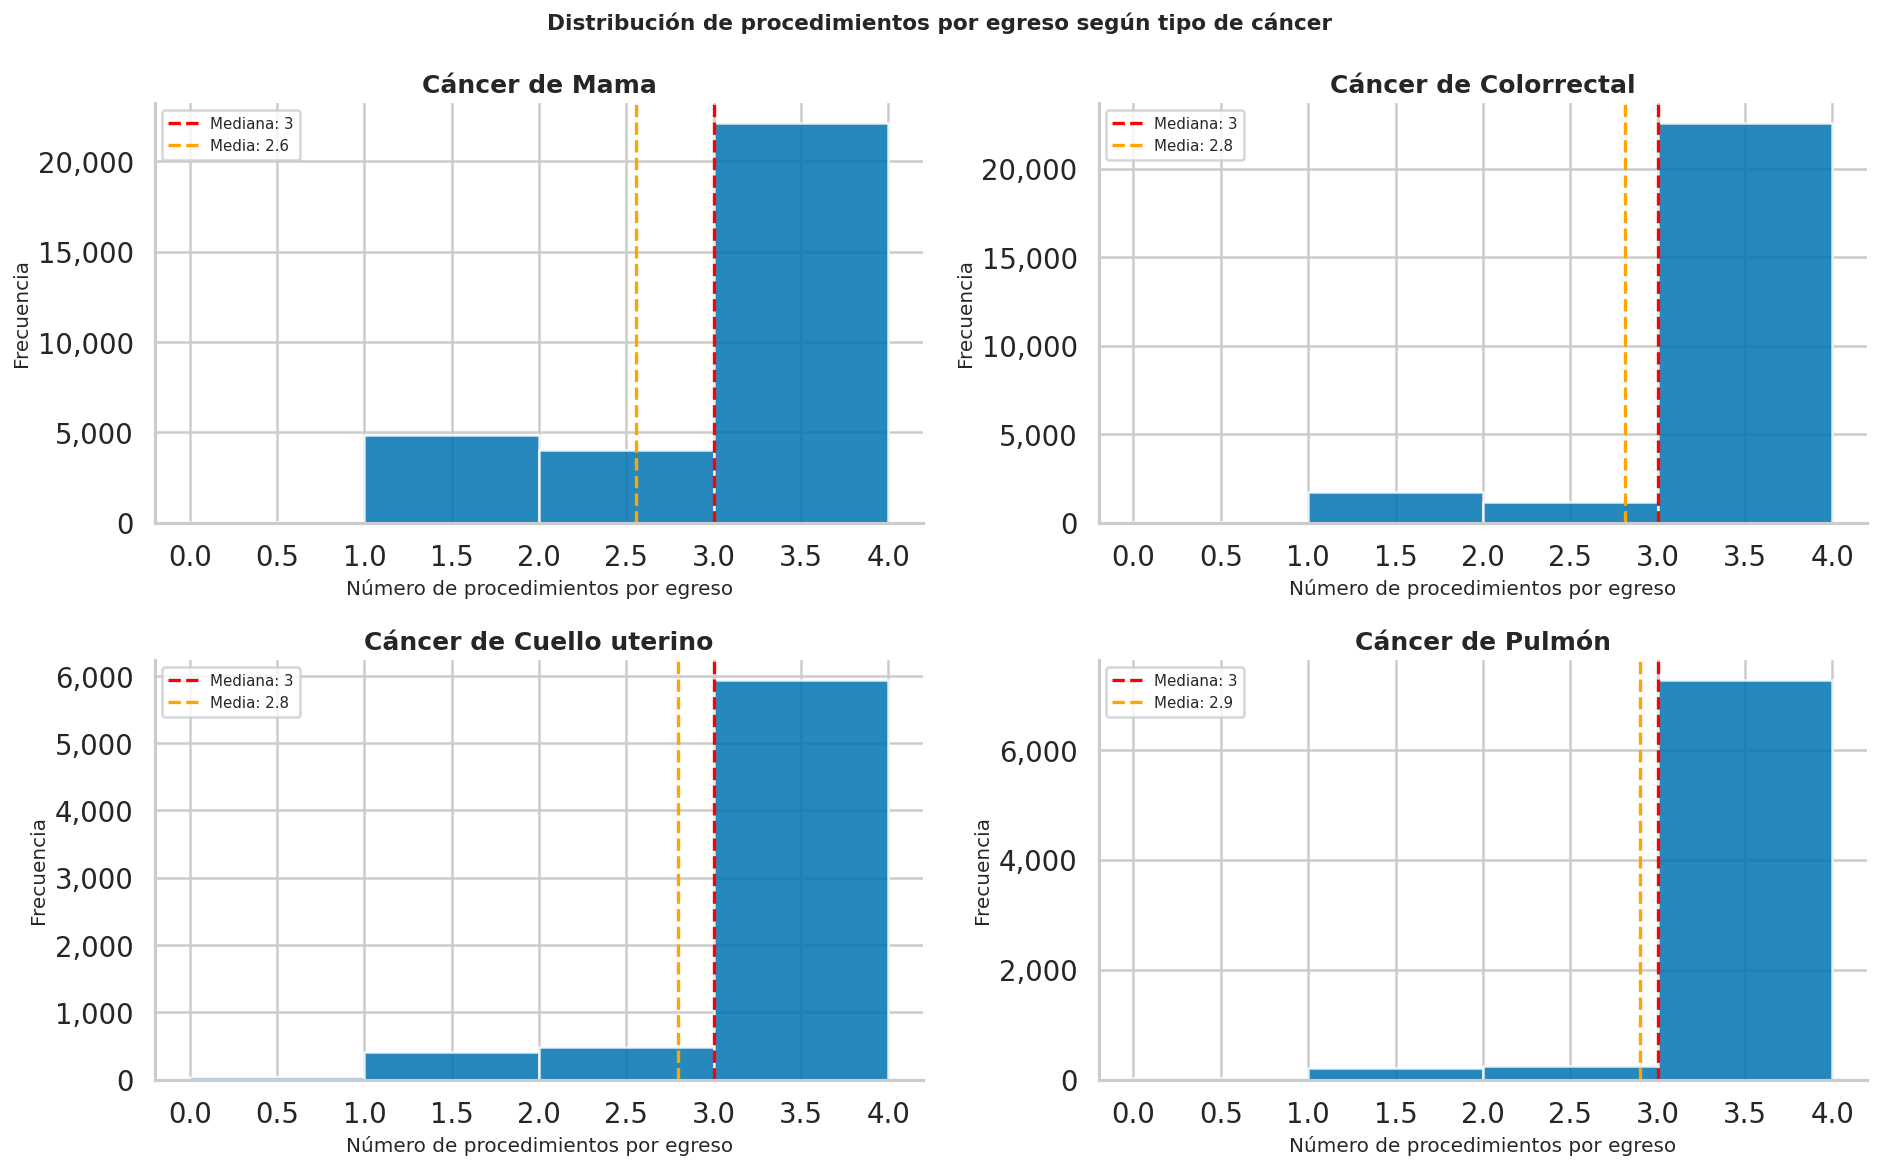


Estadísticas de procedimientos por tipo de cáncer:


,count,mean,std,min,25%,50%,75%,max
tipo_cancer,,,,,,,,
Colorrectal,25549.0,2.81,0.55,0.0,3.0,3.0,3.0,3.0
Cuello uterino,6865.0,2.80,0.55,0.0,3.0,3.0,3.0,3.0
Mama,31070.0,2.55,0.75,0.0,2.0,3.0,3.0,3.0
Pulmón,7771.0,2.90,0.41,0.0,3.0,3.0,3.0,3.0


In [ ]:
# Distribución de n_procedimientos por tipo de cáncer sobre egresos individuales.

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, tipo in zip(axes, tipos):
    sub = df_onco[df_onco["tipo_cancer"] == tipo]["n_procedimientos"].dropna()
    mediana = sub.median()
    media = sub.mean()

    ax.hist(sub, bins=range(0, int(sub.max()) + 2), color=COLORES[0], edgecolor="white", alpha=0.85)
    ax.axvline(mediana, color="red", linestyle="--", linewidth=2, label=f"Mediana: {mediana:.0f}")
    ax.axvline(media, color="orange", linestyle="--", linewidth=2, label=f"Media: {media:.1f}")
    ax.set_title(f"Cáncer de {tipo}", fontweight="bold")
    ax.set_xlabel("Número de procedimientos por egreso")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle("Distribución de procedimientos por egreso según tipo de cáncer", fontsize=13, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()

print("\nEstadísticas de procedimientos por tipo de cáncer:")
display(df_onco.groupby("tipo_cancer")["n_procedimientos"].describe().round(2))

### B3. Procedimientos CIE-9 más frecuentes por tipo de cáncer

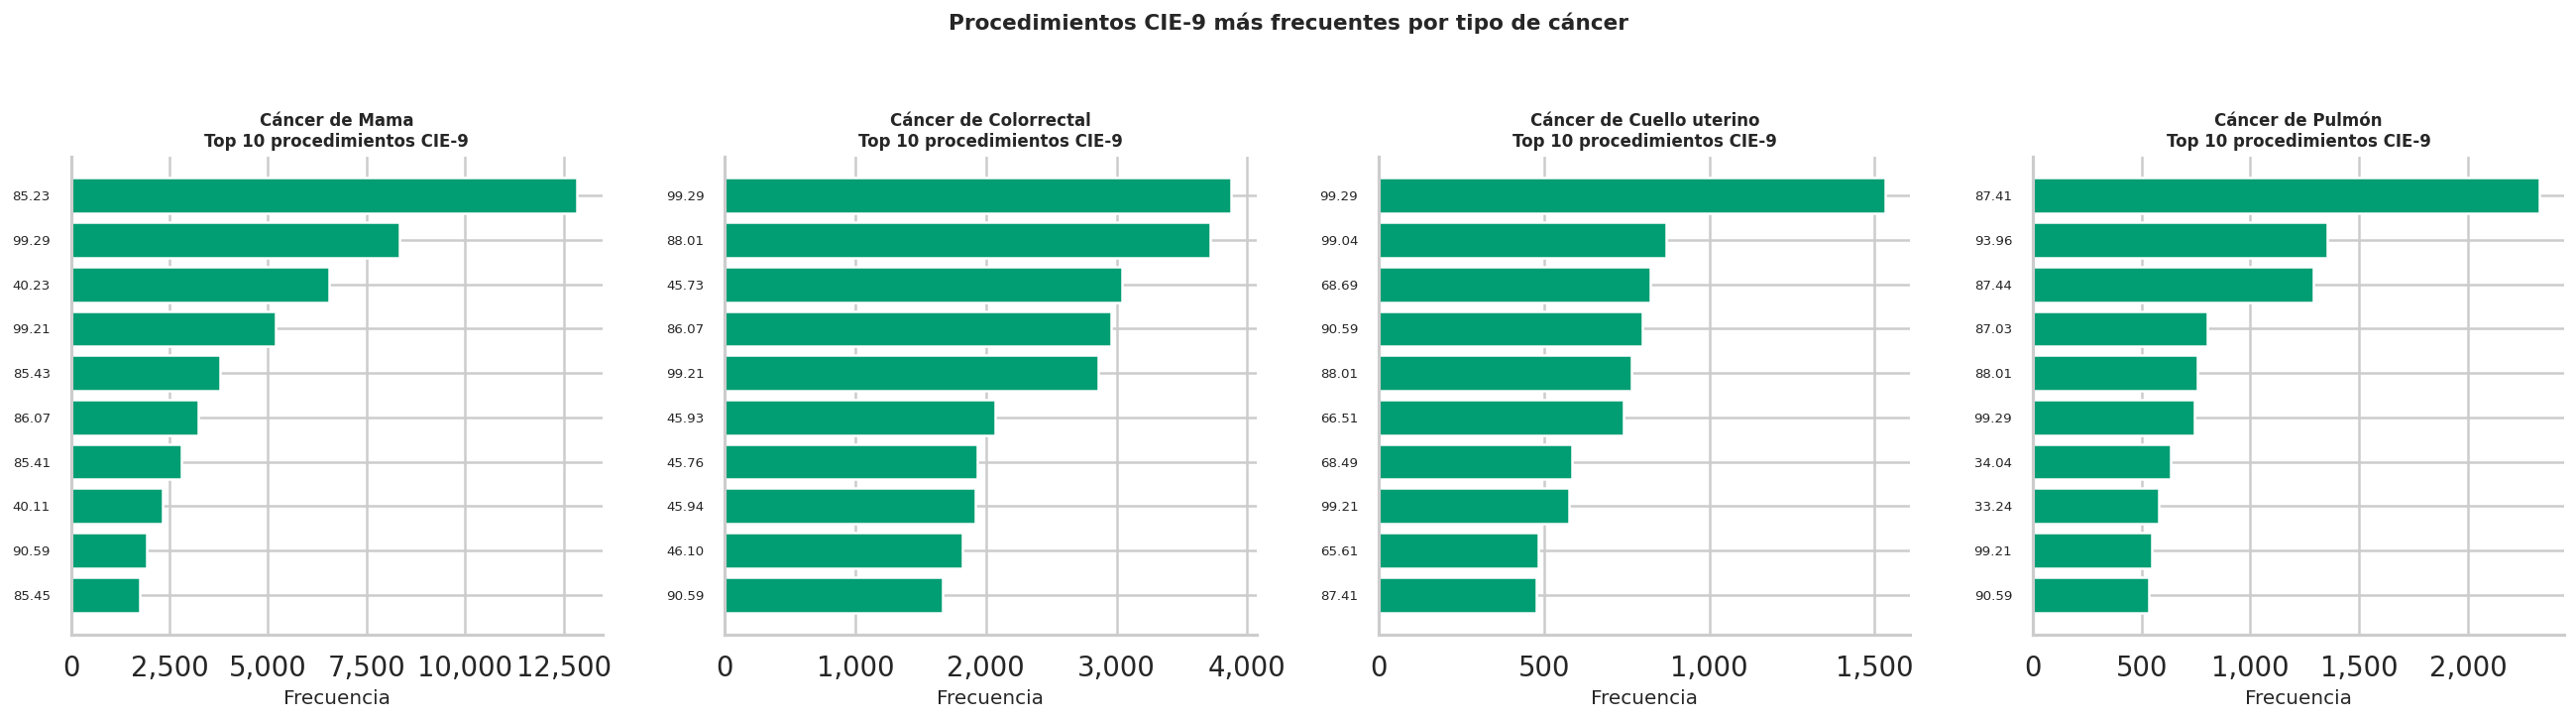

In [ ]:
# Top procedimientos CIE-9 por tipo de cáncer (sobre egresos)
proc_cols = [c for c in df_onco.columns if c.startswith("PROCEDIMIENTO")]

TOP_N = 10
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

for ax, tipo in zip(axes, tipos):
    sub = df_onco[df_onco["tipo_cancer"] == tipo]
    all_procs = (
        sub[proc_cols]
        .stack()
        .reset_index(drop=True)
        .astype(str)
        .str.strip()
    )
    all_procs = all_procs[(all_procs != "nan") & (all_procs != "")]
    top = all_procs.value_counts().head(TOP_N)

    ax.barh(top.index[::-1], top.values[::-1], color=COLORES[2], edgecolor="white")
    ax.set_title(f"Cáncer de {tipo}\nTop {TOP_N} procedimientos CIE-9", fontweight="bold", fontsize=10)
    ax.set_xlabel("Frecuencia")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.tick_params(axis="y", labelsize=8)

sns.despine()
plt.suptitle("Procedimientos CIE-9 más frecuentes por tipo de cáncer", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### C1. Intensidad de tratamiento por hospital: clasificación en terciles

In [ ]:
# Para cada tipo de cáncer, calculamos el promedio de procedimientos
# por hospital y lo clasificamos en grupos de intensidad.

MIN_PACIENTES = 30

intensidad_frames = []
for tipo in tipos:
    sub = df_onco[df_onco["tipo_cancer"] == tipo].copy()
    hosp_stats = (
        sub.groupby("COD_HOSPITAL")
        .agg(
            n_pacientes=(id_col, "nunique"),
            media_proc=("n_procedimientos", "mean"),
            mediana_proc=("n_procedimientos", "median"),
            mortalidad=("muerte_intra", "mean"),
            mediana_estada=("dias_estada", "median"),
        )
        .reset_index()
    )
    hosp_stats = hosp_stats[hosp_stats["n_pacientes"] >= MIN_PACIENTES].copy()

    n_unique = hosp_stats["media_proc"].nunique()
    if n_unique < 2:
        hosp_stats["intensidad"] = "Media"
    else:
        n_q = min(3, n_unique)
        labels_map = {2: ["Baja", "Alta"], 3: ["Baja", "Media", "Alta"]}
        hosp_stats["intensidad"] = pd.qcut(
            hosp_stats["media_proc"],
            q=n_q,
            labels=labels_map[n_q],
            duplicates="drop",
        )

    hosp_stats["intensidad"] = pd.Categorical(
        hosp_stats["intensidad"].astype(str),
        categories=["Baja", "Media", "Alta"],
        ordered=True,
    )
    hosp_stats["tipo_cancer"] = tipo
    intensidad_frames.append(hosp_stats)

df_intensidad = pd.concat(intensidad_frames, ignore_index=True)

print("Hospitales clasificados por intensidad de procedimientos:")
print(df_intensidad.groupby(["tipo_cancer", "intensidad"], observed=True).size().to_string())
print()
print("Promedio de procedimientos por grupo de intensidad:")
display(df_intensidad.groupby(["tipo_cancer", "intensidad"], observed=True)["media_proc"].mean().round(2).unstack())

Hospitales clasificados por intensidad de procedimientos:
tipo_cancer     intensidad
Colorrectal     Baja          19
                Media         18
                Alta          19
Cuello uterino  Baja          13
                Media         13
                Alta          13
Mama            Baja          15
                Media         14
                Alta          15
Pulmón          Baja          16
                Media         15
                Alta          15

Promedio de procedimientos por grupo de intensidad:


intensidad,Baja,Media,Alta
tipo_cancer,,,
Colorrectal,2.69,2.90,2.99
Cuello uterino,2.46,2.81,2.94
Mama,2.10,2.75,2.95
Pulmón,2.78,2.95,3.00


### C2. Mortalidad por grupo de intensidad de tratamiento

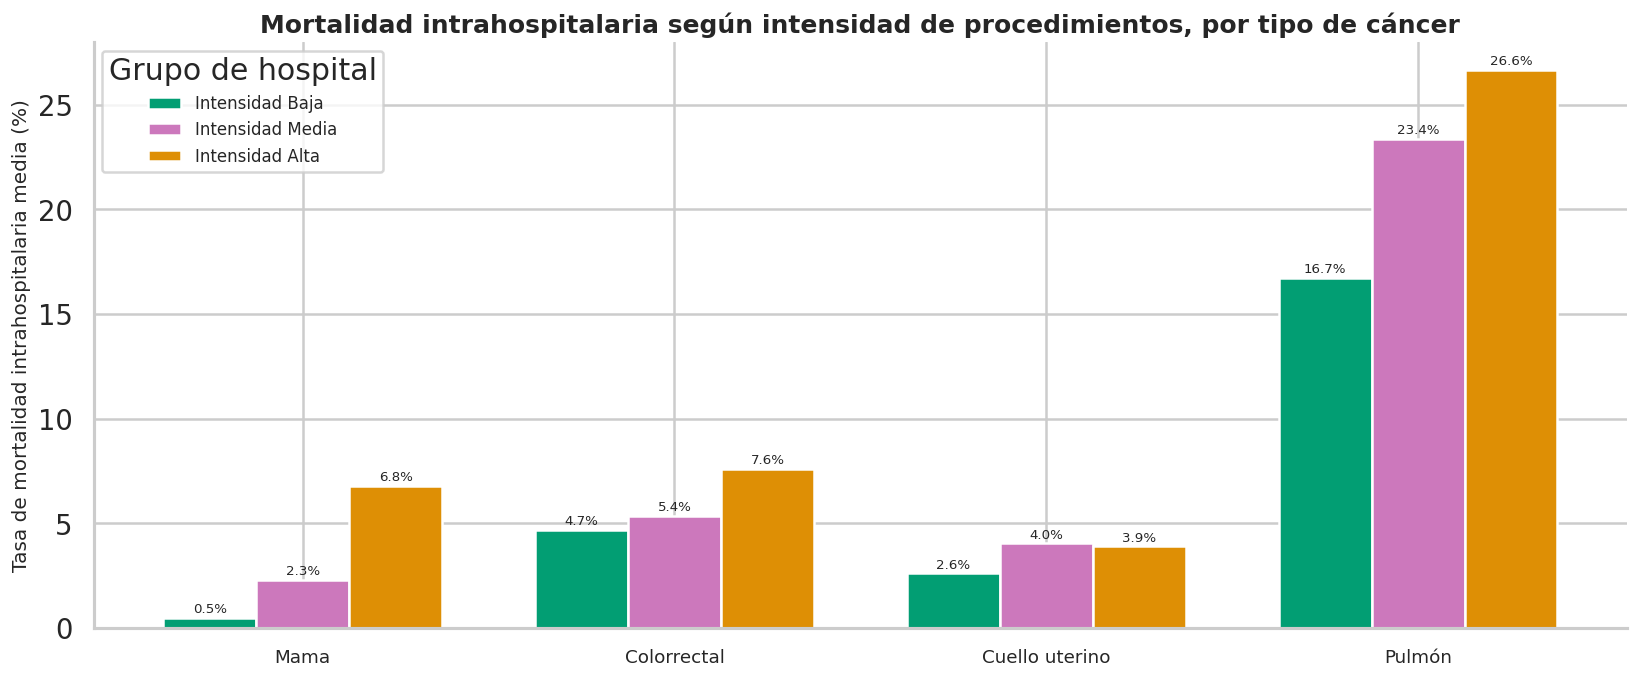


Tabla resumen: mortalidad media por tipo de cáncer e intensidad:


intensidad,Baja,Media,Alta
tipo_cancer,,,
Colorrectal,4.67,5.37,7.59
Cuello uterino,2.62,4.05,3.90
Mama,0.49,2.30,6.78
Pulmón,16.74,23.37,26.65


In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

mort_intensidad = (
    df_intensidad.groupby(["tipo_cancer", "intensidad"], observed=True)["mortalidad"]
    .mean()
    .reset_index()
)
mort_intensidad["mortalidad_pct"] = mort_intensidad["mortalidad"] * 100

x = np.arange(len(tipos))
width = 0.25
colores_int = {"Baja": COLORES[2], "Media": COLORES[4], "Alta": COLORES[1]}

for i, (nivel, color) in enumerate(colores_int.items()):
    vals = [
        mort_intensidad[
            (mort_intensidad["tipo_cancer"] == t) & (mort_intensidad["intensidad"].astype(str) == nivel)
        ]["mortalidad_pct"].values
        for t in tipos
    ]
    vals = [v[0] if len(v) > 0 else 0 for v in vals]
    bars = ax.bar(x + i * width, vals, width, label=f"Intensidad {nivel}", color=color, edgecolor="white")
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1, f"{val:.1f}%", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(tipos, fontsize=11)
ax.set_ylabel("Tasa de mortalidad intrahospitalaria media (%)")
ax.set_title(
    "Mortalidad intrahospitalaria según intensidad de procedimientos, por tipo de cáncer",
    fontweight="bold",
)
ax.legend(title="Grupo de hospital", fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

print("\nTabla resumen: mortalidad media por tipo de cáncer e intensidad:")
display(mort_intensidad.pivot(index="tipo_cancer", columns="intensidad", values="mortalidad_pct").round(2))

### C3. Días de estada por grupo de intensidad

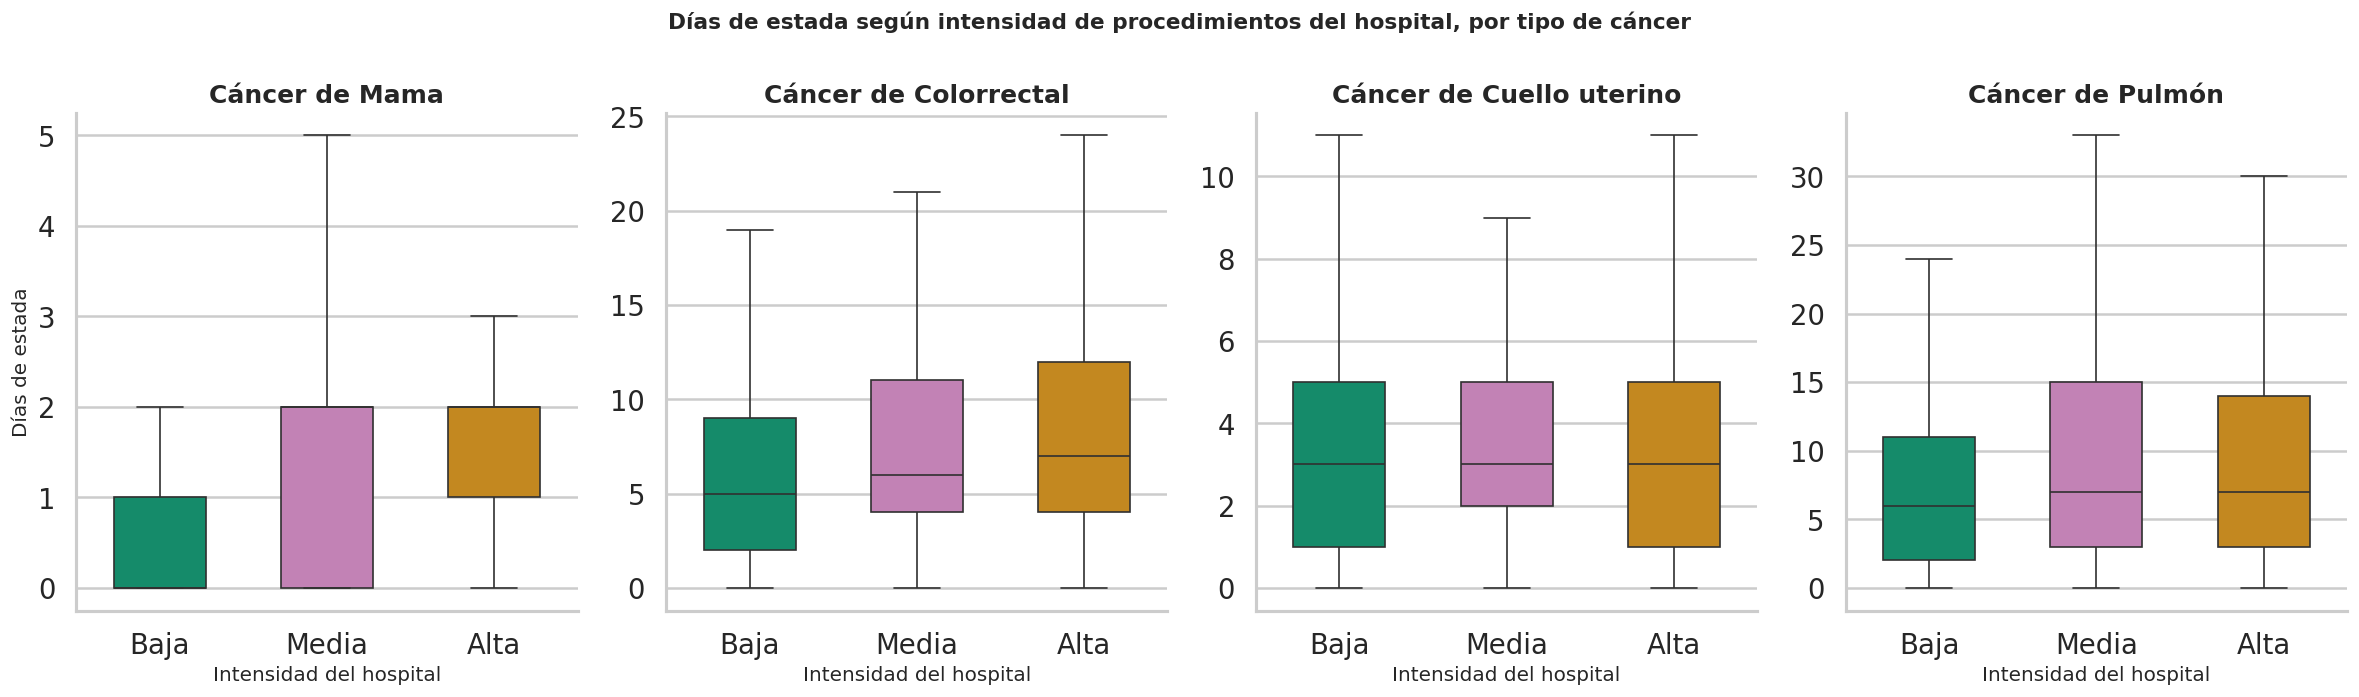

In [ ]:
# Asociamos el grupo de intensidad del hospital al dataframe de egresos
hosp_intensidad_map = df_intensidad.set_index(["tipo_cancer", "COD_HOSPITAL"])["intensidad"].to_dict()

df_onco["intensidad_hosp"] = [
    hosp_intensidad_map.get((tc, h), np.nan)
    for tc, h in zip(df_onco["tipo_cancer"], df_onco["COD_HOSPITAL"])
]

df_plot_int = df_onco[df_onco["intensidad_hosp"].notna()].copy()

fig, axes = plt.subplots(1, 4, figsize=(20, 6), sharey=False)
for ax, tipo in zip(axes, tipos):
    sub = df_plot_int[df_plot_int["tipo_cancer"] == tipo]
    sns.boxplot(
        data=sub,
        x="intensidad_hosp",
        y="dias_estada",
        order=["Baja", "Media", "Alta"],
        palette=[COLORES[2], COLORES[4], COLORES[1]],
        showfliers=False,
        ax=ax,
        width=0.55,
    )
    ax.set_title(f"Cáncer de {tipo}", fontweight="bold")
    ax.set_xlabel("Intensidad del hospital")
    ax.set_ylabel("Días de estada" if tipo == tipos[0] else "")

fig.suptitle(
    "Días de estada según intensidad de procedimientos del hospital, por tipo de cáncer",
    fontsize=13,
    fontweight="bold",
)
sns.despine()
plt.tight_layout()
plt.show()

### D1. Kruskal-Wallis: ¿varía el número de procedimientos entre hospitales?

In [ ]:
from scipy.stats import kruskal

alpha = 0.05
print("=" * 65)
print("KRUSKAL-WALLIS: Variabilidad de procedimientos entre hospitales")
print("=" * 65)
print(f"{'Tipo de cáncer':<20} {'H-stat':>10} {'p-value':>12} {'Resultado':>20}")
print("-" * 65)

for tipo in tipos:
    sub = df_onco[df_onco["tipo_cancer"] == tipo].copy()
    grupos = [
        g["n_procedimientos"].dropna().values
        for _, g in sub.groupby("COD_HOSPITAL")
        if g["n_procedimientos"].dropna().shape[0] >= 30
    ]
    if len(grupos) < 2:
        print(f"{tipo:<20} {'N/A':>10} {'N/A':>12} {'Insuficientes grupos':>20}")
        continue
    h, p = kruskal(*grupos)
    resultado = "Rechaza H0 (p<0.05)" if p < alpha else "No rechaza H0"
    print(f"{tipo:<20} {h:>10.2f} {p:>12.2e} {resultado:>20}")

print("\nInterpretación: si se rechaza H0, la distribución de procedimientos")
print("difiere significativamente entre hospitales para ese tipo de cáncer.")

KRUSKAL-WALLIS: Variabilidad de procedimientos entre hospitales
Tipo de cáncer           H-stat      p-value            Resultado
-----------------------------------------------------------------
Mama                   10524.65     0.00e+00  Rechaza H0 (p<0.05)
Colorrectal             2480.42     0.00e+00  Rechaza H0 (p<0.05)
Cuello uterino           947.53    4.14e-174  Rechaza H0 (p<0.05)
Pulmón                  1013.83    4.44e-183  Rechaza H0 (p<0.05)

Interpretación: si se rechaza H0, la distribución de procedimientos
difiere significativamente entre hospitales para ese tipo de cáncer.


### D2. Regresión logística: mortalidad ~ procedimientos + severidad + hospital

In [ ]:
import statsmodels.formula.api as smf

print("=" * 65)
print("REGRESIÓN LOGÍSTICA: muerte_intra ~ procedimientos + severidad + edad")
print("=" * 65)

for tipo in tipos:
    sub = df_onco[
        (df_onco["tipo_cancer"] == tipo)
        & df_onco[["muerte_intra", "n_procedimientos", "severidad", "edad"]].notna().all(axis=1)
    ].copy()

    if len(sub) < 100:
        print(f"\n{tipo}: muestra insuficiente ({len(sub)} registros).")
        continue

    min_hosp = sub.groupby("COD_HOSPITAL").size()
    hosps_validos = min_hosp[min_hosp >= 30].index
    sub = sub[sub["COD_HOSPITAL"].isin(hosps_validos)].copy()
    sub["COD_HOSPITAL"] = sub["COD_HOSPITAL"].astype(str)

    try:
        formula = "muerte_intra ~ n_procedimientos + severidad + edad + C(COD_HOSPITAL)"
        modelo = smf.logit(formula, data=sub).fit(disp=False, maxiter=200)

        coef_tabla = modelo.summary2().tables[1]
        vars_interes = ["n_procedimientos", "severidad", "edad"]
        print(f"\n{'─'*65}")
        print(f"Cáncer de {tipo}  (n = {len(sub):,}, hospitales = {sub['COD_HOSPITAL'].nunique()})")
        print(f"{'─'*65}")
        display(
            coef_tabla.loc[
                coef_tabla.index.isin(vars_interes),
                ["Coef.", "Std.Err.", "z", "P>|z|", "[0.025", "0.975]"],
            ].round(4)
        )
        print(f"  AIC: {modelo.aic:.1f}  |  Pseudo-R²: {modelo.prsquared:.4f}")

        or_proc = np.exp(modelo.params["n_procedimientos"])
        ic_low = np.exp(modelo.conf_int().loc["n_procedimientos", 0])
        ic_high = np.exp(modelo.conf_int().loc["n_procedimientos", 1])
        print(f"  OR n_procedimientos: {or_proc:.3f}  IC95%: [{ic_low:.3f}, {ic_high:.3f}]")

    except Exception as e:
        print(f"  Error en {tipo}: {e}")

REGRESIÓN LOGÍSTICA: muerte_intra ~ procedimientos + severidad + edad


/home/sebacc/Documents/UDD/Análisis de Datos e Inferencia Estadística/Proyecto_Hospitalización/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



─────────────────────────────────────────────────────────────────
Cáncer de Mama  (n = 30,912, hospitales = 44)
─────────────────────────────────────────────────────────────────


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
n_procedimientos,-0.0517,0.2010,-0.2572,0.7970,-0.4456,0.3422
severidad,3.1169,0.1308,23.8380,0.0000,2.8606,3.3731
edad,-0.0086,0.0049,-1.7467,0.0807,-0.0182,0.0010


  AIC: 1736.0  |  Pseudo-R²: 0.4666
  OR n_procedimientos: 0.950  IC95%: [0.640, 1.408]


...

/home/sebacc/Documents/UDD/Análisis de Datos e Inferencia Estadística/Proyecto_Hospitalización/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
n_procedimientos,-0.4022,0.2361,-1.7031,0.0886,-0.8650,0.0607
severidad,2.1550,0.1431,15.0643,0.0000,1.8746,2.4353
edad,0.0248,0.0054,4.5853,0.0000,0.0142,0.0355


  AIC: 1205.8  |  Pseudo-R²: 0.3169
  OR n_procedimientos: 0.669  IC95%: [0.421, 1.063]

─────────────────────────────────────────────────────────────────
Cáncer de Pulmón  (n = 7,445, hospitales = 46)
─────────────────────────────────────────────────────────────────


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
n_procedimientos,-0.1285,0.1145,-1.1225,0.2616,-0.3530,0.0959
severidad,1.6009,0.0666,24.0473,0.0000,1.4705,1.7314
edad,0.0060,0.0030,1.9951,0.0460,0.0001,0.0119


  AIC: 5838.1  |  Pseudo-R²: 0.1843
  OR n_procedimientos: 0.879  IC95%: [0.703, 1.101]


### D3. Regresión OLS: días de estada ~ procedimientos + severidad + hospital

In [ ]:
print("=" * 65)
print("REGRESIÓN OLS: dias_estada ~ procedimientos + severidad + edad")
print("=" * 65)

ols_results = {}
for tipo in tipos:
    sub = df_onco[
        (df_onco["tipo_cancer"] == tipo)
        & df_onco[["dias_estada", "n_procedimientos", "severidad", "edad"]].notna().all(axis=1)
    ].copy()

    if len(sub) < 100:
        print(f"\n{tipo}: muestra insuficiente.")
        continue

    min_hosp = sub.groupby("COD_HOSPITAL").size()
    hosps_validos = min_hosp[min_hosp >= 30].index
    sub = sub[sub["COD_HOSPITAL"].isin(hosps_validos)].copy()
    sub["COD_HOSPITAL"] = sub["COD_HOSPITAL"].astype(str)

    try:
        formula = "dias_estada ~ n_procedimientos + severidad + edad + C(COD_HOSPITAL)"
        modelo = smf.ols(formula, data=sub).fit()
        ols_results[tipo] = modelo

        coef_tabla = modelo.summary2().tables[1]
        vars_interes = ["n_procedimientos", "severidad", "edad"]
        print(f"\n{'─'*65}")
        print(f"Cáncer de {tipo}  (n = {len(sub):,}, hospitales = {sub['COD_HOSPITAL'].nunique()})")
        print(f"{'─'*65}")
        display(
            coef_tabla.loc[
                coef_tabla.index.isin(vars_interes),
                ["Coef.", "Std.Err.", "t", "P>|t|", "[0.025", "0.975]"],
            ].round(4)
        )
        print(f"  R² ajustado: {modelo.rsquared_adj:.4f}  |  AIC: {modelo.aic:.1f}")

    except Exception as e:
        print(f"  Error en {tipo}: {e}")

REGRESIÓN OLS: dias_estada ~ procedimientos + severidad + edad

─────────────────────────────────────────────────────────────────
Cáncer de Mama  (n = 30,912, hospitales = 44)
─────────────────────────────────────────────────────────────────


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
n_procedimientos,0.2999,0.0244,12.2682,0.0000,0.2520,0.3479
severidad,1.7084,0.0215,79.5218,0.0000,1.6663,1.7505
edad,0.0024,0.0011,2.2275,0.0259,0.0003,0.0046


  R² ajustado: 0.2919  |  AIC: 145462.2

─────────────────────────────────────────────────────────────────
Cáncer de Colorrectal  (n = 25,404, hospitales = 56)
─────────────────────────────────────────────────────────────────


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
n_procedimientos,1.6716,0.0999,16.7410,0.0,1.4759,1.8673
severidad,4.1007,0.0610,67.2317,0.0,3.9812,4.2203
edad,0.0191,0.0037,5.2109,0.0,0.0119,0.0263


  R² ajustado: 0.2608  |  AIC: 175069.2

─────────────────────────────────────────────────────────────────
Cáncer de Cuello uterino  (n = 6,557, hospitales = 39)
─────────────────────────────────────────────────────────────────


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
n_procedimientos,1.2089,0.1402,8.6223,0.0000,0.9341,1.4838
severidad,3.1265,0.0930,33.6110,0.0000,2.9442,3.3089
edad,0.0108,0.0050,2.1396,0.0324,0.0009,0.0206


  R² ajustado: 0.2287  |  AIC: 41163.8

─────────────────────────────────────────────────────────────────
Cáncer de Pulmón  (n = 7,445, hospitales = 46)
─────────────────────────────────────────────────────────────────


,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
n_procedimientos,2.2639,0.2730,8.2939,0.0000,1.7288,2.7990
severidad,3.5918,0.1325,27.0996,0.0000,3.3320,3.8517
edad,-0.0322,0.0093,-3.4810,0.0005,-0.0504,-0.0141


  R² ajustado: 0.1519  |  AIC: 53591.2


### D4. Visualización de efectos fijos por hospital (OLS)

In [ ]:
# Para un tipo de cáncer a la vez, graficamos los coeficientes de hospital
tipo_grafico = "Colorrectal"  # Cambiar al tipo que más interese

if tipo_grafico in ols_results:
    modelo = ols_results[tipo_grafico]
    params = modelo.params
    conf = modelo.conf_int()

    hosp_params = params[params.index.str.startswith("C(COD_HOSPITAL)")].copy()
    hosp_conf = conf[conf.index.str.startswith("C(COD_HOSPITAL)")].copy()

    hosp_labels = hosp_params.index.to_series().str.extract(r"C\(COD_HOSPITAL\)\[T\.(.*)\]", expand=False)
    hosp_params.index = hosp_labels.fillna(hosp_params.index)
    hosp_conf.index = hosp_params.index

    orden = hosp_params.sort_values().index
    vals = hosp_params[orden]
    low = hosp_conf.loc[orden, 0]
    high = hosp_conf.loc[orden, 1]

    n_mostrar = min(20, len(orden))
    idx = list(orden[: n_mostrar // 2]) + list(orden[-n_mostrar // 2 :])
    vals_plot = vals[idx]
    low_plot = low[idx]
    high_plot = high[idx]

    fig, ax = plt.subplots(figsize=(10, max(6, len(idx) * 0.4)))
    y_pos = range(len(idx))
    ax.barh(
        list(y_pos),
        vals_plot.values,
        xerr=[vals_plot.values - low_plot.values, high_plot.values - vals_plot.values],
        color=[COLORES[1] if v > 0 else COLORES[2] for v in vals_plot.values],
        edgecolor="white",
        capsize=4,
        alpha=0.85,
    )
    ax.axvline(0, color="black", linewidth=1.2, linestyle="--")
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(idx, fontsize=8)
    ax.set_xlabel("Días de estada adicionales respecto al hospital de referencia")
    ax.set_title(
        f"Efectos fijos por hospital — Cáncer de {tipo_grafico}\n"
        f"(Top/Bottom {n_mostrar // 2} hospitales, controlando por severidad y procedimientos)",
        fontweight="bold",
    )
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print(f"Modelo OLS no disponible para {tipo_grafico}.")

TypeError: "value" parameter must be a scalar, dict or Series, but you passed a "Index"

### D5. Evolución temporal de mortalidad por tipo de cáncer (pacientes únicos)

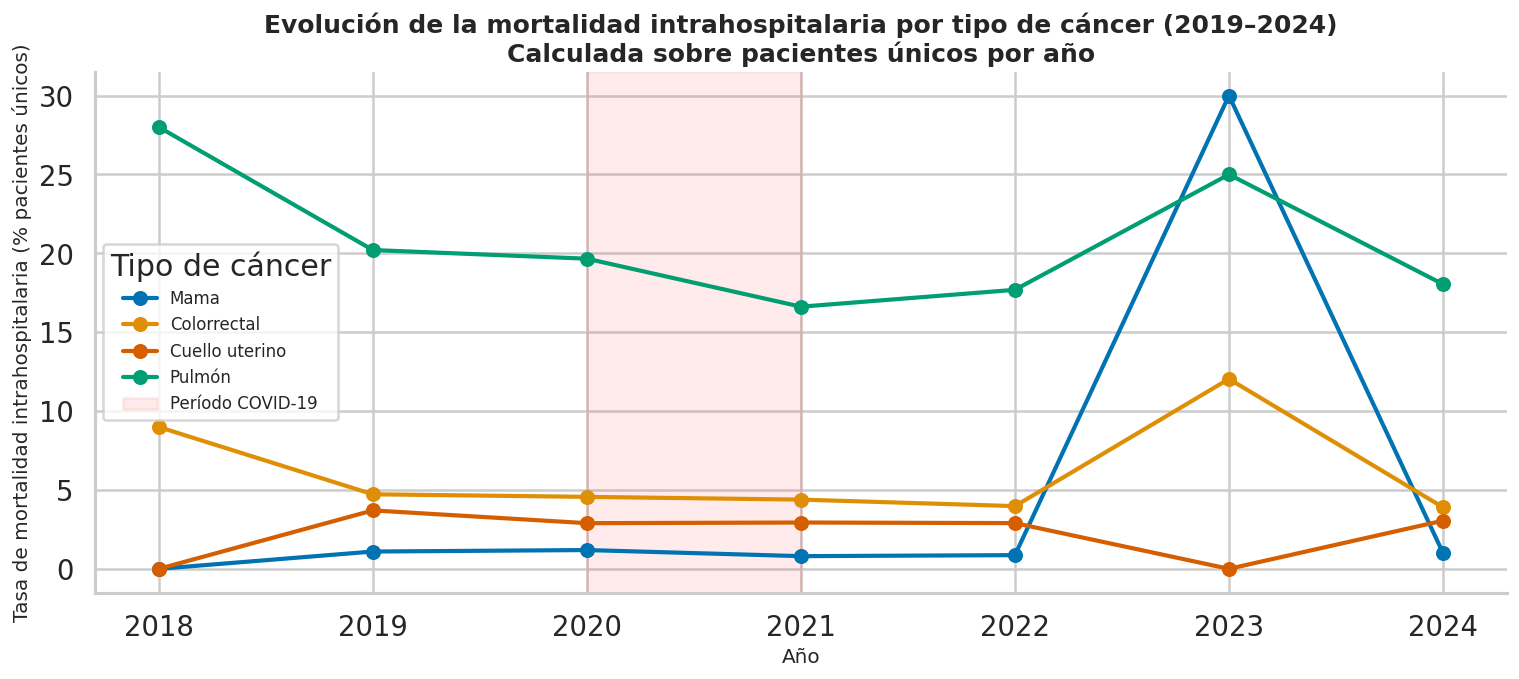

In [ ]:
# Tasa de mortalidad anual por tipo de cáncer, calculada sobre pacientes únicos.
# Se cuenta un paciente como fallecido si tuvo al menos un egreso con TIPOALTA=FALLECIDO.

mort_anual_frames = []
for tipo in tipos:
    sub = df_onco[df_onco["tipo_cancer"] == tipo].copy()
    por_paciente_anio = (
        sub.groupby([id_col, "anio"])
        .agg(fallecio=("muerte_intra", "max"))
        .reset_index()
    )
    tasa = (
        por_paciente_anio.groupby("anio")
        .agg(n_pacientes=(id_col, "count"), n_fallecidos=("fallecio", "sum"))
        .assign(tasa_mort=lambda d: d["n_fallecidos"] / d["n_pacientes"] * 100)
        .reset_index()
    )
    tasa["tipo_cancer"] = tipo
    mort_anual_frames.append(tasa)

df_mort_anual = pd.concat(mort_anual_frames, ignore_index=True)

fig, ax = plt.subplots(figsize=(13, 6))
for tipo, color in zip(tipos, [COLORES[0], COLORES[1], COLORES[3], COLORES[2]]):
    data = df_mort_anual[df_mort_anual["tipo_cancer"] == tipo]
    ax.plot(data["anio"], data["tasa_mort"], "o-", color=color, linewidth=2.5, markersize=8, label=tipo)

ax.axvspan(2020, 2021, alpha=0.08, color="red", label="Período COVID-19")
ax.set_xlabel("Año")
ax.set_ylabel("Tasa de mortalidad intrahospitalaria (% pacientes únicos)")
ax.set_title(
    "Evolución de la mortalidad intrahospitalaria por tipo de cáncer (2019–2024)\n"
    "Calculada sobre pacientes únicos por año",
    fontweight="bold",
)
ax.legend(title="Tipo de cáncer", fontsize=10)
ax.set_xticks(sorted(df_mort_anual["anio"].unique()))
sns.despine()
plt.tight_layout()
plt.show()